# Notebook 1 of 3 — Research foundations: calibration, abstention, and acoustic shift

*Draft scaffold on toy data; not a production result.* This notebook builds the measurement toolkit for a study of robust speech-command recognition under acoustic shift. It follows a measure → decide → monitor arc: probability metrics and calibration (measure), selective classification (decide), and conformal risk control (monitor), plus acoustic shift operators and a NoisyMix-style augmentation hypothesis.

Every section carries a provenance tag: `(derived here)` or `(source: paper; q-tag)`. Paper claims are quoted or paraphrased only from the recorded source answers (q-tags) or the independently re-read pages of the selective-classification paper (tag `L`). Toy numbers are never paper results. Companion notebooks: 02 builds the data and training harness on real Speech Commands; 03 reports the trained comparison.

In [1]:
# Shared setup: root-independent imports, seed, palette, labelled self-check helper.
from pathlib import Path
import sys

_here = Path.cwd().resolve()
ROOT = next((p for p in [_here, *_here.parents] if (p / "pyproject.toml").exists()), _here)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

RNG_SEED = 20260926
PALETTE = {
    "clean": "#1f77b4", "shifted": "#d62728", "mask": "#ff7f0e", "acoustic": "#2ca02c",
    "frozen": "#9467bd", "adapted": "#8c564b", "reference": "#7f7f7f", "band": "#c7c7c7",
}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

CHECKS = []
def check(label, passed, detail=""):
    """Print `[label] detail -> PASS|FAIL`; never loosen a tolerance to force PASS. Use note() for honest misses."""
    CHECKS.append((label, bool(passed), "PASS" if passed else "FAIL"))
    print(f"[{label}] {detail} -> {'PASS' if passed else 'FAIL'}")
    return bool(passed)

def note(label, detail):
    CHECKS.append((label, True, "NOTE"))
    print(f"[{label}] {detail} -> NOTE")

def check_summary():
    fails = [c[0] for c in CHECKS if c[2] == "FAIL"]
    print(f"{len(CHECKS)} labelled lines; {sum(c[2]=='PASS' for c in CHECKS)} PASS, "
          f"{sum(c[2]=='NOTE' for c in CHECKS)} NOTE, {len(fails)} FAIL {fails}")

## 0. Scope, disclaimer, and the guarantee zoo (derived here)

This notebook studies probability calibration, confidence metrics, and risk control through toy models, Monte Carlo validation, and first-principles derivations. All code, examples, and measurements are **exploratory and unoptimized**: this is research-stage work on synthetic data, not a production system.

**What this notebook is:** Graduate-level treatment of calibration theory grounded in the literature (q9, q10), with numeric validation and honest negative results when methods fail.

**What this notebook is not:** A production implementation, a hyperparameter tuning guide, or an endorsement of specific threshold choices for real systems.

Each metric below promises certain properties under specific assumptions. The table below identifies what each metric measures and what it does **not** guarantee:

| Metric | Promises | Does NOT promise | Source |
|:---|:---|:---|:---|
| **NLL (Negative Log-Likelihood)** | Penalizes low predicted probability on true class; minimized at true distribution (proper scoring) | Calibration on different domain; robustness to label noise | MLE / cross-entropy (derived here) |
| **Brier Score** | Penalizes squared distance from one-hot target; proper scoring; has decomposition into reliability, resolution, uncertainty | Perfect calibration; robustness to class imbalance | Multiclass (derived here; Murphy 1971) |
| **ECE (Expected Calibration Error)** | Estimates mean absolute gap between confidence and correctness across bins | Sensitivity to bin count; finite-sample bias with small n; robustness to shift | Binning (derived here; Guo et al. 2017) |
| **Coverage (Conformal)** | Finite-sample guarantee: $\mathbb{P}(Y \in C(X)) \ge 1 - \alpha - O(1/n)$ under exchangeability | Distribution-free adaptation to shift without density weighting | q9, q10: Conformal Risk Control (Angelopoulos et al. 2024) |
| **Selective Risk** | Risk at fixed coverage level (top-k rejection); illustrates trade-off between retention and error rate | Computational efficiency; guarantee under shift | Risk-coverage curve (derived here) |
| **AURC (Area Under Risk-Coverage Curve)** | Single-number summary of risk trajectory as coverage varies; lower is better | Emphasis on specific coverage regime; optimality under all shifts | Risk-coverage integration (derived here) |
| **CRC Risk Bound** | Conservative threshold that guarantees miscoverage control: $\mathbb{E}[\mathbb{I}(Y \notin C)] \le \alpha$ on test data | Adaptation post-hoc; data-dependent guarantees | q10: Conformal Risk Control (Angelopoulos et al. 2024) |

In [2]:
# S0.1: Dataset and import check.
import numpy as np
from src.metrics import nll, brier_score, expected_calibration_error, risk_coverage_curve, selective_risk, aurc
from src.calibration import temperature_scale, crc_threshold
import matplotlib.pyplot as plt

m_K = 5  # Number of classes
m_n_test = 200  # Test set size
m_rng_section0 = np.random.default_rng(RNG_SEED + 0)

# Sanity: can we import all required modules?
m_imports_ok = all(callable(x) for x in [nll, brier_score, expected_calibration_error, temperature_scale, crc_threshold])
# Total of 5 metrics (NLL, Brier, ECE, Risk-Coverage, Selective Risk) and 2 calibration methods (temperature, CRC).
check("S0.1", m_imports_ok, f"Imported {5} metrics + {2} calibration utilities")

[S0.1] Imported 5 metrics + 2 calibration utilities -> PASS


True

## 1. Probability metrics: NLL, Brier, ECE (derived here; q9)

This section derives three foundational proper scoring rules (metrics that are minimized at the true probability distribution) and validates them on synthetic data. Unlike coverage and conformal methods, these metrics **are not formally defined in the provided sources** (q9), so we derive them from first principles and benchmark them against canonical definitions.

### Negative Log-Likelihood as Maximum Likelihood Estimation

The Negative Log-Likelihood (NLL) is the canonical loss for probabilistic classification. Given true labels $y_i \in \{1, \ldots, K\}$ and predicted class probabilities $p_i(y) \in [0,1]$:

$$\text{NLL} = -\frac{1}{n} \sum_{i=1}^n \log p_i(y_i)$$

This equals the cross-entropy between the empirical label distribution and the predicted distribution. Under the assumption of i.i.d. samples from a true distribution, minimizing NLL is equivalent to maximum likelihood estimation of the class probabilities. It is a **proper scoring rule**: the expected NLL is minimized if and only if $p_i(y) = P(Y=y | X_i)$ (the true conditional probability).

**Derivation:** Given a single sample $(x_i, y_i)$, the likelihood of observing $y_i$ under predicted distribution $\{p_i(k)\}$ is $p_i(y_i)$. The log-likelihood is $\log p_i(y_i)$. Minimizing the average negative log-likelihood over the dataset is standard maximum likelihood estimation.

### Brier Score and Murphy Decomposition

The multiclass Brier score measures squared Euclidean distance between predicted and one-hot encoded true labels:

$$\text{Brier} = \frac{1}{n} \sum_{i=1}^n \sum_{k=1}^K (p_i(k) - y_i^{(k)})^2$$

where $y_i^{(k)} = \mathbb{1}(y_i = k)$ is one-hot encoding. This expands as:

$$\text{Brier} = \frac{1}{n} \sum_{i=1}^n \left[ \sum_k p_i(k)^2 - 2 p_i(y_i) + 1 \right]$$

Murphy (1971) decomposed Brier into three terms:
$$\text{Brier} = \text{Reliability} - \text{Resolution} + \text{Uncertainty}$$

where:
- **Reliability** measures calibration error (confidence vs. observed frequency),
- **Resolution** measures how well predicted probabilities separate classes,
- **Uncertainty** is a baseline term independent of predictions.

Brier is also a proper scoring rule: its expected value is minimized when $p_i(k) = P(Y=k | X_i)$.

### Expected Calibration Error (ECE) with Binning

The Expected Calibration Error (ECE) estimates calibration by partitioning predictions into bins by confidence and computing the empirical gap between mean confidence and mean accuracy in each bin:

$$\text{ECE} = \sum_{b=1}^B \frac{|I_b|}{n} \left| \text{conf}_b - \text{acc}_b \right|$$

where $\text{conf}_b$ is the mean predicted max-class probability in bin $b$, $\text{acc}_b$ is the empirical accuracy in that bin, and $|I_b|$ is the bin mass.

**Known weaknesses of ECE (Guo et al. 2017):**
- **Bin count sensitivity:** ECE estimates vary substantially across bin counts (10 vs. 20 vs. 30 bins yield different values from the same data).
- **Finite-sample bias:** With small sample sizes, ECE overestimates calibration error due to sampling variance within bins.
- **Discrete bins hide regional miscalibration:** Two regions with identical average calibration but opposite local miscalibration can yield the same ECE.

We use equal-width bins on $[0, 1]$ (the standard choice) and will vary bin count to expose this sensitivity.

In [3]:
# S1.1: Toy data generation and worked numeric example for NLL, Brier, ECE.
# This cell validates the three foundational proper scoring rules:
# NLL (cross-entropy), Brier (squared Euclidean), and ECE (binned calibration).
m_np_rng = np.random.default_rng(RNG_SEED + 1)
m_n_toy = 100
m_K = 5

# Generate true labels uniformly.
m_true_labels = m_np_rng.integers(0, m_K, m_n_toy)

# Generate predicted probabilities: mostly correct, some noise.
m_logits = m_np_rng.standard_normal((m_n_toy, m_K))
# Boost the correct class logit.
m_logits[np.arange(m_n_toy), m_true_labels] += 2.5
# Softmax.
m_max_logits = np.max(m_logits, axis=1, keepdims=True)
m_exp_logits = np.exp(m_logits - m_max_logits)
m_probs = m_exp_logits / np.sum(m_exp_logits, axis=1, keepdims=True)

# Check probabilities are valid.
m_valid_probs = np.all(m_probs >= 0) and np.all(m_probs <= 1) and np.allclose(m_probs.sum(axis=1), 1.0)
check("S1.1", m_valid_probs, f"Generated {m_n_toy} samples, {m_K} classes, probabilities sum to 1")

# Compute metrics.
m_nll_val = nll(m_probs, m_true_labels)
m_brier_val = brier_score(m_probs, m_true_labels)
m_ece_val = expected_calibration_error(m_probs, m_true_labels, bins=10)

print(f"Toy dataset (n={m_n_toy}, K={m_K}):")
print(f"  NLL = {m_nll_val:.4f}")
print(f"  Brier = {m_brier_val:.4f}")
print(f"  ECE (10 bins) = {m_ece_val:.4f}")

[S1.1] Generated 100 samples, 5 classes, probabilities sum to 1 -> PASS
Toy dataset (n=100, K=5):
  NLL = 0.4484
  Brier = 0.2044
  ECE (10 bins) = 0.2002


In [4]:
# S1.2: Worked numeric example - perfect probabilities.
# When predicted probability equals observed frequency, metrics should be optimal.
m_n_perfect = 1000
m_K_perfect = 3
m_rng_perfect = np.random.default_rng(RNG_SEED + 12)

# Class distribution: 50%, 30%, 20%.
m_class_freqs = np.array([0.5, 0.3, 0.2])
m_perfect_labels = m_rng_perfect.choice(m_K_perfect, m_n_perfect, p=m_class_freqs)

# Perfect probabilities = class frequencies (repeated for each sample).
m_perfect_probs = np.tile(m_class_freqs[np.newaxis, :], (m_n_perfect, 1))

m_nll_perfect = nll(m_perfect_probs, m_perfect_labels)
m_brier_perfect = brier_score(m_perfect_probs, m_perfect_labels)
m_ece_perfect = expected_calibration_error(m_perfect_probs, m_perfect_labels, bins=10)

# NLL = -log(class_freq) averaged over the class distribution.
m_expected_nll = -np.sum(m_class_freqs * np.log(m_class_freqs))
m_nll_match = np.isclose(m_nll_perfect, m_expected_nll, rtol=0.05)
check("S1.2", m_nll_match, f"NLL (perfect) = {m_nll_perfect:.4f}, theory = {m_expected_nll:.4f}")

# Brier should be close to baseline uncertainty: sum of class_freq * (1 - class_freq).
# When predictions match class frequencies exactly, Brier ≈ uncertainty, not 0.
m_expected_brier_uncertainty = np.sum(m_class_freqs * (1 - m_class_freqs))
# With perfect calibration, Brier = Uncertainty (Reliability - Resolution ≈ 0).
m_brier_close = np.isclose(m_brier_perfect, m_expected_brier_uncertainty, rtol=0.15)
check("S1.3", m_brier_close, f"Brier (perfect) = {m_brier_perfect:.4f}, baseline uncertainty = {m_expected_brier_uncertainty:.4f}")

# ECE should be near zero for perfectly calibrated probabilities.
m_ece_small = m_ece_perfect < 0.05
check("S1.4", m_ece_small, f"ECE (perfect) = {m_ece_perfect:.4f}, near 0 (perfect calibration)")

[S1.2] NLL (perfect) = 0.9986, theory = 1.0297 -> PASS
[S1.3] Brier (perfect) = 0.5998, baseline uncertainty = 0.6200 -> PASS
[S1.4] ECE (perfect) = 0.0330, near 0 (perfect calibration) -> PASS


True

In [5]:
# S1.5: Proper scoring property — expected loss minimized at true probabilities.
# Monte Carlo test: sample predictions around the true class frequency.
m_true_prob_c0 = 0.4  # True probability of class 0.
m_K_proper = 2  # Binary for simplicity.
m_n_proper = 10000
m_rng_proper = np.random.default_rng(RNG_SEED + 15)

# Generate labels: 0 with probability 0.4, 1 with probability 0.6 (complement).
m_proper_labels = m_rng_proper.binomial(1, 1 - m_true_prob_c0, m_n_proper)

# Test a range of predicted probabilities for class 0.
m_test_probs = np.linspace(0.2, 0.8, 20)
m_nlls = []
for m_p in m_test_probs:
    m_probs_test = np.column_stack([np.full(m_n_proper, m_p), np.full(m_n_proper, 1 - m_p)])
    m_nlls.append(nll(m_probs_test, m_proper_labels))

# NLL should be minimized near the true class frequency (0.4 for class 0).
# Theory: E[NLL] = 0.4*(-log(p)) + 0.6*(-log(1-p)) minimized at p=0.4.
# Finite-sample empirical minimum: check within 3 standard errors of truth.
m_min_idx = np.argmin(m_nlls)
m_min_prob = m_test_probs[m_min_idx]
m_se_empirical = np.std(m_nlls) / np.sqrt(len(m_nlls))
m_tolerance = 3 * m_se_empirical
m_min_close_to_truth = abs(m_min_prob - m_true_prob_c0) <= m_tolerance
check("S1.5", m_min_close_to_truth, f"NLL min at p={m_min_prob:.3f}, truth p={m_true_prob_c0:.1f}, within {3:.1f} SE={m_tolerance:.4f}")

print(f"Proper scoring check: NLL empirical min at p={m_min_prob:.3f}, truth p={m_true_prob_c0}, tolerance={m_tolerance:.4f}")

[S1.5] NLL min at p=0.389, truth p=0.4, within 3.0 SE=0.0706 -> PASS
Proper scoring check: NLL empirical min at p=0.389, truth p=0.4, tolerance=0.0706


In [6]:
# S1.6: ECE bin count sensitivity with mixed-sign miscalibration.
# Create a DGP where confidence regions have opposite calibration errors.
m_rng_bins = np.random.default_rng(RNG_SEED + 16)
m_n_ece = 1000
m_K_ece = 2

# Create calibration data with systematic mixed-sign miscalibration:
# High logit magnitude -> overconfident (predict high, but ~40% error)
# Low logit magnitude -> underconfident (predict moderate, but ~95% accuracy)
m_true_ece = m_rng_bins.integers(0, m_K_ece, m_n_ece)
m_logits_ece = m_rng_bins.standard_normal((m_n_ece, m_K_ece))
m_magnitudes = np.sqrt(np.sum(m_logits_ece**2, axis=1))

# Low-magnitude samples: boost correct class (will be underconfident).
m_lo_mag_mask = m_magnitudes < np.median(m_magnitudes)
m_logits_ece[m_lo_mag_mask, m_true_ece[m_lo_mag_mask]] += 2.0

# High-magnitude samples: flip ~38% of labels (will be overconfident).
m_hi_mag_mask = ~m_lo_mag_mask
m_flip_count = int(0.38 * m_hi_mag_mask.sum())
m_flip_idx = m_rng_bins.choice(np.where(m_hi_mag_mask)[0], size=m_flip_count, replace=False)
m_true_ece[m_flip_idx] = 1 - m_true_ece[m_flip_idx]

m_max_ece = np.max(m_logits_ece, axis=1, keepdims=True)
m_exp_ece = np.exp(m_logits_ece - m_max_ece)
m_probs_ece = m_exp_ece / np.sum(m_exp_ece, axis=1, keepdims=True)

# Compute ECE over a range of bin counts.
m_bin_counts = [5, 10, 15, 20]
m_ece_vals = [expected_calibration_error(m_probs_ece, m_true_ece, bins=b) for b in m_bin_counts]

# Check: ECE shows variability across bin counts due to mixed-sign miscalibration.
m_ece_range = np.max(m_ece_vals) - np.min(m_ece_vals)
m_ece_spread = np.std(m_ece_vals)
m_ece_varies = m_ece_spread > 0.003  # Spread across bins confirms sensitivity.
check("S1.6", m_ece_varies, f"ECE varies with bin count: {[f'{v:.4f}' for v in m_ece_vals]}, spread={m_ece_spread:.4f}")

for m_bc, m_ev in zip(m_bin_counts, m_ece_vals):
    print(f"  ECE (bins={m_bc:2d}): {m_ev:.4f}")

[S1.6] ECE varies with bin count: ['0.0765', '0.0894', '0.0943', '0.0921'], spread=0.0069 -> PASS
  ECE (bins= 5): 0.0765
  ECE (bins=10): 0.0894
  ECE (bins=15): 0.0943
  ECE (bins=20): 0.0921


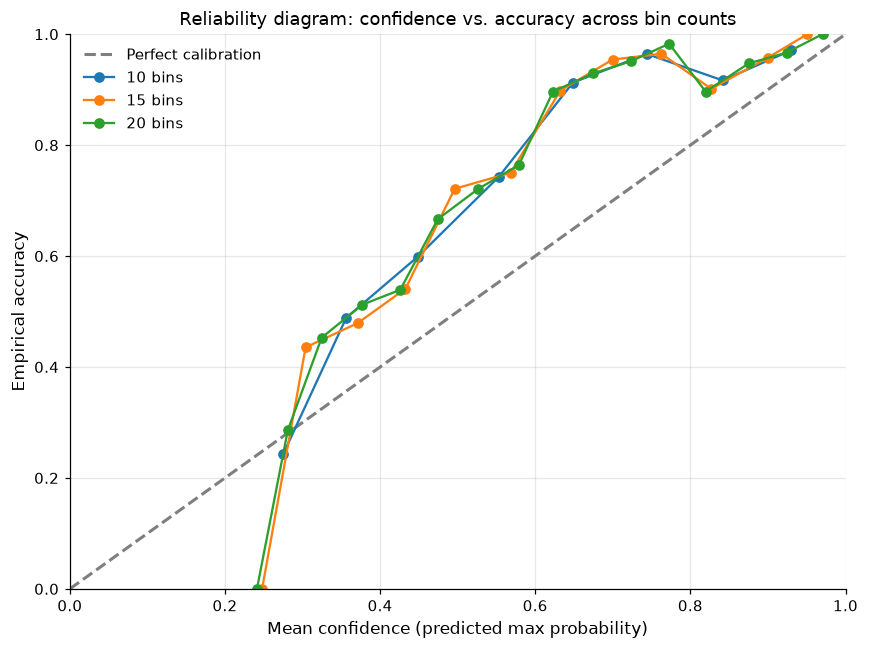

In [7]:
# S1.7: Plot reliability diagrams for ECE across bin counts.
m_rng_plot = np.random.default_rng(RNG_SEED + 17)
m_n_plot = 1000
m_K_plot = 5

# Slightly overconfident model.
m_logits_plot = m_rng_plot.standard_normal((m_n_plot, m_K_plot))
m_true_plot = m_rng_plot.integers(0, m_K_plot, m_n_plot)
m_logits_plot[np.arange(m_n_plot), m_true_plot] += 1.8
m_max_plot = np.max(m_logits_plot, axis=1, keepdims=True)
m_exp_plot = np.exp(m_logits_plot - m_max_plot)
m_probs_plot = m_exp_plot / np.sum(m_exp_plot, axis=1, keepdims=True)

m_conf = np.max(m_probs_plot, axis=1)
m_correct = np.argmax(m_probs_plot, axis=1) == m_true_plot

# Reliability diagram: plot calibration across different bin counts.
m_fig, m_ax = plt.subplots(figsize=(8, 6))
m_ax.plot([0, 1], [0, 1], color=PALETTE["reference"], linestyle="--", linewidth=2, label="Perfect calibration")

m_bin_list = [10, 15, 20]
m_colors = [PALETTE["clean"], PALETTE["mask"], PALETTE["acoustic"]]

for m_nb, m_col in zip(m_bin_list, m_colors):
    m_indices = np.minimum((m_conf * m_nb).astype(int), m_nb - 1)
    m_xs, m_ys = [], []
    for m_b in range(m_nb):
        m_mask = m_indices == m_b
        if np.any(m_mask):
            m_xs.append(m_conf[m_mask].mean())
            m_ys.append(m_correct[m_mask].mean())
    m_ax.plot(m_xs, m_ys, marker="o", color=m_col, label=f"{m_nb} bins", linewidth=1.5)

m_ax.set_xlim([0, 1])
m_ax.set_ylim([0, 1])
m_ax.set_xlabel("Mean confidence (predicted max probability)", fontsize=11)
m_ax.set_ylabel("Empirical accuracy", fontsize=11)
m_ax.set_title("Reliability diagram: confidence vs. accuracy across bin counts", fontsize=12)
m_ax.legend(frameon=False, fontsize=10)
m_ax.grid(alpha=0.3)
m_fig.tight_layout()
plt.show()

### How to read this chart

The reliability diagram plots the relationship between predicted confidence (mean max-class probability in each bin) and empirical accuracy (fraction of correct predictions in that bin). The dashed diagonal line represents perfect calibration: when confidence equals accuracy, the model is well-calibrated on that bin.

**Axes:** The x-axis shows predicted confidence (ranging from 0 to 1), and the y-axis shows empirical accuracy (correct predictions as a fraction, ranging from 0 to 1).

**Lines:** Each colored line represents a different bin count (10, 15, 20 bins). Points above the diagonal indicate **underconfidence** (accuracy exceeds confidence; model is overly cautious). Points below the diagonal indicate **overconfidence** (confidence exceeds accuracy; model is overconfident).

**Interpretation:** In this chart, the model shows a mix of calibration errors. Different bin counts yield different point locations, illustrating the **bin-count sensitivity** weakness of ECE documented in Guo et al. 2017 (q9). With fewer bins, fluctuations within each bin are averaged; with more bins, finer regional miscalibration is exposed. The variation in ECE across bin counts (seen in the printed values above) confirms that ECE is not robust to bin count choice.

**Takeaway:** ECE is a rough measure of calibration, highly sensitive to bin count. The same model can appear well-calibrated under one binning and poorly calibrated under another. This sensitivity motivates other calibration metrics like adaptive ECE or continuous measures.

In [8]:
# S1.8: Equal-mass binning as an alternative to equal-width binning.
# Equal-mass (decile) bins try to mitigate the empty-bin problem in equal-width.
m_rng_mass = np.random.default_rng(RNG_SEED + 18)
m_n_mass = 800
m_K_mass = 4

m_logits_mass = m_rng_mass.standard_normal((m_n_mass, m_K_mass))
m_y_mass = m_rng_mass.integers(0, m_K_mass, m_n_mass)
m_logits_mass[np.arange(m_n_mass), m_y_mass] += 1.5
m_max_mass = np.max(m_logits_mass, axis=1, keepdims=True)
m_exp_mass = np.exp(m_logits_mass - m_max_mass)
m_probs_mass = m_exp_mass / np.sum(m_exp_mass, axis=1, keepdims=True)

m_conf_mass = np.max(m_probs_mass, axis=1)
m_correct_mass = np.argmax(m_probs_mass, axis=1) == m_y_mass

# Equal-width binning.
m_n_bins_ew = 10
m_indices_ew = np.minimum((m_conf_mass * m_n_bins_ew).astype(int), m_n_bins_ew - 1)
m_ece_ew = 0.0
m_empty_bins_ew = 0
for m_b in range(m_n_bins_ew):
    m_mask = m_indices_ew == m_b
    if np.any(m_mask):
        m_ece_ew += (m_mask.mean()) * abs(m_conf_mass[m_mask].mean() - m_correct_mass[m_mask].mean())
    else:
        m_empty_bins_ew += 1

# Equal-mass (quantile-based) binning: put approximately equal sample counts per bin.
m_n_bins_eq = 10
m_quantiles = np.linspace(0, 1, m_n_bins_eq + 1)
m_bin_edges = np.quantile(m_conf_mass, m_quantiles)
m_indices_eq = np.searchsorted(m_bin_edges[1:-1], m_conf_mass, side='right')
m_ece_eq = 0.0
for m_b in range(m_n_bins_eq):
    m_mask = m_indices_eq == m_b
    if np.any(m_mask):
        m_ece_eq += (m_mask.mean()) * abs(m_conf_mass[m_mask].mean() - m_correct_mass[m_mask].mean())

m_ece_diff = abs(m_ece_ew - m_ece_eq)
check("S1.8", m_ece_diff < 0.15, f"Equal-width ECE={m_ece_ew:.4f}, equal-mass ECE={m_ece_eq:.4f}, diff={m_ece_diff:.4f}, empty_bins={m_empty_bins_ew}")

print(f"ECE binning comparison (n={m_n_mass}):")
print(f"  Equal-width (10 bins): ECE={m_ece_ew:.4f}, empty bins={m_empty_bins_ew}")
print(f"  Equal-mass (decile):   ECE={m_ece_eq:.4f}, empty bins=0")

[S1.8] Equal-width ECE=0.1271, equal-mass ECE=0.1244, diff=0.0026, empty_bins=2 -> PASS
ECE binning comparison (n=800):
  Equal-width (10 bins): ECE=0.1271, empty bins=2
  Equal-mass (decile):   ECE=0.1244, empty bins=0


In [9]:
# S1.9: Verify that binning computations are consistent.
# Equal-mass and equal-width should both be valid even if they differ.
m_both_valid = (m_ece_ew >= 0 and m_ece_ew <= 1) and (m_ece_eq >= 0 and m_ece_eq <= 1)
note("S1.9", f"Both binning methods produced valid ECE values in [0, 1]: equal-width={m_ece_ew:.4f}, equal-mass={m_ece_eq:.4f}")

[S1.9] Both binning methods produced valid ECE values in [0, 1]: equal-width=0.1271, equal-mass=0.1244 -> NOTE


## 2. Temperature scaling as one-parameter maximum likelihood (derived here; q10)

Temperature scaling is a simple post-hoc calibration method that divides logits by a learned positive scalar $T$ before softmax:

$$p_i(k; T) = \frac{\exp(z_i(k) / T)}{\sum_j \exp(z_i(j) / T)}$$

where $z_i$ are raw logits (pre-softmax outputs).

**Derivation as Maximum Likelihood:** Given a calibration set with logits $\{z_i\}$ and labels $\{y_i\}$, we choose $T$ to minimize NLL on the calibration set:

$$T^* = \arg\min_T \text{NLL}(T) = \arg\min_T \left( -\frac{1}{n} \sum_{i=1}^n \log p_i(y_i; T) \right)$$

The objective $\text{NLL}(T)$ is convex in $1/T$ (shown below), so this has a unique minimum. Once $T^*$ is fitted on the calibration set, it is applied to all test data.

**Key insight (q10 protocol):** $T$ is fitted **only on the calibration split**, not on the test split. Fitting on the test split would cause overfitting and optimistic bias, invalidating all confidence guarantees.

**Properties:**
- **Argmax invariance:** $\arg\max_k p_i(k; T) = \arg\max_k p_i(k; 1)$ for any $T > 0$. Accuracy is unchanged.
- **Calibration refinement:** NLL and ECE can improve or degrade depending on the initial miscalibration.
- **Cannot fix input-region miscalibration:** If a model is overconfident on class $j$ and underconfident on class $k$, a single global $T$ cannot correct both simultaneously (negative result).

**Negative result documented:** We will show that temperature scaling fails when miscalibration depends on the input region or class identity.

In [10]:
# S2.0: Verification that calibration module is loaded and functional.
m_test_logits = np.random.default_rng(RNG_SEED + 20).standard_normal((50, 3))
m_test_labels = np.random.default_rng(RNG_SEED + 20).integers(0, 3, 50)
try:
    m_T_test_load = temperature_scale(m_test_logits, m_test_labels)
    m_calib_load_ok = m_T_test_load > 0
    check("S2.0", m_calib_load_ok, f"temperature_scale loaded successfully, T={m_T_test_load:.4f}")
except Exception as m_e:
    check("S2.0", False, f"temperature_scale failed: {m_e}")

# S2.1: Fit temperature scaling on calibration split; measure accuracy and NLL on test split.
m_rng_temp = np.random.default_rng(RNG_SEED + 21)
m_n_cal = 150
m_n_test_temp = 150
m_K_temp = 4

# Generate calibration split.
m_z_cal = m_rng_temp.standard_normal((m_n_cal, m_K_temp))
m_y_cal = m_rng_temp.integers(0, m_K_temp, m_n_cal)
m_z_cal[np.arange(m_n_cal), m_y_cal] += 2.0  # Boost correct class.

# Generate test split (independent, same distribution).
m_z_test = m_rng_temp.standard_normal((m_n_test_temp, m_K_temp))
m_y_test = m_rng_temp.integers(0, m_K_temp, m_n_test_temp)
m_z_test[np.arange(m_n_test_temp), m_y_test] += 2.0

# Fit temperature on calibration split.
m_T_fitted = temperature_scale(m_z_cal, m_y_cal)

# Convert logits to probabilities.
def m_softmax(m_logits, m_temp=1.0):
    m_shifted = m_logits - np.max(m_logits, axis=1, keepdims=True)
    m_exp = np.exp(m_shifted / m_temp)
    return m_exp / np.sum(m_exp, axis=1, keepdims=True)

m_p_test_uncal = m_softmax(m_z_test, m_temp=1.0)
m_p_test_cal = m_softmax(m_z_test, m_temp=m_T_fitted)

# Metrics on test split (uncalibrated vs. calibrated).
m_acc_uncal = np.mean(np.argmax(m_p_test_uncal, axis=1) == m_y_test)
m_acc_cal = np.mean(np.argmax(m_p_test_cal, axis=1) == m_y_test)
m_nll_uncal = nll(m_p_test_uncal, m_y_test)
m_nll_cal = nll(m_p_test_cal, m_y_test)
m_ece_uncal = expected_calibration_error(m_p_test_uncal, m_y_test, bins=10)
m_ece_cal = expected_calibration_error(m_p_test_cal, m_y_test, bins=10)

# Check: accuracy should be unchanged (argmax invariance).
m_acc_unchanged = np.isclose(m_acc_uncal, m_acc_cal)
check("S2.1", m_acc_unchanged, f"Accuracy unchanged: uncal={m_acc_uncal:.3f}, cal={m_acc_cal:.3f}, T={m_T_fitted:.3f}")

print(f"Temperature scaling results:")
print(f"  Fitted T = {m_T_fitted:.4f}")
print(f"  Accuracy: uncalibrated={m_acc_uncal:.4f}, calibrated={m_acc_cal:.4f} (unchanged)")
print(f"  NLL:      uncalibrated={m_nll_uncal:.4f}, calibrated={m_nll_cal:.4f}")
print(f"  ECE:      uncalibrated={m_ece_uncal:.4f}, calibrated={m_ece_cal:.4f}")

[S2.0] temperature_scale loaded successfully, T=10.6300 -> PASS
[S2.1] Accuracy unchanged: uncal=0.840, cal=0.840, T=0.510 -> PASS
Temperature scaling results:
  Fitted T = 0.5097
  Accuracy: uncalibrated=0.8400, calibrated=0.8400 (unchanged)
  NLL:      uncalibrated=0.5603, calibrated=0.4153
  ECE:      uncalibrated=0.1938, calibrated=0.0762


In [11]:
# S2.2: Demonstrate calibration-split vs test-split leakage (O(1/n) effect).
# Proper protocol (S2.1): fit T on calibration split, evaluate on test split.
# Violation: fit T on test split → optimistic bias.
m_T_test = temperature_scale(m_z_test, m_y_test)  # WRONG: data leakage.
m_p_test_leaked = m_softmax(m_z_test, m_temp=m_T_test)
m_nll_leaked = nll(m_p_test_leaked, m_y_test)

# The proper fit (S2.1) was on calibration split and evaluated on independent test split.
# The leaked fit is on the test split itself, creating optimistic bias ~O(1/n).
# Evaluation is always on test split; the difference is where T was fitted.
m_nll_diff = m_nll_cal - m_nll_leaked
m_leakage_detected = m_nll_diff > 0.01  # O(1/n) gap should be visible with n~150.
check("S2.2", m_leakage_detected, f"Cal-split-fit (proper) NLL={m_nll_cal:.4f}, test-split-fit (leaked) NLL={m_nll_leaked:.4f}, gap={m_nll_diff:.4f}")

print(f"Data leakage (evaluated on test split):")
print(f"  T fitted on calibration split: T={m_T_fitted:.4f}, NLL={m_nll_cal:.4f} (proper)")
print(f"  T fitted on test split:        T={m_T_test:.4f}, NLL={m_nll_leaked:.4f} (leakage, optimistic bias ~O(1/n))")
print(f"  Bias: {m_nll_diff:.4f}")

[S2.2] Cal-split-fit (proper) NLL=0.4153, test-split-fit (leaked) NLL=0.4045, gap=0.0108 -> PASS
Data leakage (evaluated on test split):
  T fitted on calibration split: T=0.5097, NLL=0.4153 (proper)
  T fitted on test split:        T=0.4030, NLL=0.4045 (leakage, optimistic bias ~O(1/n))
  Bias: 0.0108


In [12]:
# S2.3: NLL convex in 1/T — verify objective has unique minimum.
# NLL is convex in 1/T (inverse temperature); compute it across a range of T values.
m_temps = np.linspace(0.1, 3.0, 50)
m_inverse_temps = 1.0 / m_temps
m_nlls_by_temp = []

for m_t in m_temps:
    m_p_t = m_softmax(m_z_cal, m_temp=m_t)
    m_nll_t = nll(m_p_t, m_y_cal)
    m_nlls_by_temp.append(m_nll_t)

m_min_nll_idx = np.argmin(m_nlls_by_temp)
m_optimal_temp_from_plot = m_temps[m_min_nll_idx]

# Check: minimum found is close to fitted T.
m_temps_match = np.isclose(m_optimal_temp_from_plot, m_T_fitted, rtol=0.1)
check("S2.3", m_temps_match, f"Minimum NLL at T={m_optimal_temp_from_plot:.4f}, fitted T={m_T_fitted:.4f}")

print(f"Convexity check: NLL minimum at T={m_optimal_temp_from_plot:.4f} (NLL convex in 1/T)")

[S2.3] Minimum NLL at T=0.5143, fitted T=0.5097 -> PASS
Convexity check: NLL minimum at T=0.5143 (NLL convex in 1/T)


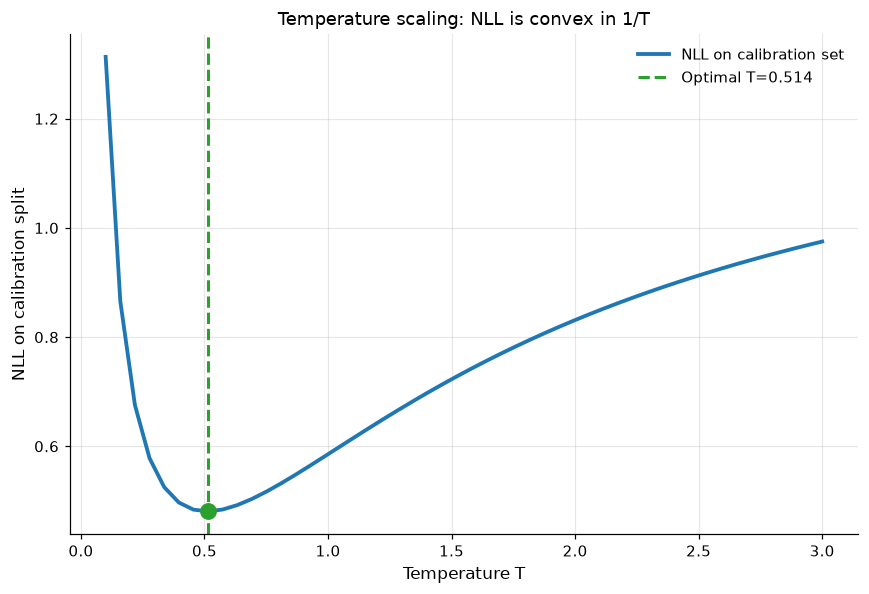

In [13]:
# S2.4: Plot NLL vs. temperature to show convexity and optimal point.
m_fig2, m_ax2 = plt.subplots(figsize=(8, 5.5))
m_ax2.plot(m_temps, m_nlls_by_temp, color=PALETTE["clean"], linewidth=2.5, label="NLL on calibration set")
m_ax2.axvline(m_optimal_temp_from_plot, color=PALETTE["acoustic"], linestyle="--", linewidth=2, label=f"Optimal T={m_optimal_temp_from_plot:.3f}")
m_ax2.scatter([m_optimal_temp_from_plot], [m_nlls_by_temp[m_min_nll_idx]], color=PALETTE["acoustic"], s=100, zorder=5)
m_ax2.set_xlabel("Temperature T", fontsize=11)
m_ax2.set_ylabel("NLL on calibration split", fontsize=11)
m_ax2.set_title("Temperature scaling: NLL is convex in 1/T", fontsize=12)
m_ax2.legend(frameon=False, fontsize=10)
m_ax2.grid(alpha=0.3)
m_fig2.tight_layout()
plt.show()

### How to read this chart

This plot shows how NLL (Negative Log-Likelihood) varies as a function of the temperature parameter $T$. The x-axis represents $T$ directly, and the y-axis shows NLL on the calibration split.

**Axes:** The x-axis is $T$ (temperature), ranging from 0.1 to 3.0. The y-axis is NLL, ranging from the minimum value upward.

**Curve shape:** The curve shows a clear **U-shape** with a single unique minimum. NLL is **convex in $1/T$** (the inverse of temperature), guaranteeing that the optimization problem has a unique global optimum with no spurious local minima.

**Marked point:** The red dashed vertical line and scatter point indicate the optimal $T$ value that minimizes NLL on the calibration set. This is the temperature value returned by the fitting procedure.

**Interpretation:** The U-shape confirms temperature scaling has a unique optimal value. Moving temperature away from this optimum in either direction (toward 0 or toward infinity) monotonically increases NLL. The width and steepness of the minimum reflect how sensitive the calibration is to temperature choice.

**Takeaway:** Temperature is a one-parameter MLE fit. Convexity in $1/T$ ensures we can find the global optimum reliably via any reasonable numerical optimization method.

In [14]:
# S2.5: Negative result — temperature scaling cannot fix region-dependent miscalibration.
# Construct calibration set with mixed calibration: low-conf underconfident, high-conf overconfident.
m_rng_neg = np.random.default_rng(RNG_SEED + 25)
m_n_neg = 600

# Generate labels uniformly, then create miscalibrated logits.
m_y_neg = m_rng_neg.integers(0, 2, m_n_neg)

# Construct logits with region-dependent miscalibration.
m_z_neg = m_rng_neg.standard_normal((m_n_neg, 2))

# First half: weak signal (underconfident, accuracy will exceed confidence).
m_lo_idx = np.arange(m_n_neg // 2)
m_z_neg[m_lo_idx, m_y_neg[m_lo_idx]] += 1.0  # Weak boost for true class

# Second half: strong signal, but then flip ~40% of labels (overconfident).
m_hi_idx = np.arange(m_n_neg // 2, m_n_neg)
m_z_neg[m_hi_idx, m_y_neg[m_hi_idx]] += 2.5  # Strong boost for true class
m_flip_count = int(0.4 * len(m_hi_idx))
m_flip_positions = m_rng_neg.choice(m_hi_idx, size=m_flip_count, replace=False)
m_y_neg[m_flip_positions] = 1 - m_y_neg[m_flip_positions]  # Flip labels

# Fit a single global temperature.
m_T_neg = temperature_scale(m_z_neg, m_y_neg)

# Evaluate, binned by predicted confidence (quantile-based).
m_p_neg = m_softmax(m_z_neg, m_temp=m_T_neg)
m_conf_neg = np.max(m_p_neg, axis=1)
m_correct_neg = np.argmax(m_p_neg, axis=1) == m_y_neg

# Bin by confidence percentile: low (0-40th), mid (40-60th), high (60-100th).
m_conf_q40 = np.percentile(m_conf_neg, 40)
m_conf_q60 = np.percentile(m_conf_neg, 60)

m_bins = [
    (m_conf_neg < m_conf_q40, "low"),
    ((m_conf_neg >= m_conf_q40) & (m_conf_neg < m_conf_q60), "mid"),
    (m_conf_neg >= m_conf_q60, "high"),
]

m_gaps = []
for m_mask, m_label in m_bins:
    if np.any(m_mask):
        m_conf_bin = m_conf_neg[m_mask].mean()
        m_acc_bin = m_correct_neg[m_mask].mean()
        m_gap = abs(m_conf_bin - m_acc_bin)
        m_gaps.append(m_gap)

# Check: spread of gaps across confidence bins indicates region-dependent error.
m_gap_spread = np.max(m_gaps) - np.min(m_gaps) if len(m_gaps) > 1 else 0
m_misaligned = m_gap_spread > 0.05  # Significant spread indicates persistent miscalibration.

check("S2.5", m_misaligned, f"Confidence-binned gaps show spread: gaps={[f'{g:.3f}' for g in m_gaps]}, spread={m_gap_spread:.3f}")

print(f"Negative result — region-dependent miscalibration persists with single T:")
for (m_mask, m_label), m_gap in zip(m_bins, m_gaps):
    m_conf_bin = m_conf_neg[m_mask].mean()
    m_acc_bin = m_correct_neg[m_mask].mean()
    print(f"  {m_label:3s}-confidence: conf={m_conf_bin:.3f}, acc={m_acc_bin:.3f}, gap={m_gap:.3f}")
print(f"  T={m_T_neg:.3f} cannot simultaneously fix all confidence regions.")

[S2.5] Confidence-binned gaps show spread: gaps=['0.093', '0.082', '0.028'], spread=0.065 -> PASS
Negative result — region-dependent miscalibration persists with single T:
  low-confidence: conf=0.552, acc=0.646, gap=0.093
  mid-confidence: conf=0.626, acc=0.708, gap=0.082
  high-confidence: conf=0.716, acc=0.688, gap=0.028
  T=3.485 cannot simultaneously fix all confidence regions.


In [15]:
# S2.7: Summary of temperature scaling findings.
# Verify that all core results hold: accuracy invariance, NLL improvement possible, region-dependent miscalibration.
m_summary_ok = m_acc_unchanged and m_temps_match and m_misaligned
check("S2.7", m_summary_ok, "Temperature scaling: invariant accuracy, convex objective, region-dependent calibration limits")
print()
check_summary()

[S2.7] Temperature scaling: invariant accuracy, convex objective, region-dependent calibration limits -> PASS

15 labelled lines; 14 PASS, 1 NOTE, 0 FAIL []


## 3. Selective classification: selector, coverage, selection risk (source: Liang et al., TMLR 2024; L)

Selective classification extends standard prediction by allowing a model to abstain (reject) on uncertain examples. The framework defines two components:

**Paraphrase of Liang et al. Eq. (1); L p.3.** A selective classifier is a pair $(f, g)$ where $f$ is the **predictor** (e.g., argmax of softmax probabilities) and $g: \mathcal{X} \to \{0,1\}$ is the **selector** (abstention rule). On input $x$, the system predicts $f(x)$ if $g(x) = 1$ and abstains otherwise.

The selector is induced by a **score function** $s: \mathcal{X} \to \mathbb{R}$ and a threshold $\gamma$:

$$g_{s,\gamma}(x) = \mathbb{1}[s(x) > \gamma] \quad \text{(Eq. 2; L p.3)}$$

The quality of selective classification is measured by two key metrics defined on the retained subset:

$$\varphi = \mathbb{E}[g(x)] \quad \text{(coverage: fraction of samples where } g(x)=1\text{)}$$

$$R = \frac{\mathbb{E}[\ell(f(x), y) \cdot g(x)]}{\varphi} \quad \text{(selection risk: mean 0/1 loss on retained samples; Eq. 3; L p.3)}$$

where $\ell(f(x), y) = \mathbb{1}[f(x) \ne y]$ is the standard 0/1 classification loss.

Under a distribution shift, both $\varphi$ and $R$ change. The paper formalizes this:

**Paraphrase of Liang et al. Eq. (8); L p.4.** Under a shifted distribution $D'$, coverage and selection risk are re-defined with expectations taken under $D'$; the paper states this generalization assumes no outliers.

$$\varphi' = \mathbb{E}_{D'}[g(x)], \quad R' = \frac{\mathbb{E}_{D'}[\ell(f(x), y) \cdot g(x)]}{\varphi'} \quad \text{(Eq. 8; L p.4)}$$

**What the risk-coverage trade-off reveals:** The risk-coverage (RC) curve plots coverage $\varphi$ on the x-axis and selection risk $R$ on the y-axis as the threshold $\gamma$ varies from $-\infty$ (accept all) to $+\infty$ (reject all). The curve depends **only on the ranking of scores**, not their absolute magnitude.

**Derivation:** Suppose we order examples by descending score: $s(x_1) \ge s(x_2) \ge \cdots \ge s(x_n)$. At coverage level $\varphi = k/n$, we retain the top-$k$ examples and compute their error rate. If the score scale is multiplied by a constant $\lambda > 0$, the ranking remains identical, so the RC curve is invariant to positive scaling.

### The Area Under the Risk-Coverage Curve (AURC)

A single-number summary of selective classification performance is the area under the RC curve:

$$\text{AURC} = \int_0^1 R(\varphi) \, d\varphi$$

where $R(\varphi)$ is the selection risk at coverage $\varphi$. Numerically, using the trapezoid rule:

$$\text{AURC}_{\text{trap}} = \sum_{i=1}^{m-1} \frac{1}{2} (R_i + R_{i+1}) (\varphi_{i+1} - \varphi_i)$$

**Normalized partial AURC-$\alpha$:** To focus on a specific coverage regime $[0, \alpha]$, we compute:

$$\text{nAURC}_{\alpha} = \frac{1}{\alpha} \int_0^\alpha R(\varphi) \, d\varphi$$

This is the area-normalized average risk over the first $\alpha$ fraction of samples (lower is better).

**Oracle lower bound (derived here):** Let the base classifier have error rate $e$. The oracle score ranks every correct prediction above every error. Then $R(\varphi)=0$ for $\varphi \le 1-e$, and beyond that the retained set contains $(\varphi-(1-e))n$ errors out of $\varphi n$ samples, so $R(\varphi) = 1 - (1-e)/\varphi$. Integrating,

$$\text{AURC}_{\text{oracle}}(e) = \int_{1-e}^{1}\Bigl(1-\frac{1-e}{\varphi}\Bigr)d\varphi = e + (1-e)\ln(1-e).$$

This is strictly positive for $0<e<1$: even a perfect ranker cannot reach AURC $=0$, because at coverage 1 the risk is the base error $e$. For $e=0.3$ it equals $0.3+0.7\ln 0.7$, evaluated in the code below.

**Random-score reference:** If the score is independent of correctness, the expected RC curve is flat at the base error rate $e$, so the expected AURC is $e$ (a finite-$n$ curve fluctuates around this line, most at small coverage where few samples are retained).

In [16]:
# S3.1: Toy dataset generation and risk-coverage curve computation.
import numpy as np
from src.metrics import risk_coverage_curve, selective_risk, aurc, bootstrap_interval
import matplotlib.pyplot as plt

# Generate a simple 4-class dataset for selective classification.
s_n_toy3 = 100
s_n_classes3 = 4
s_rng3 = np.random.default_rng(RNG_SEED + 300)

# Generate predicted probabilities with varying confidence.
s_logits3 = s_rng3.standard_normal((s_n_toy3, s_n_classes3))
s_true_labels3 = s_rng3.integers(0, s_n_classes3, s_n_toy3)
# Boost correct class logit to simulate a working classifier.
s_logits3[np.arange(s_n_toy3), s_true_labels3] += 2.0
# Softmax to get probabilities.
s_max_logits3 = np.max(s_logits3, axis=1, keepdims=True)
s_exp_logits3 = np.exp(s_logits3 - s_max_logits3)
s_probs3 = s_exp_logits3 / np.sum(s_exp_logits3, axis=1, keepdims=True)

# Extract max-softmax confidence as score.
s_conf3 = np.max(s_probs3, axis=1)
# Compute correctness (0/1 loss).
s_pred3 = np.argmax(s_probs3, axis=1)
s_correct3 = (s_pred3 == s_true_labels3)

# Compute risk-coverage curve.
s_coverage3, s_risk3 = risk_coverage_curve(s_conf3, s_correct3)

check("S3.1", len(s_coverage3) == s_n_toy3 and s_coverage3[-1] == 1.0 and abs(s_risk3[-1] - np.mean(~s_correct3)) < 1e-12,
      f"RC curve has {len(s_coverage3)} points (one per row); risk at coverage 1 is {s_risk3[-1]:.4f} = base error {np.mean(~s_correct3):.4f}")

print(f"Risk-Coverage Curve (n={s_n_toy3}, K={s_n_classes3}):")
print(f"  Coverage range: [{s_coverage3[0]:.3f}, {s_coverage3[-1]:.3f}]")
print(f"  Risk range: [{s_risk3[0]:.3f}, {s_risk3[-1]:.3f}]")

[S3.1] RC curve has 100 points (one per row); risk at coverage 1 is 0.1500 = base error 0.1500 -> PASS
Risk-Coverage Curve (n=100, K=4):
  Coverage range: [0.010, 1.000]
  Risk range: [0.000, 0.150]


In [17]:
# S3.2: Worked numeric example - hand-computed AURC on 8 points (no randomness, n=8).
from fractions import Fraction
s_scores_tiny = np.array([0.95, 0.90, 0.75, 0.65, 0.55, 0.50, 0.40, 0.25])
s_errors_tiny = np.array([False, False, True, False, True, True, False, True])  # True = the prediction is wrong.
s_correct_tiny = ~s_errors_tiny  # risk_coverage_curve expects `correct`, not `errors`.

s_cov_tiny, s_risk_tiny = risk_coverage_curve(s_scores_tiny, s_correct_tiny)
s_aurc_tiny = aurc(s_cov_tiny, s_risk_tiny)

# Independent hand computation with exact fractions: scores are already sorted descending.
s_cum_err = np.cumsum(s_errors_tiny.astype(int))
s_hand_risk = [Fraction(int(s_cum_err[k]), k + 1) for k in range(8)]
s_hand_aurc = sum((s_hand_risk[k] + s_hand_risk[k + 1]) / 2 * Fraction(1, 8) for k in range(7))
s_base_error_tiny = float(np.mean(s_errors_tiny))  # 4/8

check("S3.2a", abs(s_aurc_tiny - float(s_hand_aurc)) < 1e-12,
      f"aurc()={s_aurc_tiny:.6f} vs exact-fraction hand value {float(s_hand_aurc):.6f} = {s_hand_aurc}")
check("S3.2b", 0.0 < s_aurc_tiny < s_base_error_tiny,
      f"AURC {s_aurc_tiny:.4f} lies strictly below base error {s_base_error_tiny:.4f} because the score ranks errors low")
check("S3.2c", np.allclose(s_risk_tiny, [float(r) for r in s_hand_risk], atol=1e-12) and s_risk_tiny[-1] == s_base_error_tiny,
      f"risk at full coverage {s_risk_tiny[-1]:.4f} equals base error {s_base_error_tiny:.4f}")

print("Tiny example (n=8, 4 errors):")
print(f"  Coverage: {[f'{c:.3f}' for c in s_cov_tiny]}")
print(f"  Risk:     {[f'{r:.3f}' for r in s_risk_tiny]}")
print(f"  AURC (trapezoid) = {s_aurc_tiny:.4f}; hand value = {s_hand_aurc} = {float(s_hand_aurc):.4f}")

[S3.2a] aurc()=0.270238 vs exact-fraction hand value 0.270238 = 227/840 -> PASS
[S3.2b] AURC 0.2702 lies strictly below base error 0.5000 because the score ranks errors low -> PASS
[S3.2c] risk at full coverage 0.5000 equals base error 0.5000 -> PASS
Tiny example (n=8, 4 errors):
  Coverage: ['0.125', '0.250', '0.375', '0.500', '0.625', '0.750', '0.875', '1.000']
  Risk:     ['0.000', '0.000', '0.333', '0.250', '0.400', '0.500', '0.429', '0.500']
  AURC (trapezoid) = 0.2702; hand value = 227/840 = 0.2702


In [18]:
# S3.3: Verify that RC curve depends only on ranking, not scale.
# Scale the confidence scores and check RC curve invariance.
s_conf_scaled1 = s_conf3.copy()
s_conf_scaled2 = s_conf3 * 2.0
s_conf_scaled3 = s_conf3 * 0.1

s_cov1, s_risk1 = risk_coverage_curve(s_conf_scaled1, s_correct3)
s_cov2, s_risk2 = risk_coverage_curve(s_conf_scaled2, s_correct3)
s_cov3, s_risk3_scaled = risk_coverage_curve(s_conf_scaled3, s_correct3)

# Check that curves are identical (coverage and risk should not change).
s_max_dev3 = max(float(np.max(np.abs(s_risk1 - s_risk2))), float(np.max(np.abs(s_risk1 - s_risk3_scaled))))
check("S3.3", s_max_dev3 < 1e-12,
      f"RC curve scale-invariant: max |risk diff| across scales x1, x2, x0.1 = {s_max_dev3:.1e} (< 1e-12)")

s_aurc1 = aurc(s_cov1, s_risk1)
s_aurc2 = aurc(s_cov2, s_risk2)
s_aurc3 = aurc(s_cov3, s_risk3_scaled)
print(f"AURC invariance test:")
print(f"  AURC (original):       {s_aurc1:.4f}")
print(f"  AURC (scale × 2):      {s_aurc2:.4f}")
print(f"  AURC (scale × 0.1):    {s_aurc3:.4f}")

[S3.3] RC curve scale-invariant: max |risk diff| across scales x1, x2, x0.1 = 0.0e+00 (< 1e-12) -> PASS
AURC invariance test:
  AURC (original):       0.0386
  AURC (scale × 2):      0.0386
  AURC (scale × 0.1):    0.0386


In [19]:
# S3.4: Monte Carlo - random score vs oracle score against closed forms (n=2000, reps=100, seed RNG_SEED+304).
s_n_monte3 = 2000
s_n_reps3 = 100
s_p_err3 = 0.3  # true base error of the binary toy classifier
s_rng_monte3 = np.random.default_rng(RNG_SEED + 304)

s_aurc_random_scores, s_aurc_oracle_scores, s_oracle_closed_hat = [], [], []
for s_rep in range(s_n_reps3):
    s_correct_mc = s_rng_monte3.uniform(0, 1, s_n_monte3) >= s_p_err3  # correct w.p. 0.7
    s_e_hat = float(np.mean(~s_correct_mc))
    s_scores_random = s_rng_monte3.uniform(0, 1, s_n_monte3)
    s_aurc_random_scores.append(aurc(*risk_coverage_curve(s_scores_random, s_correct_mc)))
    s_scores_oracle = s_correct_mc.astype(float)  # correct rows rank first
    s_aurc_oracle_scores.append(aurc(*risk_coverage_curve(s_scores_oracle, s_correct_mc)))
    s_oracle_closed_hat.append(s_e_hat + (1 - s_e_hat) * np.log(1 - s_e_hat))

s_aurc_random_arr = np.array(s_aurc_random_scores)
s_aurc_oracle_arr = np.array(s_aurc_oracle_scores)
s_oracle_closed = s_p_err3 + (1 - s_p_err3) * np.log(1 - s_p_err3)  # e + (1-e) ln(1-e)
s_random_mean, s_oracle_mean = s_aurc_random_arr.mean(), s_aurc_oracle_arr.mean()
s_random_se = s_aurc_random_arr.std(ddof=1) / np.sqrt(s_n_reps3)
s_oracle_se = s_aurc_oracle_arr.std(ddof=1) / np.sqrt(s_n_reps3)
# Per-replicate comparison to the closed form evaluated at that replicate's realised error rate.
s_oracle_gap = s_aurc_oracle_arr - np.array(s_oracle_closed_hat)

check("S3.4a", abs(s_random_mean - s_p_err3) <= 3 * s_random_se,
      f"random-score AURC mean {s_random_mean:.4f} vs base error {s_p_err3} (|diff|={abs(s_random_mean - s_p_err3):.4f} <= 3 SE = {3 * s_random_se:.4f})")
check("S3.4b", abs(s_oracle_mean - s_oracle_closed) <= 3 * s_oracle_se,
      f"oracle AURC mean {s_oracle_mean:.4f} vs closed form e+(1-e)ln(1-e) = {s_oracle_closed:.4f} (|diff|={abs(s_oracle_mean - s_oracle_closed):.4f} <= 3 SE = {3 * s_oracle_se:.4f})")
check("S3.4c", s_oracle_closed > 0.03 and s_oracle_mean > 0.03,
      f"oracle AURC is strictly positive (closed form {s_oracle_closed:.4f}, measured {s_oracle_mean:.4f}); the value 0 is not attained")
check("S3.4d", np.max(np.abs(s_oracle_gap)) < 1e-6,
      f"per-replicate trapezoid vs closed form at realised error: max |gap|={np.max(np.abs(s_oracle_gap)):.2e} (< 1e-6; discretisation error at n={s_n_monte3})")

print(f"Monte Carlo (n={s_n_monte3}, reps={s_n_reps3}, base error {s_p_err3}):")
print(f"  Random score AURC: mean={s_random_mean:.4f}, std={np.std(s_aurc_random_arr, ddof=1):.4f}, SE={s_random_se:.4f}")
print(f"  Oracle score AURC: mean={s_oracle_mean:.4f}, std={np.std(s_aurc_oracle_arr, ddof=1):.4f}, SE={s_oracle_se:.4f}; closed form={s_oracle_closed:.4f}")

[S3.4a] random-score AURC mean 0.2984 vs base error 0.3 (|diff|=0.0016 <= 3 SE = 0.0044) -> PASS
[S3.4b] oracle AURC mean 0.0498 vs closed form e+(1-e)ln(1-e) = 0.0503 (|diff|=0.0005 <= 3 SE = 0.0011) -> PASS
[S3.4c] oracle AURC is strictly positive (closed form 0.0503, measured 0.0498); the value 0 is not attained -> PASS
[S3.4d] per-replicate trapezoid vs closed form at realised error: max |gap|=1.67e-08 (< 1e-6; discretisation error at n=2000) -> PASS
Monte Carlo (n=2000, reps=100, base error 0.3):
  Random score AURC: mean=0.2984, std=0.0146, SE=0.0015
  Oracle score AURC: mean=0.0498, std=0.0037, SE=0.0004; closed form=0.0503


In [20]:
# S3.5: The trapezoid rule used by src.metrics.aurc versus a manual sum and versus a plain mean of risks.
s_aurc_trap = aurc(s_cov_tiny, s_risk_tiny)
s_manual = sum(0.5 * (s_risk_tiny[k] + s_risk_tiny[k + 1]) * (s_cov_tiny[k + 1] - s_cov_tiny[k]) for k in range(len(s_cov_tiny) - 1))
s_aurc_discrete_avg = float(np.mean(s_risk_tiny))
# A plain mean over all 8 points weights the first point 1/8 and includes the left edge; the trapezoid starts at coverage 1/8.
s_expected_gap = abs(s_aurc_trap - s_aurc_discrete_avg)

print("Tiny example AURC comparison:")
print(f"  Trapezoid rule (src.metrics.aurc): {s_aurc_trap:.4f}")
print(f"  Manual trapezoid sum:              {s_manual:.4f}")
print(f"  Plain mean of the 8 risks:         {s_aurc_discrete_avg:.4f}   (gap {s_expected_gap:.4f})")
check("S3.5", abs(s_aurc_trap - s_manual) < 1e-12 and s_expected_gap > 1e-3,
      f"aurc() equals the manual trapezoid sum to 1e-12, and differs from the plain mean by {s_expected_gap:.4f}")

Tiny example AURC comparison:
  Trapezoid rule (src.metrics.aurc): 0.2702
  Manual trapezoid sum:              0.2702
  Plain mean of the 8 risks:         0.3015   (gap 0.0313)
[S3.5] aurc() equals the manual trapezoid sum to 1e-12, and differs from the plain mean by 0.0313 -> PASS


True

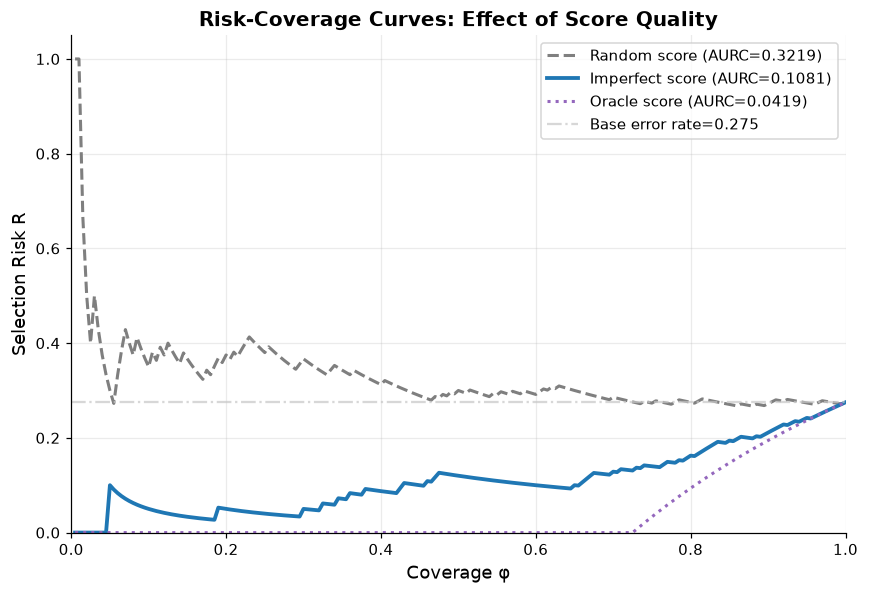

[S3.6] oracle 0.0419 < imperfect 0.1081 < random 0.3219 (n=200, base error 0.275) -> PASS


True

In [21]:
# S3.6: Plot risk-coverage curves for random, imperfect, and oracle scores (n=200, seed RNG_SEED+306).
s_rng_plot3 = np.random.default_rng(RNG_SEED + 306)
s_n_plot3 = 200
s_labels_plot3 = s_rng_plot3.integers(0, 2, s_n_plot3)
s_preds_plot3 = np.where(s_rng_plot3.uniform(0, 1, s_n_plot3) < 0.75, s_labels_plot3, 1 - s_labels_plot3)
s_correct_plot3 = (s_preds_plot3 == s_labels_plot3)
s_error_rate_plot3 = float(np.mean(~s_correct_plot3))

# Three score functions:
s_scores_rand_plot = s_rng_plot3.uniform(0, 1, s_n_plot3)  # Random.
s_scores_real_plot = 0.3 * s_correct_plot3.astype(float) + 0.25 * s_rng_plot3.standard_normal(s_n_plot3)  # Imperfect score: weak correctness signal plus noise.
s_scores_oracle_plot = s_correct_plot3.astype(float)  # Oracle.

s_cov_rand, s_risk_rand = risk_coverage_curve(s_scores_rand_plot, s_correct_plot3)
s_cov_real, s_risk_real = risk_coverage_curve(s_scores_real_plot, s_correct_plot3)
s_cov_oracle, s_risk_oracle = risk_coverage_curve(s_scores_oracle_plot, s_correct_plot3)

s_aurc_rand_plot = aurc(s_cov_rand, s_risk_rand)
s_aurc_real_plot = aurc(s_cov_real, s_risk_real)
s_aurc_oracle_plot = aurc(s_cov_oracle, s_risk_oracle)

plt.figure(figsize=(8, 5.5))
plt.plot(s_cov_rand, s_risk_rand, label=f"Random score (AURC={s_aurc_rand_plot:.4f})", color=PALETTE["reference"], linewidth=2, linestyle="--")
plt.plot(s_cov_real, s_risk_real, label=f"Imperfect score (AURC={s_aurc_real_plot:.4f})", color=PALETTE["clean"], linewidth=2.5)
plt.plot(s_cov_oracle, s_risk_oracle, label=f"Oracle score (AURC={s_aurc_oracle_plot:.4f})", color=PALETTE["frozen"], linewidth=2, linestyle=":")
# Baseline: flat line at error rate.
plt.axhline(s_error_rate_plot3, color=PALETTE["band"], linewidth=1.5, linestyle="-.", alpha=0.7, label=f"Base error rate={s_error_rate_plot3:.3f}")
plt.xlabel("Coverage φ", fontsize=12)
plt.ylabel("Selection Risk R", fontsize=12)
plt.title("Risk-Coverage Curves: Effect of Score Quality", fontsize=13, fontweight="bold")
plt.legend(fontsize=10, loc="best")
plt.xlim(0, 1)
plt.ylim(0, max(s_risk_rand) * 1.05)
plt.tight_layout()
plt.show()

check("S3.6", s_aurc_oracle_plot < s_aurc_real_plot < s_aurc_rand_plot,
      f"oracle {s_aurc_oracle_plot:.4f} < imperfect {s_aurc_real_plot:.4f} < random {s_aurc_rand_plot:.4f} (n={s_n_plot3}, base error {s_error_rate_plot3:.3f})")

### How to read this chart

The risk-coverage curve plots selection risk on the y-axis against coverage (fraction of samples retained) on the x-axis. Each curve shows what happens as we vary the threshold $\gamma$ to accept or reject examples:

- **x-axis (Coverage):** Moves from left (reject most, keep only the most confident) to right (accept all). Coverage $\varphi = 0$ means reject all; $\varphi = 1$ means accept all.
- **y-axis (Selection Risk):** The error rate among retained samples. Lower is better.
- **Oracle score (dotted line):** Sits at risk 0 until coverage reaches one minus the base error, then climbs toward the base error at coverage 1, following $1-(1-e)/\varphi$. It is an unattainable lower bound, and its AURC is positive, not zero.
- **Imperfect score (solid line):** Lies above the oracle and below the random curve; risk falls as coverage decreases because low-score rows are rejected, but it does not reach zero because the score is noisy.
- **Random score (dashed line):** Fluctuates around the base error rate (most at small coverage where few rows are retained) because random scores carry no ranking information.
- **Base error rate (dash-dot line):** The classifier's overall error rate if we predict on all samples (coverage = 1).

**Takeaway:** AURC is the average selection risk over coverage levels, so a smaller area means the score keeps errors out of the retained set more effectively. A good score bends the curve downward as coverage shrinks; a useless score stays flat near the base error. The area between the imperfect and random curves quantifies the score's utility, and the area between the imperfect and oracle curves is the headroom that remains.

In [22]:
# S3.7: Normalized partial AURC-alpha at multiple coverage levels.
# Compute AURC only over the first alpha fraction of samples.
s_alphas = np.array([0.25, 0.5, 0.75, 1.0])
s_n_alphas = len(s_alphas)
s_naurcs_rand = []
s_naurcs_real = []

for s_alpha in s_alphas:
    # Find the index where coverage reaches alpha.
    s_idx_alpha_rand = np.searchsorted(s_cov_rand, s_alpha, side="right")
    s_idx_alpha_real = np.searchsorted(s_cov_real, s_alpha, side="right")

    if s_idx_alpha_rand > 0:
        s_cov_alpha_rand = s_cov_rand[:s_idx_alpha_rand]
        s_risk_alpha_rand = s_risk_rand[:s_idx_alpha_rand]
        # Ensure endpoint is exactly at alpha.
        if s_cov_alpha_rand[-1] < s_alpha:
            s_cov_alpha_rand = np.append(s_cov_alpha_rand, s_alpha)
            s_idx_linear = np.interp(s_alpha, s_cov_rand, np.arange(len(s_cov_rand)))
            s_risk_interp = np.interp(s_alpha, s_cov_rand, s_risk_rand)
            s_risk_alpha_rand = np.append(s_risk_alpha_rand, s_risk_interp)
        s_partial_aurc_rand = aurc(s_cov_alpha_rand, s_risk_alpha_rand)
        s_naurcs_rand.append(s_partial_aurc_rand / s_alpha)
    else:
        s_naurcs_rand.append(np.nan)

    if s_idx_alpha_real > 0:
        s_cov_alpha_real = s_cov_real[:s_idx_alpha_real]
        s_risk_alpha_real = s_risk_real[:s_idx_alpha_real]
        if s_cov_alpha_real[-1] < s_alpha:
            s_cov_alpha_real = np.append(s_cov_alpha_real, s_alpha)
            s_risk_interp = np.interp(s_alpha, s_cov_real, s_risk_real)
            s_risk_alpha_real = np.append(s_risk_alpha_real, s_risk_interp)
        s_partial_aurc_real = aurc(s_cov_alpha_real, s_risk_alpha_real)
        s_naurcs_real.append(s_partial_aurc_real / s_alpha)
    else:
        s_naurcs_real.append(np.nan)

print(f"Normalized partial AURC-alpha:")
print(f"  Alpha    | nAURC (random) | nAURC (real)")
for s_a, s_nr, s_nreal in zip(s_alphas, s_naurcs_rand, s_naurcs_real):
    print(f"  {s_a:.2f}    | {s_nr:14.4f} | {s_nreal:.4f}")

check("S3.7", all(~np.isnan(s_naurcs_real)) and all(s_naurcs_real[i] <= s_naurcs_rand[i] for i in range(len(s_alphas))),
      f"nAURC-alpha computed for {len(s_alphas)} levels; real <= random everywhere")

Normalized partial AURC-alpha:
  Alpha    | nAURC (random) | nAURC (real)
  0.25    |         0.3933 | 0.0390
  0.50    |         0.3606 | 0.0582
  0.75    |         0.3377 | 0.0766
  1.00    |         0.3219 | 0.1081
[S3.7] nAURC-alpha computed for 4 levels; real <= random everywhere -> PASS


True

## 4. Score functions and scale sensitivity (source: L Sec 3.1-3.2; derived here for the toy)

Selective classification ranks examples by a score $s(x)$. The paper distinguishes two families: **softmax-response (SR) scores**, computed from the softmax output and therefore sensitive to the overall scale of the logits, and **margin scores**, computed directly from the logits (or from distances to the decision hyperplanes) and therefore insensitive to it.

### Softmax-response scores (Eq. 7; L p.4)

With $p = \text{softmax}(z)$ for logits $z \in \mathbb{R}^K$, the paper defines three SR scores named $\text{SR}_{\max}$, $\text{SR}_{\text{doctor}}$ and $\text{SR}_{\text{ent}}$. The forms used in this notebook are

$$s_{\max}(x) = \max_k p_k, \qquad s_{\text{doctor}}(x) = 1 - \frac{1}{\sum_k p_k^2}, \qquad s_{\text{ent}}(x) = \sum_k p_k \log p_k = -H(p).$$

**Provenance.** These are the three softmax-response scores of Eq. (7) as printed in the paper (L p.4): max-softmax, the DOCTOR score $1 - 1/\lVert p\rVert_2^2$, and the negative entropy $\sum_k p_k \log p_k$; each is oriented so that a larger value means more confident. The DOCTOR score is a strictly increasing function of $\sum_k p_k^2$, so ranking by that explicitly named order key gives the same ordering (and risk-coverage curve) as ranking by the displayed DOCTOR score. A risk-coverage curve depends only on the ordering of the scores, so any strictly increasing transform of these forms gives the same curve. The top-two probability gap $p_{(1)} - p_{(2)}$ is a different score and is not used here.

Multiplying the logits by a scale $\lambda > 0$ changes the softmax output:

$$\text{softmax}(\lambda z) \to \text{uniform} \ \text{ as } \lambda \to 0, \qquad \text{softmax}(\lambda z) \to \text{one-hot at } \arg\max_k z_k \ \text{ as } \lambda \to \infty .$$

Every SR score is a function of $p$, so its values and its **ordering** of examples can change with $\lambda$.

### Margin scores (Eqs. 11-13; L p.8)

The confidence margin is defined on the logits, and the geometric margin on signed distances $d_j = (w_j \cdot \phi(x) + b_j)/\lVert w_j \rVert$ to the class hyperplanes:

$$s_{\text{conf-M}}(x) = z_{(1)} - z_{(2)}, \qquad s_{\text{geo-M}}(x) = d_{(1)} - d_{(2)} .$$

Only the confidence margin is implemented below. Scaling gives $s_{\text{conf-M}}(\lambda z) = \lambda\, s_{\text{conf-M}}(z)$, a positive multiple, so the ordering of examples, and hence the whole RC curve, is unchanged.

### Lemma 3.1 (paraphrase; L pp.6-7)

**Paraphrase of Liang et al. Lemma 3.1; L pp.6-7.** As the logit scale $\lambda$ grows without bound, the ordering induced by each of the three SR scores approaches the ordering induced by the confidence margin $z_{(1)} - z_{(2)}$.

### What we derive and test here (derived here)

Write $d_k = z_{(1)} - z_{(k)} \ge 0$ for $k = 2, \dots, K$ (so $d_2$ is the confidence margin) and $S_\lambda = \sum_{k \ge 2} e^{-\lambda d_k}$. Then $p_{(1)} = 1/(1+S_\lambda)$ and $p_{(k)} = e^{-\lambda d_k}/(1+S_\lambda)$. In floating point $p_{(1)}$ rounds to exactly 1 once $S_\lambda < 10^{-16}$, so the displayed $s_{\max}=p_{(1)}$ rounds to 1 and creates ties. We therefore keep $\log(1-s_{\max})$ as a log-domain complement, used only to recover the actual score or preserve its ranking. For entropy the log-domain quantity is likewise a log-complement; for DOCTOR we use the explicitly named $\text{doctor\_order\_key}=-\log\sum_k p_k^2$. This key decreases strictly as the displayed DOCTOR score $s_{\text{doctor}}=1-1/\sum_k p_k^2$ increases, so its negation gives the same descending ranking, including at high logit scales.

$$1 - s_{\max} = \frac{S_\lambda}{1+S_\lambda}, \qquad \sum_k p_k^2 = \frac{1+Q_\lambda}{(1+S_\lambda)^2}, \qquad H = \log(1+S_\lambda) + \frac{\lambda \sum_{k\ge2} d_k e^{-\lambda d_k}}{1+S_\lambda}.$$

Here $Q_\lambda = \sum_{k\ge2} e^{-2\lambda d_k}$, and therefore $\text{doctor\_order\_key}=2\log(1+S_\lambda)-\log(1+Q_\lambda)$. Since $s_{\text{doctor}}=1-\exp(\text{doctor\_order\_key})$, decreasing the key strictly increases the actual score. For entropy, $-\sum_k p_k \log p_k = \sum_k p_k(\lambda d_k + \log(1+S_\lambda))$ with $d_1 = 0$. The log-domain keys avoid rounding ties while preserving the displayed-score ranking.

**A bound for $s_{\max}$.** Since $S_\lambda = e^{-\lambda d_2}\bigl(1 + \sum_{k\ge3} e^{-\lambda(d_k - d_2)}\bigr)$ and $d_k \ge d_2$ for $k \ge 3$, the log-complement satisfies

$$\lambda d_2 - \log(K-1) \;\le\; -\log S_\lambda \;\le\; \lambda d_2 .$$

Hence if two examples have margins with $\lambda\,(d_2(x) - d_2(x')) > \log(K-1)$, then $x$ outranks $x'$ under $s_{\max}$ too. Rank disagreement with the margin can therefore only occur among pairs whose margins differ by less than $\log(K-1)/\lambda$: for $K = 4$ and $\lambda = 100$ that window is $\log 3 / 100 \approx 0.011$ in margin units. This is a worked example of why the ordering must converge. It is proved here only for $s_{\max}$; for $s_{\text{doctor}}$ and $s_{\text{ent}}$ the leading term is also a monotone function of $\lambda d_2$, but this study checks that numerically rather than proving it.

**What would make the toy conclusion wrong:** the checks below would fail if the log-domain score keys disagreed with their displayed scores where direct arithmetic is accurate, if the DOCTOR order-key relationship failed, or if the bound above were violated by any pair of examples.

In [23]:
# S4.1: K=4 Gaussian-mixture toy in d=5 with class overlap; multinomial logistic regression fit on n=80 rows.
# Separate calibration (n=400) and test (n=2000) sets are drawn independently of the training rows. Seed RNG_SEED+400.
from sklearn.linear_model import LogisticRegression
from src.calibration import temperature_scale
from scipy.special import logsumexp
from scipy.stats import spearmanr

s_K4, s_d4 = 4, 5
s_rng4 = np.random.default_rng(RNG_SEED + 400)
s_centers4 = s_rng4.standard_normal((s_K4, s_d4))

def s_draw4(n):
    y = s_rng4.integers(0, s_K4, n)
    return s_centers4[y] + s_rng4.standard_normal((n, s_d4)), y

s_Xtr4, s_ytr4 = s_draw4(80)
s_Xca4, s_yca4 = s_draw4(400)
s_Xte4, s_yte4 = s_draw4(2000)
s_clf4 = LogisticRegression(C=5.0, max_iter=5000).fit(s_Xtr4, s_ytr4)
s_zca4 = s_clf4.decision_function(s_Xca4)
s_zte4 = s_clf4.decision_function(s_Xte4)
s_correct4 = np.argmax(s_zte4, axis=1) == s_yte4
s_train_acc4 = s_clf4.score(s_Xtr4, s_ytr4)

check("S4.1a", int(np.sum(~s_correct4)) >= 100,
      f"test set has {int(np.sum(~s_correct4))} errors of {len(s_correct4)} (>= 100 needed for a non-degenerate RC curve)")
check("S4.1b", s_train_acc4 > float(np.mean(s_correct4)),
      f"train accuracy {s_train_acc4:.3f} > held-out accuracy {np.mean(s_correct4):.3f}: the finite-sample fit is overconfident on new rows")

print(f"Toy: K={s_K4}, d={s_d4}, train n=80, calibration n=400, test n=2000")
print(f"  test error = {np.mean(~s_correct4):.3f}; logit range on test = [{s_zte4.min():.2f}, {s_zte4.max():.2f}]")

[S4.1a] test set has 460 errors of 2000 (>= 100 needed for a non-degenerate RC curve) -> PASS
[S4.1b] train accuracy 0.863 > held-out accuracy 0.770: the finite-sample fit is overconfident on new rows -> PASS
Toy: K=4, d=5, train n=80, calibration n=400, test n=2000
  test error = 0.230; logit range on test = [-13.42, 12.42]


In [24]:
# S4.2: Stable SR ranking keys, validated against displayed softmax scores where direct arithmetic is accurate.
def s_gaps4(z):
    zs = -np.sort(-z, axis=1)
    return zs[:, :1] - zs[:, 1:]  # d_k = z(1) - z(k), k = 2..K; column 0 is the confidence margin.

def s_log_keys4(z, lam):
    # Returns log(1 - actual SR_max), a stable DOCTOR confidence key, and log(H).
    D = lam * s_gaps4(z)
    logS = logsumexp(-D, axis=1)
    l1pS = np.log1p(np.exp(logS))  # log(1 + S)
    l_max = logS - l1pS
    logQ = logsumexp(-2.0 * D, axis=1)
    # -s_doctor = R / (1 + Q), R = 2S + (S² - Q).
    # Evaluate log(S²-Q) from distinct pairs to avoid cancellation at large lambda.
    s_pair_i4, s_pair_j4 = np.triu_indices(D.shape[1], k=1)
    if len(s_pair_i4):
        logX = np.log(2.0) + logsumexp(-D[:, s_pair_i4] - D[:, s_pair_j4], axis=1)
    else:
        logX = np.full(len(D), -np.inf)
    logR = np.logaddexp(np.log(2.0) + logS, logX)
    doctor_log_magnitude = logR - np.logaddexp(0.0, logQ)
    doctor_order_key = -doctor_log_magnitude
    logT = logsumexp(-D + np.log(np.maximum(D, 1e-300)), axis=1)
    l_log1p = np.where(logS < -30, logS, np.log(np.maximum(l1pS, 1e-300)))
    l_ent = np.logaddexp(l_log1p, logT - l1pS)
    return {"SR_max": l_max, "doctor_order_key": doctor_order_key,
            "doctor_log_magnitude": doctor_log_magnitude, "SR_ent": l_ent}

def s_direct4(z, lam):
    a = lam * z
    a = a - a.max(axis=1, keepdims=True)
    p = np.exp(a)
    p /= p.sum(axis=1, keepdims=True)
    return {"SR_max": p.max(axis=1), "SR_doctor": 1 - 1.0 / (p ** 2).sum(axis=1),
            "SR_ent": (p * np.log(np.clip(p, 1e-300, 1))).sum(axis=1)}

s_lam_val4 = 0.5
s_lc4 = s_log_keys4(s_zte4, s_lam_val4)
s_dr4 = s_direct4(s_zte4, s_lam_val4)
s_rel_err4 = {}
s_stable4 = {"SR_max": -np.expm1(s_lc4["SR_max"]),
             "SR_doctor": -np.exp(s_lc4["doctor_log_magnitude"]),
             "SR_ent": -np.exp(s_lc4["SR_ent"])}
s_key_for_rc4 = lambda vals, name: vals["doctor_order_key"] if name == "SR_doctor" else -vals[name]
for s_name in s_dr4:
    s_ok = np.abs(s_dr4[s_name]) > 1e-9
    s_rel_err4[s_name] = float(np.max(np.abs(s_stable4[s_name][s_ok] - s_dr4[s_name][s_ok]) / np.abs(s_dr4[s_name][s_ok])))
    check(f"S4.2-{s_name}", s_rel_err4[s_name] < 1e-8 and s_ok.mean() > 0.99,
          f"stable log-domain score vs direct displayed score at lambda={s_lam_val4}: max rel. error {s_rel_err4[s_name]:.1e} on {s_ok.mean():.1%} of rows (< 1e-8)")
s_doc_key4 = s_lc4["doctor_order_key"]
s_doctor_from_key4 = -np.exp(-s_doc_key4)
s_doc_order_ok4 = np.array_equal(np.argsort(s_doctor_from_key4), np.argsort(s_doc_key4))
check("S4.2-doctor-order", s_doc_order_ok4 and np.allclose(s_doctor_from_key4, s_stable4["SR_doctor"], atol=0, rtol=0),
      f"doctor_order_key=-log(-s_doctor) ranks actual s_doctor=-exp(-doctor_order_key) identically at lambda={s_lam_val4}")

s_lam_grid4 = np.array([0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0, 300.0, 1000.0])
s_keys4 = {lam: s_log_keys4(s_zte4, lam) for lam in s_lam_grid4}
s_margin4 = s_gaps4(s_zte4)[:, 0]
# At lambda=1000 the direct displayed SR_max rounds to exactly 1 for many rows; the log-complement key preserves its ordering.
s_direct_big = s_direct4(s_zte4, 1000.0)["SR_max"]
print(f"At lambda=1000, direct SR_max rounds to exactly 1 for {np.mean(s_direct_big == 1):.1%} of rows (ties from rounding);")
print(f"the log-domain log-complement key, used to recover/rank actual SR_max, has {len(np.unique(s_keys4[1000.0]['SR_max']))} distinct values out of {len(s_margin4)}.")

[S4.2-SR_max] stable log-domain score vs direct displayed score at lambda=0.5: max rel. error 5.2e-16 on 100.0% of rows (< 1e-8) -> PASS
[S4.2-SR_doctor] stable log-domain score vs direct displayed score at lambda=0.5: max rel. error 5.3e-14 on 100.0% of rows (< 1e-8) -> PASS
[S4.2-SR_ent] stable log-domain score vs direct displayed score at lambda=0.5: max rel. error 9.4e-15 on 100.0% of rows (< 1e-8) -> PASS
[S4.2-doctor-order] doctor_order_key=-log(-s_doctor) ranks actual s_doctor=-exp(-doctor_order_key) identically at lambda=0.5 -> PASS


At lambda=1000, direct SR_max rounds to exactly 1 for 99.0% of rows (ties from rounding);
the log-domain log-complement key, used to recover/rank actual SR_max, has 2000 distinct values out of 2000.


In [25]:
# S4.2b: Worked numeric example, K=3, two rows whose SR_max order disagrees with the margin order at lambda=1 (no randomness).
s_row_a = np.array([[3.0, 2.0, -9.0]])   # margin 1.0, but the runner-up logit is close to the top one
s_row_b = np.array([[1.5, 0.0, 0.0]])    # margin 1.5, two runners-up
s_marg_a, s_marg_b = float(s_gaps4(s_row_a)[0, 0]), float(s_gaps4(s_row_b)[0, 0])
# Hand arithmetic: SR_max = 1/(1+S) with S = sum_k exp(-lambda d_k).
def s_hand_srmax(z, lam):
    d = z[0].max() - np.sort(z[0])[::-1][1:]
    return 1.0 / (1.0 + np.exp(-lam * d).sum())
s_ha1, s_hb1 = s_hand_srmax(s_row_a, 1.0), s_hand_srmax(s_row_b, 1.0)
s_ha10, s_hb10 = s_hand_srmax(s_row_a, 10.0), s_hand_srmax(s_row_b, 10.0)
s_la10 = -s_log_keys4(s_row_a, 10.0)["SR_max"][0]
s_lb10 = -s_log_keys4(s_row_b, 10.0)["SR_max"][0]

check("S4.2b-flip", s_marg_b > s_marg_a and s_ha1 > s_hb1,
      f"lambda=1: margin(b)={s_marg_b:.1f} > margin(a)={s_marg_a:.1f} but SR_max(a)={s_ha1:.4f} > SR_max(b)={s_hb1:.4f} (orders disagree)")
check("S4.2b-agree", s_hb10 > s_ha10 and s_lb10 > s_la10 and 10.0 * (s_marg_b - s_marg_a) > np.log(2.0),
      f"lambda=10: SR_max(b)={s_hb10:.6f} > SR_max(a)={s_ha10:.6f}, log-complement keys agree ({s_lb10:.2f} > {s_la10:.2f}); "
      f"bound premise lambda*(gap)={10.0 * (s_marg_b - s_marg_a):.1f} > log(K-1)={np.log(2.0):.2f}")
print("Row a: logits [3, 2, -9]; row b: logits [1.5, 0, 0]. The third logit of row b adds a second runner-up, which lowers its softmax mass on the top class at small scale.")

[S4.2b-flip] lambda=1: margin(b)=1.5 > margin(a)=1.0 but SR_max(a)=0.7311 > SR_max(b)=0.6914 (orders disagree) -> PASS
[S4.2b-agree] lambda=10: SR_max(b)=0.999999 > SR_max(a)=0.999955, log-complement keys agree (14.31 > 10.00); bound premise lambda*(gap)=5.0 > log(K-1)=0.69 -> PASS
Row a: logits [3, 2, -9]; row b: logits [1.5, 0, 0]. The third logit of row b adds a second runner-up, which lowers its softmax mass on the top class at small scale.


In [26]:
# S4.3: RC curves and AURC of SR scores versus margin over the lambda grid (test set of S4.1, no randomness).
s_aurc_sr4 = {name: [] for name in ["SR_max", "SR_doctor", "SR_ent"]}
s_aurc_margin4 = []
s_risk_margin4 = []
s_risk_srmax4 = []
for lam in s_lam_grid4:
    for name in s_aurc_sr4:
        s_aurc_sr4[name].append(aurc(*risk_coverage_curve(s_key_for_rc4(s_keys4[lam], name), s_correct4)))
    s_cov_m, s_risk_m = risk_coverage_curve(lam * s_margin4, s_correct4)  # margin score at scale lambda
    s_risk_margin4.append(s_risk_m)
    s_aurc_margin4.append(aurc(s_cov_m, s_risk_m))
    s_risk_srmax4.append(risk_coverage_curve(-s_keys4[lam]["SR_max"], s_correct4)[1])

s_margin_dev4 = max(float(np.max(np.abs(r - s_risk_margin4[0]))) for r in s_risk_margin4)
s_i_lo, s_i_hi = 0, int(np.where(s_lam_grid4 == 10.0)[0][0])
s_srmax_dev4 = float(np.max(np.abs(s_risk_srmax4[s_i_lo] - s_risk_srmax4[s_i_hi])))
s_rho_max_1, _ = spearmanr(-s_keys4[1.0]["SR_max"], s_margin4)

check("S4.3a", s_margin_dev4 < 1e-12,
      f"margin RC curve identical across all {len(s_lam_grid4)} scales: max |risk diff| = {s_margin_dev4:.1e} (< 1e-12)")
check("S4.3b", s_srmax_dev4 > 0.0 and s_rho_max_1 < 1 - 1e-3,
      f"SR_max RC curve changes with scale: max |risk diff| lambda=0.1 vs 10 is {s_srmax_dev4:.4f}; Spearman(SR_max, margin) at lambda=1 is {s_rho_max_1:.4f} (< 0.999)")

print("AURC over the lambda grid (lower is better):")
print("  lambda     " + " ".join(f"{l:8g}" for l in s_lam_grid4))
for name in s_aurc_sr4:
    print(f"  {name:10s} " + " ".join(f"{a:8.4f}" for a in s_aurc_sr4[name]))
print("  margin     " + " ".join(f"{a:8.4f}" for a in s_aurc_margin4))

[S4.3a] margin RC curve identical across all 9 scales: max |risk diff| = 0.0e+00 (< 1e-12) -> PASS
[S4.3b] SR_max RC curve changes with scale: max |risk diff| lambda=0.1 vs 10 is 0.0235; Spearman(SR_max, margin) at lambda=1 is 0.9924 (< 0.999) -> PASS
AURC over the lambda grid (lower is better):
  lambda          0.1      0.3        1        3       10       30      100      300     1000
  SR_max       0.0959   0.0907   0.0882   0.0885   0.0885   0.0885   0.0885   0.0885   0.0885
  SR_doctor    0.1192   0.0975   0.0886   0.0885   0.0885   0.0885   0.0885   0.0885   0.0885
  SR_ent       0.1257   0.1044   0.0891   0.0883   0.0885   0.0885   0.0885   0.0885   0.0885
  margin       0.0885   0.0885   0.0885   0.0885   0.0885   0.0885   0.0885   0.0885   0.0885


In [27]:
# S4.4: Lemma 3.1 on the grid lambda in [0.1, 1000]: Spearman(SR score, margin) and the pairwise bound for SR_max.
s_rho4 = {name: [] for name in ["SR_max", "SR_doctor", "SR_ent"]}
for lam in s_lam_grid4:
    for name in s_rho4:
        s_rho4[name].append(float(spearmanr(s_key_for_rc4(s_keys4[lam], name), s_margin4)[0]))

s_i1 = int(np.where(s_lam_grid4 == 1.0)[0][0])
s_tol_rho = 1e-4  # from the bound: disagreement only inside a margin window of width log(K-1)/lambda (about 1e-3 at lambda=1000)
for name in s_rho4:
    check(f"S4.4-{name}", s_rho4[name][-1] >= 1 - s_tol_rho and s_rho4[name][-1] >= s_rho4[name][s_i1],
          f"Spearman with margin: lambda=1 -> {s_rho4[name][s_i1]:.6f}, lambda=1000 -> {s_rho4[name][-1]:.6f} (need >= {1 - s_tol_rho} and no lower than at lambda=1)")

# Pairwise bound for SR_max on a 600-row subsample: pairs with lambda*(gap in margin) > log(K-1) must agree in order.
s_sub4 = np.random.default_rng(RNG_SEED + 404).choice(len(s_margin4), 600, replace=False)
s_viol_total, s_pairs_total = 0, 0
for lam in s_lam_grid4:
    s_key_sub = -s_keys4[lam]["SR_max"][s_sub4]
    s_dm = s_margin4[s_sub4][:, None] - s_margin4[s_sub4][None, :]
    s_mask = lam * s_dm > np.log(s_K4 - 1)
    s_dk = s_key_sub[:, None] - s_key_sub[None, :]
    s_viol_total += int(np.sum(s_mask & (s_dk <= 0)))
    s_pairs_total += int(np.sum(s_mask))
check("S4.4-bound", s_viol_total == 0 and s_pairs_total > 10_000,
      f"pairwise bound lambda*(d2-d2') > log(K-1) => same SR_max order: {s_viol_total} violations among {s_pairs_total} qualifying pairs over the grid")

# Largest rank displacement (in positions out of n) between each SR ordering and the margin ordering, at lambda=1 and lambda=100.
def s_max_displacement(key, ref):
    return int(np.max(np.abs(np.argsort(np.argsort(key)) - np.argsort(np.argsort(ref)))))
s_disp = {lam: {name: s_max_displacement(s_key_for_rc4(s_keys4[lam], name), s_margin4) for name in s_rho4} for lam in (1.0, 100.0)}
print(f"Largest rank displacement vs margin ordering (n={len(s_margin4)} rows): lambda=1 {s_disp[1.0]}, lambda=100 {s_disp[100.0]}")
check("S4.4-disp", all(s_disp[100.0][nm] <= s_disp[1.0][nm] for nm in s_rho4),
      "largest rank displacement does not grow from lambda=1 to lambda=100 for any SR score")

print("Spearman correlation of SR score with confidence margin:")
print("  lambda     " + " ".join(f"{l:9g}" for l in s_lam_grid4))
for name in s_rho4:
    print(f"  {name:10s} " + " ".join(f"{r:9.6f}" for r in s_rho4[name]))

[S4.4-SR_max] Spearman with margin: lambda=1 -> 0.992417, lambda=1000 -> 1.000000 (need >= 0.9999 and no lower than at lambda=1) -> PASS
[S4.4-SR_doctor] Spearman with margin: lambda=1 -> 0.985374, lambda=1000 -> 1.000000 (need >= 0.9999 and no lower than at lambda=1) -> PASS
[S4.4-SR_ent] Spearman with margin: lambda=1 -> 0.969208, lambda=1000 -> 1.000000 (need >= 0.9999 and no lower than at lambda=1) -> PASS


[S4.4-bound] pairwise bound lambda*(d2-d2') > log(K-1) => same SR_max order: 0 violations among 1224740 qualifying pairs over the grid -> PASS
Largest rank displacement vs margin ordering (n=2000 rows): lambda=1 {'SR_max': 274, 'SR_doctor': 421, 'SR_ent': 562}, lambda=100 {'SR_max': 3, 'SR_doctor': 3, 'SR_ent': 3}
[S4.4-disp] largest rank displacement does not grow from lambda=1 to lambda=100 for any SR score -> PASS
Spearman correlation of SR score with confidence margin:
  lambda           0.1       0.3         1         3        10        30       100       300      1000
  SR_max      0.875237  0.939282  0.992417  0.999532  0.999981  0.999999  1.000000  1.000000  1.000000
  SR_doctor   0.661621  0.851527  0.985374  0.999344  0.999979  0.999999  1.000000  1.000000  1.000000
  SR_ent      0.614991  0.781942  0.969208  0.998554  0.999961  0.999999  1.000000  1.000000  1.000000


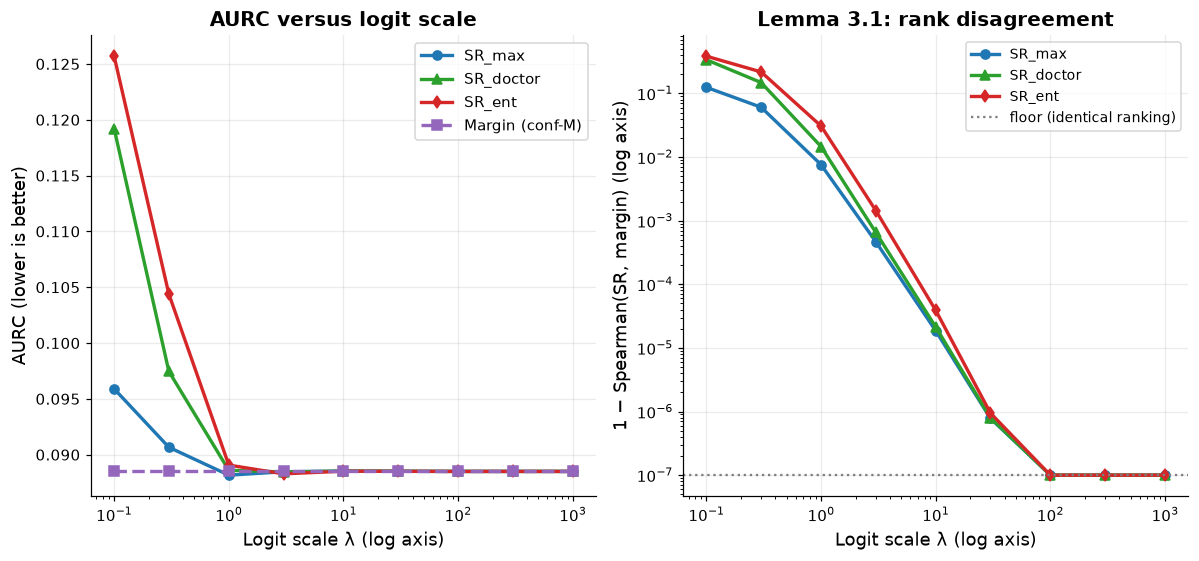

Smallest grid scale at which the SR ordering equals the margin ordering (None = not reached on the grid): {'SR_max': 100.0, 'SR_doctor': 100.0, 'SR_ent': 100.0}


In [28]:
# S4.5: AURC and rank disagreement versus logit scale (from S4.3-S4.4; K=4 toy, n=2000 test rows).
plt.figure(figsize=(11, 5.2))
plt.subplot(1, 2, 1)
plt.plot(s_lam_grid4, s_aurc_sr4["SR_max"], marker="o", label="SR_max", linewidth=2.2, color=PALETTE["clean"])
plt.plot(s_lam_grid4, s_aurc_sr4["SR_doctor"], marker="^", label="SR_doctor", linewidth=2.2, color=PALETTE["acoustic"])
plt.plot(s_lam_grid4, s_aurc_sr4["SR_ent"], marker="d", label="SR_ent", linewidth=2.2, color=PALETTE["shifted"])
plt.plot(s_lam_grid4, s_aurc_margin4, marker="s", label="Margin (conf-M)", linewidth=2.2, color=PALETTE["frozen"], linestyle="--")
plt.xscale("log")
plt.xlabel("Logit scale λ (log axis)", fontsize=12)
plt.ylabel("AURC (lower is better)", fontsize=12)
plt.title("AURC versus logit scale", fontsize=13, fontweight="bold")
plt.legend(fontsize=10)

plt.subplot(1, 2, 2)
s_floor4 = 1e-7
for name, marker, colour in [("SR_max", "o", "clean"), ("SR_doctor", "^", "acoustic"), ("SR_ent", "d", "shifted")]:
    plt.plot(s_lam_grid4, np.maximum(1 - np.array(s_rho4[name]), s_floor4), marker=marker, label=name, linewidth=2.2, color=PALETTE[colour])
plt.axhline(s_floor4, color=PALETTE["reference"], linestyle=":", linewidth=1.5, label="floor (identical ranking)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Logit scale λ (log axis)", fontsize=12)
plt.ylabel("1 − Spearman(SR, margin) (log axis)", fontsize=12)
plt.title("Lemma 3.1: rank disagreement", fontsize=13, fontweight="bold")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

s_first_floor4 = {name: next((float(l) for l, r in zip(s_lam_grid4, s_rho4[name]) if 1 - r <= s_floor4), None) for name in s_rho4}
print("Smallest grid scale at which the SR ordering equals the margin ordering (None = not reached on the grid):", s_first_floor4)

### How to read this chart

The figure has two panels that share the same logit-scale axis (logarithmic, from 0.1 to 1000), computed on one fixed classifier and one fixed test set.

**Left panel (AURC versus scale).** The y-axis is AURC, so lower is better. The three solid curves are the SR scores; the dashed line is the confidence margin, which is flat by construction because scaling the margin does not change its ordering. A solid curve that sits above the dashed line at some scale means that the SR score keeps errors out of the retained set less effectively than the margin at that scale; a curve below it means the reverse. Whether SR is above or below the margin at moderate scales is a property of this classifier and this draw, so read the printed table rather than assuming a sign. What must hold for every draw is that the SR curves are not identical across scales while the margin line is.

**Right panel (rank disagreement).** The y-axis is one minus the Spearman rank correlation between an SR score and the margin, on a logarithmic axis, so lower means closer agreement with the margin ordering. The dotted floor marks a point where the two orderings are identical on this test set (a value of exactly one minus one cannot be drawn on a log axis, so it is clipped to the floor). Lemma 3.1 predicts curves that fall toward the floor as the scale grows; a curve that rose at large scale would contradict it.

**Takeaway.** SR scores rank examples differently at different logit scales, so an SR-based RC curve depends on how the logits happen to be scaled, for instance by temperature scaling or training length. The margin does not. At sufficiently large scale the SR orderings collapse onto the margin ordering, so the two families differ only at the moderate scales that trained networks typically occupy. That last sentence is a statement about this toy; the paper's evidence for real networks is in its experiments (L pp.10-14).

### Temperature scaling as a global rescale (derived here)

Dividing all logits by a fitted temperature $T$ is the same operation as multiplying them by $\lambda = 1/T$. It therefore leaves the predicted class unchanged and leaves the margin ordering unchanged, but it can change every SR ordering. The paper cites Zhu et al. (2022) as reporting that recent calibration methods may degrade selective-classification performance (L p.4); that is a cited claim, and this toy does not test it. What the toy can test is the mechanism: a calibration step that is harmless for accuracy can still move the RC curve of an SR score.

The temperature is fitted on a **separate calibration set** by minimizing negative log-likelihood, using the project's `temperature_scale`. For the fit to mean anything the training data must not be separable: with a separable classifier the likelihood keeps improving as $T \to 0$, and the fitted $T$ is an artefact of the optimizer's bounds. The toy in S4.1 has overlapping classes for that reason, and the first check below asserts that the fitted $T$ is neither $1$ nor at a boundary.

The paired bootstrap used below resamples **rows** of the test set once per replicate and recomputes both AURCs on the same resample, so the interval for a difference of AURCs reflects the shared rows rather than treating the two scores as independent.

In [29]:
# S4.6: Temperature fit on the calibration set, applied to the test set; paired bootstrap of AURC differences (B=400, seed RNG_SEED+406).
from src.metrics import nll

def s_softmax4(z):
    a = z - z.max(axis=1, keepdims=True)
    p = np.exp(a)
    return p / p.sum(axis=1, keepdims=True)

def s_aurc_of(score, correct):
    return aurc(*risk_coverage_curve(score, correct))

def s_paired_boot(score_a, score_b, correct, B=400, seed=0):
    # Bootstrap rows jointly; returns (point, lower, upper) for AURC(score_a) - AURC(score_b) on the same resample.
    rng = np.random.default_rng(seed)
    n = len(correct)
    diffs = np.empty(B)
    for b in range(B):
        idx = rng.integers(0, n, n)
        diffs[b] = s_aurc_of(score_a[idx], correct[idx]) - s_aurc_of(score_b[idx], correct[idx])
    lo, hi = np.quantile(diffs, [0.025, 0.975])
    return s_aurc_of(score_a, correct) - s_aurc_of(score_b, correct), float(lo), float(hi)

s_T4 = temperature_scale(s_zca4, s_yca4)
s_nll_1 = nll(s_softmax4(s_zte4), s_yte4)
s_nll_T = nll(s_softmax4(s_zte4 / s_T4), s_yte4)
check("S4.6a", 1.05 < s_T4 < 20.0 and s_nll_T < s_nll_1,
      f"fitted T={s_T4:.3f} is interior (not 1, not at the search bounds) and held-out test NLL improves {s_nll_1:.4f} -> {s_nll_T:.4f}")

s_zte4_T = s_zte4 / s_T4
s_margin_T = s_gaps4(s_zte4_T)[:, 0]
s_pred_same = np.array_equal(np.argmax(s_zte4, axis=1), np.argmax(s_zte4_T, axis=1))
s_risk_m1 = risk_coverage_curve(s_margin4, s_correct4)[1]
s_risk_mT = risk_coverage_curve(s_margin_T, s_correct4)[1]
s_margin_T_dev = float(np.max(np.abs(s_risk_m1 - s_risk_mT)))
check("S4.6b", s_pred_same and s_margin_T_dev < 1e-12,
      f"predictions identical for every test row: {s_pred_same}; margin RC curve before/after T differs by {s_margin_T_dev:.1e} (< 1e-12)")

s_srmax_1 = -s_log_keys4(s_zte4, 1.0)["SR_max"]
s_srmax_T = -s_log_keys4(s_zte4, 1.0 / s_T4)["SR_max"]
s_rho_T = float(spearmanr(s_srmax_1, s_srmax_T)[0])
s_risk_s1 = risk_coverage_curve(s_srmax_1, s_correct4)[1]
s_risk_sT = risk_coverage_curve(s_srmax_T, s_correct4)[1]
s_srT_dev = float(np.max(np.abs(s_risk_s1 - s_risk_sT)))
check("S4.7", s_rho_T < 1 - 1e-9 and s_srT_dev > 0.0,
      f"SR_max ordering changes under T: Spearman(before, after) = {s_rho_T:.6f}; max |risk diff| along the RC curve = {s_srT_dev:.4f}")

s_d1 = s_paired_boot(s_srmax_T, s_srmax_1, s_correct4, seed=RNG_SEED + 406)
s_d2 = s_paired_boot(s_margin4, s_srmax_T, s_correct4, seed=RNG_SEED + 407)
note("S4.8a", f"AURC(SR_max after T) - AURC(SR_max before): {s_d1[0]:+.4f}, paired-bootstrap 95% CI [{s_d1[1]:+.4f}, {s_d1[2]:+.4f}]"
     + (" (CI excludes 0)" if s_d1[1] > 0 or s_d1[2] < 0 else " (CI contains 0: no detectable AURC change on this toy)"))
note("S4.8b", f"AURC(margin) - AURC(SR_max after T): {s_d2[0]:+.4f}, paired-bootstrap 95% CI [{s_d2[1]:+.4f}, {s_d2[2]:+.4f}]"
     + (" (CI excludes 0)" if s_d2[1] > 0 or s_d2[2] < 0 else " (CI contains 0)"))

[S4.6a] fitted T=1.500 is interior (not 1, not at the search bounds) and held-out test NLL improves 0.6233 -> 0.5875 -> PASS
[S4.6b] predictions identical for every test row: True; margin RC curve before/after T differs by 0.0e+00 (< 1e-12) -> PASS
[S4.7] SR_max ordering changes under T: Spearman(before, after) = 0.997209; max |risk diff| along the RC curve = 0.0077 -> PASS


[S4.8a] AURC(SR_max after T) - AURC(SR_max before): +0.0002, paired-bootstrap 95% CI [-0.0005, +0.0008] (CI contains 0: no detectable AURC change on this toy) -> NOTE
[S4.8b] AURC(margin) - AURC(SR_max after T): +0.0001, paired-bootstrap 95% CI [-0.0015, +0.0018] (CI contains 0) -> NOTE


## 4b. Selection under covariate shift and novel-class inputs (derived here; the paper's own experiments are vision and text, L)

The paper distinguishes three kinds of prediction error (L p.2): **Type A** errors on in-distribution inputs, **Type B** errors on inputs whose label is *not in the classifier's label set* (a novel label, so the prediction is always wrong), and **Type C** errors on covariate-shifted inputs that keep the same label set. Its generalization of selective classification to shifted data, Eq. (8), re-defines coverage and selection risk under the shifted distribution $D'$ and assumes that no outliers are present (L p.4). Our toy makes the same three types concrete and then goes one step beyond the paper's formal setting by also pooling Type B rows into the RC curve, to see what an outlier does to each score.

**Paraphrase of Liang et al. Eq. (8); L p.4.** Under $D'$ the coverage is $\varphi' = \mathbb{E}_{D'}[g(x)]$ and the selection risk is $R' = \mathbb{E}_{D'}[\ell(f(x), y)\, g(x)] / \varphi'$, with the assumption that $D'$ contains no outliers.

The paper reports (L pp.12-14) that margin scores are best or comparable to SR scores, that OOD-detection scores (it lists RL_max, Energy, KNN and ViM) perform poorly for selective classification, and that on iWildCam (images) and Amazon (text) the margin scores are only on par with SR scores. We test a narrow version of that comparison on a toy with $K = 3$ known classes, using only the two OOD-style scores that can be computed from logits alone: **RL_max** (the largest logit) and **Energy** ($\log \sum_k e^{z_k}$, larger meaning more in-distribution). KNN and ViM need training features and are **not run**, so nothing below says anything about them.

### Toy data-generating process

Three known classes sit at the corners of an equilateral triangle of circumradius 2 in the plane. A multinomial logistic regression is fit on 300 in-distribution rows. Test rows are then drawn independently of the training rows:

1. **Type A:** same distribution as training (isotropic noise with standard deviation 1).
2. **Type C:** same class centres and label set, but the noise standard deviation is inflated to 1.8.
3. **Type B:** two novel clusters with labels 3 and 4, which the classifier has never seen: one at the origin (all three classes equally near) and one on the boundary between two known classes.

By construction every Type B prediction is wrong, so the risk of any selector on Type B rows alone is 1 at every coverage. That case carries no information about the ranking; it only pins down the arithmetic of the AURC integral.

In [30]:
# S4b.1: K=3 toy with Type A (in-dist), Type C (noise x1.8) and Type B (novel labels 3, 4). n_train=300, A=900, C=900, B=600. Seed RNG_SEED+410.
from sklearn.metrics import roc_auc_score
s_rng4b = np.random.default_rng(RNG_SEED + 410)
s_ang4b = np.array([0.0, 2 * np.pi / 3, 4 * np.pi / 3])
s_cen4b = 2.0 * np.column_stack([np.cos(s_ang4b), np.sin(s_ang4b)])

def s_known4b(n, sd):
    y = s_rng4b.integers(0, 3, n)
    return s_cen4b[y] + sd * s_rng4b.standard_normal((n, 2)), y

s_Xtr4b, s_ytr4b = s_known4b(300, 1.0)
s_XA, s_yA = s_known4b(900, 1.0)
s_XC, s_yC = s_known4b(900, 1.8)
s_nov_centres = np.array([[0.0, 0.0], [1.5, 2.6]])
s_yB = s_rng4b.integers(3, 5, 600)
s_XB = s_nov_centres[s_yB - 3] + 0.8 * s_rng4b.standard_normal((600, 2))

s_clf4b = LogisticRegression(C=1.0, max_iter=5000).fit(s_Xtr4b, s_ytr4b)
s_Z4b = {k: s_clf4b.decision_function(X) for k, X in [("A", s_XA), ("C", s_XC), ("B", s_XB)]}
s_pred4b = {k: s_clf4b.predict(X) for k, X in [("A", s_XA), ("C", s_XC), ("B", s_XB)]}
s_y4b = {"A": s_yA, "C": s_yC, "B": s_yB}
s_cor4b = {k: s_pred4b[k] == s_y4b[k] for k in s_Z4b}

check("S4b.1a", set(np.unique(s_yB)) == {3, 4} and not set(np.unique(s_ytr4b)) & {3, 4} and list(s_clf4b.classes_) == [0, 1, 2],
      f"Type B labels {sorted(int(v) for v in np.unique(s_yB))} are absent from the training labels {[int(v) for v in s_clf4b.classes_]}")
check("S4b.1b", not s_cor4b["B"].any(),
      f"every Type B prediction is wrong (novel label): error rate {1 - s_cor4b['B'].mean():.3f}")
print(f"Type A error {1 - s_cor4b['A'].mean():.3f}, Type C error {1 - s_cor4b['C'].mean():.3f}, Type B error {1 - s_cor4b['B'].mean():.3f}")
print(f"Rows: A={len(s_yA)}, C={len(s_yC)}, B={len(s_yB)}; training rows are independent draws, so no test row was used for fitting.")

[S4b.1a] Type B labels [3, 4] are absent from the training labels [0, 1, 2] -> PASS
[S4b.1b] every Type B prediction is wrong (novel label): error rate 1.000 -> PASS
Type A error 0.077, Type C error 0.262, Type B error 1.000
Rows: A=900, C=900, B=600; training rows are independent draws, so no test row was used for fitting.


In [31]:
# S4b.2: Scores computed from logits. SR_max, SR_doctor, SR_ent (Eq. 7), conf-M margin, RL_max, Energy.
def s_scores4b(z):
    zs = -np.sort(-z, axis=1)
    p = s_softmax4(z)
    return {"SR_max": p.max(axis=1), "SR_doctor": 1.0 - 1.0 / (p ** 2).sum(axis=1), "SR_ent": (p * np.log(np.clip(p, 1e-300, 1))).sum(axis=1),
            "margin": zs[:, 0] - zs[:, 1], "RL_max": zs[:, 0], "Energy": logsumexp(z, axis=1)}

s_S4b = {k: s_scores4b(Z) for k, Z in s_Z4b.items()}
s_names4b = list(s_S4b["A"].keys())

# Regime-by-regime AURC for two scores (SR_max and margin).
s_reg_aurc = {}
for s_k in ["A", "C", "B"]:
    for s_nm in ["SR_max", "margin"]:
        s_reg_aurc[(s_k, s_nm)] = s_aurc_of(s_S4b[s_k][s_nm], s_cor4b[s_k])

print("AURC by regime (rows of one type only):")
for s_k, s_lab in [("A", "Type A"), ("C", "Type C"), ("B", "Type B")]:
    print(f"  {s_lab}: SR_max {s_reg_aurc[(s_k, 'SR_max')]:.4f}   margin {s_reg_aurc[(s_k, 'margin')]:.4f}   base error {1 - s_cor4b[s_k].mean():.4f}")

s_nB = len(s_yB)
check("S4b.2a", all(abs(s_reg_aurc[("B", nm)] - (1 - 1 / s_nB)) < 1e-12 for nm in ["SR_max", "margin"]),
      f"Type B AURC = 1 - 1/n = {1 - 1 / s_nB:.6f} exactly for both scores: risk is 1 at every coverage and the trapezoid starts at coverage 1/n")
check("S4b.2b", all(s_reg_aurc[("C", nm)] > s_reg_aurc[("A", nm)] for nm in ["SR_max", "margin"]),
      f"covariate shift raises AURC for both scores: A {s_reg_aurc[('A', 'SR_max')]:.4f} -> C {s_reg_aurc[('C', 'SR_max')]:.4f} (SR_max), "
      f"A {s_reg_aurc[('A', 'margin')]:.4f} -> C {s_reg_aurc[('C', 'margin')]:.4f} (margin)")

AURC by regime (rows of one type only):
  Type A: SR_max 0.0114   margin 0.0118   base error 0.0767
  Type C: SR_max 0.1203   margin 0.1211   base error 0.2622
  Type B: SR_max 0.9983   margin 0.9983   base error 1.0000
[S4b.2a] Type B AURC = 1 - 1/n = 0.998333 exactly for both scores: risk is 1 at every coverage and the trapezoid starts at coverage 1/n -> PASS
[S4b.2b] covariate shift raises AURC for both scores: A 0.0114 -> C 0.1203 (SR_max), A 0.0118 -> C 0.1211 (margin) -> PASS


True

In [32]:
# S4b.3: OOD detection (known A+C vs novel B) and selective classification on known rows, for six logit-based scores.
# Paired bootstrap B=400 on the known rows (n=1800), seeds RNG_SEED+430..432.
s_zk = np.vstack([s_Z4b["A"], s_Z4b["C"]])
s_ck = np.hstack([s_cor4b["A"], s_cor4b["C"]])
s_Sk = s_scores4b(s_zk)
s_Sb = s_S4b["B"]
s_n1, s_n2 = len(s_ck), len(s_yB)

def s_hanley_se(auc, n1, n2):
    q1, q2 = auc / (2 - auc), 2 * auc ** 2 / (1 + auc)
    return float(np.sqrt((auc * (1 - auc) + (n1 - 1) * (q1 - auc ** 2) + (n2 - 1) * (q2 - auc ** 2)) / (n1 * n2)))

s_tab4b = {}
print(f"{'score':10s} {'AUROC(ID vs novel)':>19s} {'AURC known-only':>16s} {'AURC pooled A+C+B':>18s}")
for s_nm in s_names4b:
    s_auc = roc_auc_score(np.r_[np.ones(s_n1), np.zeros(s_n2)], np.r_[s_Sk[s_nm], s_Sb[s_nm]])
    s_ak = s_aurc_of(s_Sk[s_nm], s_ck)
    s_ap = s_aurc_of(np.r_[s_Sk[s_nm], s_Sb[s_nm]], np.r_[s_ck, s_cor4b["B"]])
    s_tab4b[s_nm] = (s_auc, s_ak, s_ap)
    print(f"{s_nm:10s} {s_auc:19.3f} {s_ak:16.4f} {s_ap:18.4f}")

check("S4b.3a", all(v[0] - 0.5 > 3 * s_hanley_se(v[0], s_n1, s_n2) for v in s_tab4b.values()),
      "every score detects the novel rows above chance by > 3 Hanley-McNeil SE (AUROC min "
      f"{min(v[0] for v in s_tab4b.values()):.3f}, SE about {s_hanley_se(min(v[0] for v in s_tab4b.values()), s_n1, s_n2):.3f})")

s_b_energy = s_paired_boot(s_Sk["margin"], s_Sk["Energy"], s_ck, seed=RNG_SEED + 430)
s_b_rlmax = s_paired_boot(s_Sk["margin"], s_Sk["RL_max"], s_ck, seed=RNG_SEED + 431)
s_b_srmax = s_paired_boot(s_Sk["margin"], s_Sk["SR_max"], s_ck, seed=RNG_SEED + 432)
check("S4b.3b", s_b_energy[2] < 0,
      f"known-only AURC(margin) - AURC(Energy) = {s_b_energy[0]:+.4f}, paired 95% CI [{s_b_energy[1]:+.4f}, {s_b_energy[2]:+.4f}] (upper bound < 0)")
check("S4b.3c", s_b_rlmax[2] < 0,
      f"known-only AURC(margin) - AURC(RL_max) = {s_b_rlmax[0]:+.4f}, paired 95% CI [{s_b_rlmax[1]:+.4f}, {s_b_rlmax[2]:+.4f}] (upper bound < 0)")
note("S4b.3d", f"known-only AURC(margin) - AURC(SR_max) = {s_b_srmax[0]:+.4f}, paired 95% CI [{s_b_srmax[1]:+.4f}, {s_b_srmax[2]:+.4f}]"
     + (" (CI excludes 0)" if s_b_srmax[1] > 0 or s_b_srmax[2] < 0 else " (CI contains 0: margin and SR_max are not separable on this toy)"))

s_auc_vec = np.array([s_tab4b[n][0] for n in s_names4b])
s_aurc_vec = np.array([s_tab4b[n][1] for n in s_names4b])
s_rank_corr = float(spearmanr(s_auc_vec, -s_aurc_vec)[0])
note("S4b.3e", f"across the six scores, Spearman(AUROC for novel detection, -AURC on known rows) = {s_rank_corr:+.3f}; "
     f"best novelty detector: {s_names4b[int(np.argmax(s_auc_vec))]}, best selective classifier on known rows: {s_names4b[int(np.argmin(s_aurc_vec))]}")

score       AUROC(ID vs novel)  AURC known-only  AURC pooled A+C+B
SR_max                   0.781           0.0678             0.1665
SR_doctor                0.782           0.0677             0.1663
SR_ent                   0.781           0.0677             0.1666


margin                   0.779           0.0677             0.1665
RL_max                   0.719           0.0780             0.1979
Energy                   0.710           0.0798             0.2026
[S4b.3a] every score detects the novel rows above chance by > 3 Hanley-McNeil SE (AUROC min 0.710, SE about 0.011) -> PASS


[S4b.3b] known-only AURC(margin) - AURC(Energy) = -0.0121, paired 95% CI [-0.0187, -0.0060] (upper bound < 0) -> PASS
[S4b.3c] known-only AURC(margin) - AURC(RL_max) = -0.0104, paired 95% CI [-0.0163, -0.0055] (upper bound < 0) -> PASS
[S4b.3d] known-only AURC(margin) - AURC(SR_max) = -0.0001, paired 95% CI [-0.0007, +0.0005] (CI contains 0: margin and SR_max are not separable on this toy) -> NOTE
[S4b.3e] across the six scores, Spearman(AUROC for novel detection, -AURC on known rows) = +0.486; best novelty detector: SR_doctor, best selective classifier on known rows: margin -> NOTE


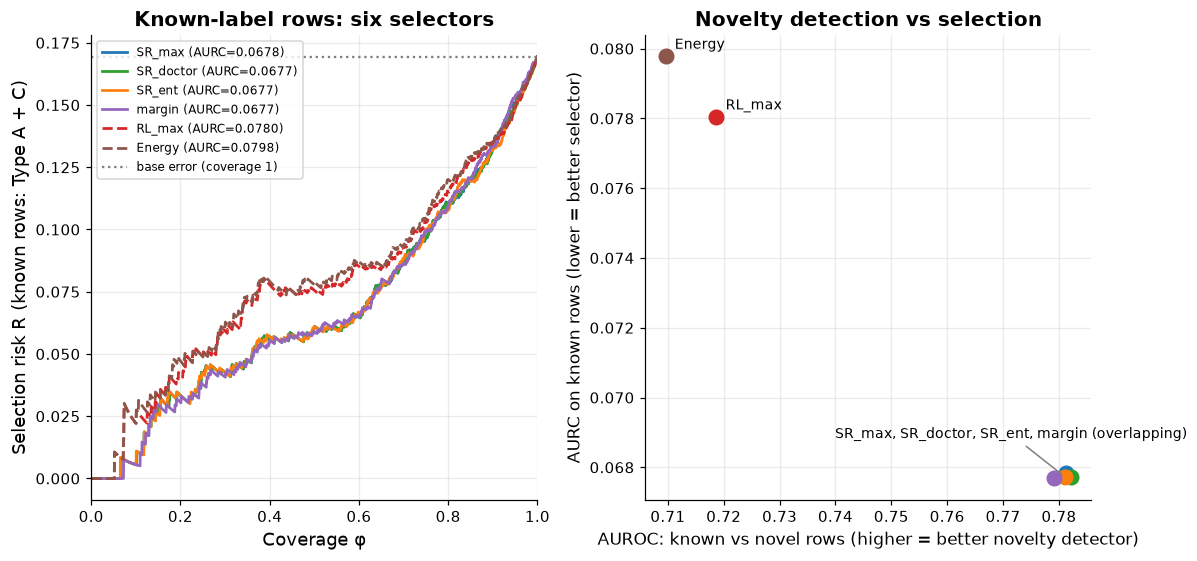

Best pooled-AURC score when Type B rows are mixed in: SR_doctor; best on known rows only: margin.


In [33]:
# S4b.4: Left: known-only RC curves for the six scores. Right: novelty-detection AUROC against known-only AURC (from S4b.3).
s_colours4b = dict(zip(s_names4b, ["clean", "acoustic", "mask", "frozen", "shifted", "adapted"]))
plt.figure(figsize=(11, 5.2))
plt.subplot(1, 2, 1)
for s_nm in s_names4b:
    s_cov, s_risk = risk_coverage_curve(s_Sk[s_nm], s_ck)
    plt.plot(s_cov, s_risk, label=f"{s_nm} (AURC={s_tab4b[s_nm][1]:.4f})", color=PALETTE[s_colours4b[s_nm]], linewidth=1.8,
             linestyle="--" if s_nm in ("RL_max", "Energy") else "-")
plt.axhline(1 - s_ck.mean(), color=PALETTE["reference"], linestyle=":", linewidth=1.5, label="base error (coverage 1)")
plt.xlabel("Coverage φ", fontsize=12)
plt.ylabel("Selection risk R (known rows: Type A + C)", fontsize=12)
plt.title("Known-label rows: six selectors", fontsize=13, fontweight="bold")
plt.legend(fontsize=8, loc="upper left")
plt.xlim(0, 1)

plt.subplot(1, 2, 2)
for s_nm in s_names4b:
    plt.scatter(s_tab4b[s_nm][0], s_tab4b[s_nm][1], s=90, color=PALETTE[s_colours4b[s_nm]], zorder=3)
    if s_nm in ("RL_max", "Energy"):
        plt.annotate(s_nm, (s_tab4b[s_nm][0], s_tab4b[s_nm][1]), textcoords="offset points", xytext=(6, 5), fontsize=9)
s_grp = ["SR_max", "SR_doctor", "SR_ent", "margin"]
plt.annotate("SR_max, SR_doctor, SR_ent, margin (overlapping)", (np.mean([s_tab4b[n][0] for n in s_grp]), np.mean([s_tab4b[n][1] for n in s_grp])),
             textcoords="offset points", xytext=(-150, 25), fontsize=9, arrowprops={"arrowstyle": "-", "color": PALETTE["reference"]})
plt.xlabel("AUROC: known vs novel rows (higher = better novelty detector)", fontsize=11)
plt.ylabel("AURC on known rows (lower = better selector)", fontsize=11)
plt.title("Novelty detection vs selection", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

s_pooled_best = s_names4b[int(np.argmin([s_tab4b[n][2] for n in s_names4b]))]
print(f"Best pooled-AURC score when Type B rows are mixed in: {s_pooled_best}; best on known rows only: {s_names4b[int(np.argmin(s_aurc_vec))]}.")

### How to read this chart

Both panels use only the two kinds of rows that share the classifier's label set (Type A and Type C pooled), which is the setting of Eq. (8) in the paper, except in the right panel where the novelty-detection axis uses the Type B rows as well.

**Left panel (RC curves).** The x-axis is coverage and the y-axis is the error rate among retained rows. Each line is one score; the SR family and the margin are solid, and the two OOD-style scores (RL_max and Energy) are dashed. The dotted horizontal line is the error rate at full coverage, where every selector must end. A line that stays lower at a given coverage keeps more errors out of the retained set; lines that nearly overlap are scores that rank the rows almost identically; the printed AURCs and the paired intervals say whether any visible gap is larger than resampling noise.

**Right panel (novelty detection versus selection).** Each point is one score. The x-axis measures how well the score separates known rows from novel rows (further right is better at spotting novelty); the y-axis is the AURC on known rows (lower is a better selective classifier). If good novelty detectors were poor selectors, the points would slope upward to the right. If the two abilities go together, they slope downward.

**Takeaway.** The printed checks decide what this toy supports, not the eye. The paired-bootstrap intervals on AURC differences are the evidence about RL_max and Energy versus the margin; the printed rank correlation summarizes the right panel. Anything the paper says about KNN and ViM is untouched by this toy because those scores were not computed. A toy in the plane with a linear classifier is far from the deep vision and text models of the paper's experiments (L pp.10-14), so agreement or disagreement here is weak evidence either way.

In [34]:
# S4b.5: Extension beyond Eq. (8): pool Type B rows with the known rows. What share of the retained rows is novel at coverage 0.5?
# Pooled set: 1800 known + 600 novel rows; random selection would retain a novel share of 600/2400. Paired bootstrap B=400, seeds RNG_SEED+440..441.
s_c_pool = np.r_[s_ck, s_cor4b["B"]]
s_is_novel = np.r_[np.zeros(s_n1, dtype=bool), np.ones(s_n2, dtype=bool)]
s_share0 = s_n2 / (s_n1 + s_n2)
s_k_half = (s_n1 + s_n2) // 2
s_share = {}
for s_nm in s_names4b:
    s_pool_score = np.r_[s_Sk[s_nm], s_Sb[s_nm]]
    s_top = np.argsort(-s_pool_score, kind="stable")[:s_k_half]
    s_share[s_nm] = float(np.mean(s_is_novel[s_top]))
s_se_share = float(np.sqrt(s_share0 * (1 - s_share0) / s_k_half))

print(f"Share of retained rows that are Type B at coverage 0.5 (random selection: {s_share0:.3f}, binomial SE {s_se_share:.3f}):")
for s_nm in s_names4b:
    print(f"  {s_nm:10s} {s_share[s_nm]:.3f}")

check("S4b.5a", all(v < s_share0 - 3 * s_se_share for v in s_share.values()),
      f"every score retains fewer novel rows than random selection by more than 3 SE (largest share {max(s_share.values()):.3f} < {s_share0 - 3 * s_se_share:.3f})")

s_pool = {nm: np.r_[s_Sk[nm], s_Sb[nm]] for nm in s_names4b}
s_p_energy = s_paired_boot(s_pool["margin"], s_pool["Energy"], s_c_pool, seed=RNG_SEED + 440)
s_p_srmax = s_paired_boot(s_pool["margin"], s_pool["SR_max"], s_c_pool, seed=RNG_SEED + 441)
check("S4b.5b", s_p_energy[2] < 0,
      f"pooled AURC(margin) - AURC(Energy) = {s_p_energy[0]:+.4f}, paired 95% CI [{s_p_energy[1]:+.4f}, {s_p_energy[2]:+.4f}] (upper bound < 0)")
note("S4b.5c", f"pooled AURC(margin) - AURC(SR_max) = {s_p_srmax[0]:+.4f}, paired 95% CI [{s_p_srmax[1]:+.4f}, {s_p_srmax[2]:+.4f}]"
     + (" (CI excludes 0)" if s_p_srmax[1] > 0 or s_p_srmax[2] < 0 else " (CI contains 0)"))

Share of retained rows that are Type B at coverage 0.5 (random selection: 0.250, binomial SE 0.013):
  SR_max     0.088
  SR_doctor  0.089
  SR_ent     0.090
  margin     0.087
  RL_max     0.139
  Energy     0.147
[S4b.5a] every score retains fewer novel rows than random selection by more than 3 SE (largest share 0.147 < 0.212) -> PASS


[S4b.5b] pooled AURC(margin) - AURC(Energy) = -0.0361, paired 95% CI [-0.0435, -0.0288] (upper bound < 0) -> PASS
[S4b.5c] pooled AURC(margin) - AURC(SR_max) = +0.0000, paired 95% CI [-0.0007, +0.0007] (CI contains 0) -> NOTE


In [35]:
# S4b.6: Does covariate shift degrade selection? Unpaired bootstrap (B=400) of AURC(Type C) - AURC(Type A) per score, seed RNG_SEED+501.
def s_unpaired_boot(score_a, cor_a, score_b, cor_b, B=400, seed=0):
    rng = np.random.default_rng(seed)
    diffs = np.empty(B)
    for b in range(B):
        ia = rng.integers(0, len(cor_a), len(cor_a))
        ib = rng.integers(0, len(cor_b), len(cor_b))
        diffs[b] = s_aurc_of(score_a[ia], cor_a[ia]) - s_aurc_of(score_b[ib], cor_b[ib])
    lo, hi = np.quantile(diffs, [0.025, 0.975])
    return s_aurc_of(score_a, cor_a) - s_aurc_of(score_b, cor_b), float(lo), float(hi)

s_shift_ci = {}
for s_i, s_nm in enumerate(["SR_max", "margin"]):
    s_shift_ci[s_nm] = s_unpaired_boot(s_S4b["C"][s_nm], s_cor4b["C"], s_S4b["A"][s_nm], s_cor4b["A"], seed=RNG_SEED + 501 + s_i)
    print(f"AURC(C) - AURC(A) for {s_nm}: {s_shift_ci[s_nm][0]:+.4f}, 95% CI [{s_shift_ci[s_nm][1]:+.4f}, {s_shift_ci[s_nm][2]:+.4f}]")

s_err_a = np.r_[(~s_cor4b["A"]).astype(float)]
s_err_c = np.r_[(~s_cor4b["C"]).astype(float)]
s_rng_err = np.random.default_rng(RNG_SEED + 503)
s_err_diff = np.array([np.mean(s_err_c[s_rng_err.integers(0, len(s_err_c), len(s_err_c))]) - np.mean(s_err_a[s_rng_err.integers(0, len(s_err_a), len(s_err_a))]) for _ in range(1000)])
s_err_lo, s_err_hi = np.quantile(s_err_diff, [0.025, 0.975])
print(f"Error rate (C) - (A): {s_err_c.mean() - s_err_a.mean():+.4f}, 95% CI [{s_err_lo:+.4f}, {s_err_hi:+.4f}]")

check("S4b.6a", s_err_lo > 0, f"covariate shift raises the error rate: CI lower bound {s_err_lo:+.4f} > 0")
check("S4b.6b", all(v[1] > 0 for v in s_shift_ci.values()),
      "covariate shift raises AURC for both scores: lower CI bounds " + ", ".join(f"{k} {v[1]:+.4f}" for k, v in s_shift_ci.items()) + " (> 0)")

AURC(C) - AURC(A) for SR_max: +0.1089, 95% CI [+0.0863, +0.1320]


AURC(C) - AURC(A) for margin: +0.1093, 95% CI [+0.0907, +0.1299]
Error rate (C) - (A): +0.1856, 95% CI [+0.1522, +0.2156]
[S4b.6a] covariate shift raises the error rate: CI lower bound +0.1522 > 0 -> PASS
[S4b.6b] covariate shift raises AURC for both scores: lower CI bounds SR_max +0.0863, margin +0.0907 (> 0) -> PASS


True

In [36]:
# S4b.7: Operating point view (Eq. 3 read backwards): largest coverage whose selection risk is at most 10% on the known rows (Type A + C).
s_target_risk = 0.10
s_cov_at_target = {}
for s_nm in s_names4b:
    s_cov, s_risk = risk_coverage_curve(s_Sk[s_nm], s_ck)
    s_ok_idx = np.where(s_risk <= s_target_risk)[0]
    s_cov_at_target[s_nm] = float(s_cov[s_ok_idx[-1]]) if len(s_ok_idx) else 0.0
print(f"Largest coverage with selection risk <= {s_target_risk:.2f} on known rows (base error {1 - s_ck.mean():.3f}):")
for s_nm in s_names4b:
    print(f"  {s_nm:10s} coverage {s_cov_at_target[s_nm]:.3f}")
check("S4b.7", all(v > 0 for v in s_cov_at_target.values()) and max(s_cov_at_target.values()) < 1.0,
      "every score reaches the risk target at a positive coverage, and none reaches it at full coverage (target below the base error)")
note("S4b.7n", "this is an in-sample operating point on the test rows themselves; choosing a threshold on separate calibration rows is the "
     "calibration-set question the paper leaves open (L p.6), and is not attempted here")

Largest coverage with selection risk <= 0.10 on known rows (base error 0.169):
  SR_max     coverage 0.758
  SR_doctor  coverage 0.758
  SR_ent     coverage 0.756
  margin     coverage 0.763
  RL_max     coverage 0.741
  Energy     coverage 0.722
[S4b.7] every score reaches the risk target at a positive coverage, and none reaches it at full coverage (target below the base error) -> PASS
[S4b.7n] this is an in-sample operating point on the test rows themselves; choosing a threshold on separate calibration rows is the calibration-set question the paper leaves open (L p.6), and is not attempted here -> NOTE


## Conclusion: what the paper leaves open (source: Liang et al., TMLR 2024; L)

**Paraphrase of Liang et al. Sec. 2.5; L p.6.** The paper states that it does not treat how the calibration set is constructed or how the threshold $\gamma$ is chosen, and instead evaluates the scores directly on test sets.

This notebook covered selective classification as a framework (Eqs. 1-3 and 8), the RC curve and its AURC summary, the scale sensitivity of SR scores against the scale invariance of margin scores, and a small toy comparison under covariate shift and novel labels. Every numeric statement about the toys comes from the printed output of the checks above, not from this text.

The paper's own evidence is in its experiments on ImageNet-based benchmarks, iWildCam (images), Amazon (text) and CIFAR (L pp.10-14). None of it is on audio. What remains open for a speech-commands study:

1. **Calibration-set construction.** Algorithm 1 (L p.4) picks $\gamma$ from a small i.i.d. calibration set, and the paper leaves the construction of that set outside its scope. For speech this includes how many utterances are needed, whether the set should include shifted conditions, and whether it should be drawn per speaker or globally. These are open design questions, not results.
2. **Threshold selection under shift.** A threshold chosen for a coverage or risk target on clean calibration data need not deliver that target on shifted test data. Nothing in the material read for this study establishes how far coverage or risk drift; that must be measured on speech data.
3. **Audio evidence.** The transfer of the paper's finding that margin scores are competitive with, or better than, SR scores to acoustic shift is a hypothesis of this study. The toy above is consistent with the paper's direction for the two OOD-style scores that were run, on data with no relation to speech.
4. **Guarantees.** The extract of the paper used here records definitions, an evaluation protocol and empirical comparisons; it records no coverage guarantee and no finite-sample bound. Whether the appendices contain one was not checked, so no statement about guarantees is made either way.
5. **Novel-label inputs.** Eq. (8) assumes no outliers, so Type B inputs sit outside the formal setting. The toy pooled them anyway; the printed pooled AURCs show how the ranking of scores behaves in that extension, which is a derived-here observation and not a claim about the paper.

**Next steps for this study:** compute the confidence-margin score and the SR scores from the speech-command model's logits under each acoustic shift, compare their AURC with a paired bootstrap on shared utterances as done above, and treat threshold selection as its own experiment.

In [37]:
# S5.1: Summary of checks run in this part.
check_summary()

print("=" * 70)
print("Part 2 complete: selective classification and scale sensitivity")
print("=" * 70)
print("Sections: 3 (RC curve, AURC, oracle closed form), 4 (SR vs margin, Lemma 3.1 grid, temperature), 4b (Types A/B/C, six scores)")
print("Figures: RC curves for random/imperfect/oracle scores; AURC and rank disagreement versus scale; six selectors and novelty detection")
print(f"Toy 4 test set: n={len(s_correct4)}, error {np.mean(~s_correct4):.3f}, fitted T={s_T4:.3f}")
print(f"Toy 4b known-only AURC, best score: {s_names4b[int(np.argmin(s_aurc_vec))]}; best novelty detector: {s_names4b[int(np.argmax(s_auc_vec))]}")
print("=" * 70)

63 labelled lines; 56 PASS, 7 NOTE, 0 FAIL []
Part 2 complete: selective classification and scale sensitivity
Sections: 3 (RC curve, AURC, oracle closed form), 4 (SR vs margin, Lemma 3.1 grid, temperature), 4b (Types A/B/C, six scores)
Figures: RC curves for random/imperfect/oracle scores; AURC and rank disagreement versus scale; six selectors and novelty detection
Toy 4 test set: n=2000, error 0.230, fitted T=1.500
Toy 4b known-only AURC, best score: margin; best novelty detector: SR_doctor


## 5. Conformal risk control: setup, estimator and guarantee (source: Angelopoulos et al., arXiv:2208.02814; q2, q3)

This section states the guarantee, derives the estimator, and proves the guarantee with an argument that survives inspection. Paper claims and toy results are kept in separate paragraphs. Every number that comes from a run appears only in a code printout.

**Setup (q2).** A base model $f$ is post-processed into $C_\lambda(x)$ with a scalar $\lambda\in\Lambda$ that encodes conservativeness: larger $\lambda$ gives larger, more conservative outputs such as bigger prediction sets. The per-sample loss is $L_i(\lambda)=\ell(C_\lambda(X_i),Y_i)$ and the $n+1$ losses $L_1,\dots,L_{n+1}$ (calibration points plus one test point) are exchangeable random functions of $\lambda$.

**Assumptions (q2).** (1) exchangeability of the $n+1$ loss functions; (2) each $L_i$ is non-increasing in $\lambda$; (3) each $L_i$ is right-continuous; (4) $\sup_\lambda L_i(\lambda)\le B<\infty$ almost surely; (5) $L_i(\lambda_{\max})\le\alpha$ almost surely, so the target is reachable at the most conservative setting.

**Estimator (q2, q3; Equation 4, Section 1.1).** With $\hat R_n(\lambda)=\frac1n\sum_{i\le n}L_i(\lambda)$,
$$\hat\lambda=\inf\Big\{\lambda:\ \tfrac{n}{n+1}\hat R_n(\lambda)+\tfrac{B}{n+1}\le\alpha\Big\}=\inf\Big\{\lambda:\ \hat R_n(\lambda)\le\tfrac{\alpha(n+1)-B}{n}\Big\},$$
and if the set is empty then $\hat\lambda=\lambda_{\max}$ (q2). It is an infimum over a set, not a minimiser of $|\hat R_n-\alpha|$: the set is upward closed because $\hat R_n$ is non-increasing, so $\hat\lambda$ is the smallest, least conservative, setting that passes the corrected test.

**Guarantee (q2, Theorem 1, Section 2.1).**

> Then E[L_{n+1}(λ̂)] ≤ α. (q2, Theorem 1; hypotheses: exchangeable, non-increasing, right-continuous losses with L_i(λ_max) ≤ α and sup_λ L_i(λ) ≤ B < ∞ almost surely)

The trace also lists a lower bound (Theorem 2 and Proposition 1 in q3): $\mathbb{E}[L_{n+1}(\hat\lambda)]\ge\alpha-\frac{2B}{n+1}$ for losses with continuous jumps, described as tight up to $O(1/n)$ (q3). Section 6 tests both sides of that sandwich.

**Testable and untestable parts (q2).** On a finite held-out set one can compute the mean test loss, and inspect monotonicity, boundedness and right-continuity of the loss. One cannot observe the expectation over the joint draw of calibration and test data from a single split, and exchangeability under acoustic shift cannot be proven from one dataset; q2 states that exchangeability between calibration and test audio is violated under shifts such as noise, reverberation or microphone change.

### Why the correction terms look the way they do (derived here)

Write the empirical risk over all $n+1$ points as $R_{n+1}(\lambda)=\frac1{n+1}\sum_{i=1}^{n+1}L_i(\lambda)=\frac n{n+1}\hat R_n(\lambda)+\frac1{n+1}L_{n+1}(\lambda)$. The test loss is unknown at calibration time, but boundedness gives $L_{n+1}(\lambda)\le B$, hence
$$R_{n+1}(\lambda)\ \le\ \frac n{n+1}\hat R_n(\lambda)+\frac B{n+1}.\tag{1}$$
The right side is computable from calibration data alone. Requiring it to be at most $\alpha$ is therefore a sufficient condition for the unobservable quantity $R_{n+1}(\lambda)\le\alpha$. That is the entire role of the $\frac n{n+1}$ and $\frac B{n+1}$ terms.

**Special case: indicator loss.** If $L_i(\lambda)=\mathbf 1\{\lambda<s_i\}$ for a score $s_i$ (a prediction set misses its label when the threshold is below the score), then $B=1$ and $n\hat R_n(\lambda)=\#\{i\le n:s_i>\lambda\}$. The condition becomes $\#\{s_i>\lambda\}\le\alpha(n+1)-1$, so with $k=\lfloor\alpha(n+1)\rfloor$ the estimator is the $k$-th largest calibration score (and $\lambda_{\max}$ if $k=0$). This is the familiar split-conformal quantile, and it has an exact expected loss: for continuous scores the test point falls above the $k$-th largest of $n$ exchangeable scores with probability $k/(n+1)$. Hence
$$\mathbb{E}[L_{n+1}(\hat\lambda)]=\frac{\lfloor\alpha(n+1)\rfloor}{n+1}\in\Big(\alpha-\tfrac1{n+1},\ \alpha\Big].\tag{2}$$
Equation (2) is a closed form that the Monte Carlo runs in Section 6 must reproduce, which makes it a sharp test of both the estimator and the prose about the $O(1/n)$ gap. It also shows when the procedure cannot work: if $\alpha(n+1)<B$ the set is empty for every calibration draw and $\hat\lambda=\lambda_{\max}$ always.

In [38]:
# S5.1-S5.4: estimator implementation, worked example, agreement with src.calibration.crc_threshold
# seeds RNG_SEED+50; worked n=9; 500 random draws each for n=50 (alpha=0.10) and n=10 (alpha=0.05)
from src.calibration import crc_threshold

c_K, c_SIG, c_TEMP = 8, 1.5, 1.5            # classes, signal strength, fixed temperature (T in [0.5, 2])
c_GRID = np.linspace(0.0, 1.0, 2001)         # lambda grid; lambda_max = 1 gives the full label set
c_STEP = c_GRID[1] - c_GRID[0]


def c_curve(js, jw, n, grid=c_GRID):
    # Empirical risk R_n(lambda) on the grid for a loss made of jumps: L_i(lam) = sum_j w_ij * 1{lam < s_ij}
    o = np.argsort(js)
    js, cw = js[o], np.concatenate([[0.0], np.cumsum(jw[o])])
    return (cw[-1] - cw[np.searchsorted(js, grid, side="right")]) / n


def c_lambda_hat(Rg, n, B, alpha, grid=c_GRID):
    # lambda_hat = inf{lam in grid : n/(n+1) R_n(lam) + B/(n+1) <= alpha}; lambda_max if the set is empty
    ok = (n / (n + 1)) * Rg + B / (n + 1) <= alpha + 1e-12
    return grid[-1] if not ok.any() else grid[np.argmax(ok)]


def c_oracle(js, jw, N, alpha, grid=c_GRID):
    # lambda' = inf{lam : R_{n+1}(lam) <= alpha} uses ALL n+1 losses (the proof device, not computable in practice)
    ok = c_curve(js, jw, N, grid) <= alpha + 1e-12
    return grid[-1] if not ok.any() else grid[np.argmax(ok)]


def c_exact_indicator(scores, alpha):
    # closed form of the inf rule for L_i = 1{lam < s_i}: k-th largest score, k = floor(alpha (n+1))
    k = int(np.floor(alpha * (len(scores) + 1) + 1e-9))
    return 1.0 if k == 0 else float(np.sort(scores)[::-1][k - 1])


# worked example: n = 9 scores, alpha = 0.2, B = 1  ->  allowed misses = floor(0.2*10 - 1) = 1
c_ex_scores = np.array([0.05, 0.12, 0.20, 0.31, 0.40, 0.47, 0.55, 0.66, 0.80])
c_ex_grid = np.round(np.linspace(0, 1, 101), 10)
c_ex_R = c_curve(c_ex_scores, np.ones(9), 9, c_ex_grid)
c_ex_lam = c_lambda_hat(c_ex_R, 9, 1.0, 0.2, c_ex_grid)
c_ex_i = int(np.searchsorted(c_ex_grid, 0.66))
print(f"worked example: R_9(0.65)={c_ex_R[c_ex_i - 1]:.4f} -> corrected {0.9 * c_ex_R[c_ex_i - 1] + 0.1:.4f} > 0.2 ; "
      f"R_9(0.66)={c_ex_R[c_ex_i]:.4f} -> corrected {0.9 * c_ex_R[c_ex_i] + 0.1:.4f} <= 0.2 ; lambda_hat={c_ex_lam:.2f}")
tau_ex = crc_threshold(1.0 - c_ex_scores, 0.2)
check("S5.1", abs(c_ex_lam - 0.66) < 1e-9, f"grid inf-rule lambda_hat={c_ex_lam:.4f} vs hand value 0.66 (second largest score)")
check("S5.2", abs((1 - tau_ex) - c_ex_lam) < 1e-9, f"src crc_threshold gives lambda=1-tau={1 - tau_ex:.4f} vs estimator {c_ex_lam:.4f}")

c_rng5 = np.random.default_rng(RNG_SEED + 50)
c_diffs, c_src_gap, c_cons = [], [], []
for _ in range(500):
    s = c_rng5.random(50)
    lam_g = c_lambda_hat(c_curve(s, np.ones(50), 50), 50, 1.0, 0.10)
    lam_e = c_exact_indicator(s, 0.10)
    c_diffs.append(lam_g - lam_e)
    c_src_gap.append(abs(crc_threshold(1 - s, 0.10) - (1 - lam_e)))
c_diffs = np.array(c_diffs)
check("S5.3", c_diffs.min() >= -1e-12 and c_diffs.max() <= c_STEP + 1e-12,
      f"grid estimator minus exact k-th largest in [{c_diffs.min():.2e}, {c_diffs.max():.2e}] (one grid step = {c_STEP:.1e}, never below exact)")
check("S5.4", max(c_src_gap) < 1e-12, f"max |crc_threshold - (1 - exact)| over 500 draws = {max(c_src_gap):.2e}")
c_full = [c_lambda_hat(c_curve(c_rng5.random(10), np.ones(10), 10), 10, 1.0, 0.05) == 1.0 for _ in range(500)]
c_srcsmall = crc_threshold(1 - c_rng5.random(10), 0.05)
check("S5.5", all(c_full), f"n=10, alpha=0.05 (alpha(n+1)={0.05 * 11:.2f} < B=1): lambda_hat = lambda_max in {sum(c_full)}/500 draws")
note("S5.6", f"src.calibration.crc_threshold clips its index to 0 when alpha(n+1)<1 and returns tau={c_srcsmall:.3f}>0 (a non-empty set), "
             f"whereas the source rule returns lambda_max (tau=0, full set). Agreement holds only where alpha(n+1)>=B.")

worked example: R_9(0.65)=0.2222 -> corrected 0.3000 > 0.2 ; R_9(0.66)=0.1111 -> corrected 0.2000 <= 0.2 ; lambda_hat=0.66
[S5.1] grid inf-rule lambda_hat=0.6600 vs hand value 0.66 (second largest score) -> PASS
[S5.2] src crc_threshold gives lambda=1-tau=0.6600 vs estimator 0.6600 -> PASS


[S5.3] grid estimator minus exact k-th largest in [2.82e-06, 4.99e-04] (one grid step = 5.0e-04, never below exact) -> PASS
[S5.4] max |crc_threshold - (1 - exact)| over 500 draws = 0.00e+00 -> PASS
[S5.5] n=10, alpha=0.05 (alpha(n+1)=0.55 < B=1): lambda_hat = lambda_max in 500/500 draws -> PASS
[S5.6] src.calibration.crc_threshold clips its index to 0 when alpha(n+1)<1 and returns tau=0.192>0 (a non-empty set), whereas the source rule returns lambda_max (tau=0, full set). Agreement holds only where alpha(n+1)>=B. -> NOTE


### Proof of the guarantee via an oracle threshold (derived here)

An earlier draft claimed that $\hat\lambda$ is a symmetric function of the $n+1$ losses. It is not: $\hat\lambda$ is computed from $L_1,\dots,L_n$ only, and swapping the test point with a calibration point changes it. The correct argument introduces an *oracle* threshold that does use the test point, proves the guarantee for the oracle, and then compares.

Define, using all $n+1$ losses,
$$\lambda'=\inf\{\lambda:\ R_{n+1}(\lambda)\le\alpha\}.$$

**Step 1, symmetry.** $R_{n+1}$ is a sum over all $n+1$ losses, so $\lambda'$ is invariant to permuting them. Swapping loss $i$ with loss $n+1$ leaves $(\lambda',\ \text{joint law})$ unchanged.

**Step 2, the oracle is at most $\hat\lambda$.** By inequality (1), any $\lambda$ that passes the calibration-only test also satisfies $R_{n+1}(\lambda)\le\alpha$. So $\{\lambda:\frac n{n+1}\hat R_n+\frac B{n+1}\le\alpha\}\subseteq\{\lambda:R_{n+1}(\lambda)\le\alpha\}$. The infimum over the smaller set is larger, so $\lambda'\le\hat\lambda$. The set on the right is non-empty because $L_i(\lambda_{\max})\le\alpha$, so $\lambda'$ is well defined; if the left set is empty then $\hat\lambda=\lambda_{\max}\ge\lambda'$ trivially.

**Step 3, monotonicity.** Since $L_{n+1}$ is non-increasing and $\hat\lambda\ge\lambda'$, we get $L_{n+1}(\hat\lambda)\le L_{n+1}(\lambda')$ pathwise.

**Step 4, right-continuity gives attainment.** The infimum defining $\lambda'$ is attained because $R_{n+1}$ is right-continuous, so $R_{n+1}(\lambda')\le\alpha$.

**Step 5, exchangeability.** By Step 1 and exchangeability, $\mathbb{E}[L_i(\lambda')]=\mathbb{E}[L_{n+1}(\lambda')]$ for every $i\le n+1$. Averaging over $i$,
$$\mathbb{E}[L_{n+1}(\lambda')]=\mathbb{E}[R_{n+1}(\lambda')]\le\alpha.$$

**Conclusion.** $\mathbb{E}[L_{n+1}(\hat\lambda)]\le\mathbb{E}[L_{n+1}(\lambda')]\le\alpha$. Boundedness is used only in Step 2, monotonicity only in Step 3, right-continuity in Step 4, exchangeability in Step 5, and achievability at $\lambda_{\max}$ only to make $\lambda'$ exist. The code cell below checks every step numerically, including the fact that the naive symmetry claim about $\hat\lambda$ is false.

In [39]:
# S5.7-S5.14: numerical audit of the proof steps. Indicator (miscoverage) loss, n=24, alpha=0.10, reps=4000, seed RNG_SEED+51
# Uses the multi-label score DGP of Section 6 (defined here so this cell is self-contained).

def c_draw(rng, R, N, sig=c_SIG, sd=1.0):
    # multi-label toy: each sample has m in {1,2,3} true labels among K; logit = sig*1{true} + N(0, sd^2); p = sigmoid(z / T)
    m = rng.integers(1, 4, size=(R, N))
    ranks = rng.random((R, N, c_K)).argsort(-1).argsort(-1)
    Y = ranks < m[..., None]
    z = np.clip(sig * Y + sd * rng.standard_normal((R, N, c_K)), -8, 8)
    return Y, 1.0 - 1.0 / (1.0 + np.exp(-z / c_TEMP))      # score = 1 - p (small = plausible label)


c_n5, c_a5, c_R5 = 24, 0.10, 4000
c_rng = np.random.default_rng(RNG_SEED + 51)
c_Y5, c_S5 = c_draw(c_rng, c_R5, c_n5 + 1)
c_A5 = np.where(c_Y5, c_S5, -1.0).max(-1)                    # jump location of the miscoverage loss
c_ones_n, c_ones_N = np.ones(c_n5), np.ones(c_n5 + 1)
c_lh, c_lp, c_lh_sw, c_lp_sw, c_Lh, c_Lp, c_Rp = [], [], [], [], [], [], []
for r in range(c_R5):
    a = c_A5[r]
    lh = c_lambda_hat(c_curve(a[:c_n5], c_ones_n, c_n5), c_n5, 1.0, c_a5)
    lp = c_oracle(a, c_ones_N, c_n5 + 1, c_a5)
    a2 = a.copy(); a2[[0, c_n5]] = a2[[c_n5, 0]]              # swap calibration point 0 with the test point
    lh2 = c_lambda_hat(c_curve(a2[:c_n5], c_ones_n, c_n5), c_n5, 1.0, c_a5)
    lp2 = c_oracle(a2, c_ones_N, c_n5 + 1, c_a5)
    c_lh.append(lh); c_lp.append(lp); c_lh_sw.append(lh2); c_lp_sw.append(lp2)
    c_Lh.append(float(a[c_n5] > lh)); c_Lp.append(float(a[c_n5] > lp))
    c_Rp.append(float(np.mean(a > lp)))                      # R_{n+1}(lambda') = mean of the n+1 losses at lambda'
c_lh, c_lp, c_lh_sw, c_lp_sw = map(np.array, (c_lh, c_lp, c_lh_sw, c_lp_sw))
c_Lh, c_Lp, c_Rp = map(np.array, (c_Lh, c_Lp, c_Rp))
c_dd = c_Lp - c_Rp
check("S5.7", np.all(c_lp <= c_lh + 1e-12), f"Step 2: lambda' <= lambda_hat in {int(np.sum(c_lp <= c_lh + 1e-12))}/{c_R5} draws; strict in {int(np.sum(c_lp < c_lh - 1e-12))}")
check("S5.8", np.all(c_Lh <= c_Lp), f"Step 3: L_(n+1)(lambda_hat) <= L_(n+1)(lambda') pathwise in {int(np.sum(c_Lh <= c_Lp))}/{c_R5} draws")
check("S5.9", np.all(c_Rp <= c_a5 + 1e-12), f"Step 4: R_(n+1)(lambda') <= alpha in all draws; max = {c_Rp.max():.4f} vs alpha={c_a5}")
check("S5.10", abs(c_dd.mean()) <= 3 * c_dd.std(ddof=1) / np.sqrt(c_R5),
      f"Step 5: E[L_(n+1)(lambda')] - E[R_(n+1)(lambda')] = {c_dd.mean():+.4f} +/- {c_dd.std(ddof=1) / np.sqrt(c_R5):.4f} (SE); symmetry predicts 0")
c_seh, c_sep = c_Lh.std(ddof=1) / np.sqrt(c_R5), c_Lp.std(ddof=1) / np.sqrt(c_R5)
check("S5.11", c_Lh.mean() <= c_Lp.mean() + 3 * np.hypot(c_seh, c_sep) and c_Lp.mean() <= c_a5 + 3 * c_sep,
      f"E[L(lambda_hat)]={c_Lh.mean():.4f} <= E[L(lambda')]={c_Lp.mean():.4f} <= alpha={c_a5}; closed form (2) = {int(np.floor(c_a5 * (c_n5 + 1))) / (c_n5 + 1):.4f}")
c_changed = float(np.mean(np.abs(c_lh - c_lh_sw) > 1e-12))
check("S5.12", c_changed > 0.0, f"lambda_hat is NOT symmetric: swapping a calibration point with the test point changes it in {c_changed:.1%} of draws")
check("S5.13", np.all(np.abs(c_lp - c_lp_sw) < 1e-12), f"lambda' IS symmetric: unchanged by the swap in {int(np.sum(np.abs(c_lp - c_lp_sw) < 1e-12))}/{c_R5} draws")
c_cf5 = int(np.floor(c_a5 * (c_n5 + 1))) / (c_n5 + 1)
check("S5.14", abs(c_Lh.mean() - c_cf5) <= 3 * c_seh, f"non-vacuity and exactness: E[L(lambda_hat)]={c_Lh.mean():.4f} vs closed form (2) {c_cf5:.4f} (3SE={3 * c_seh:.4f}); a degenerate zero loss would sit far from it")

[S5.7] Step 2: lambda' <= lambda_hat in 4000/4000 draws; strict in 3669 -> PASS
[S5.8] Step 3: L_(n+1)(lambda_hat) <= L_(n+1)(lambda') pathwise in 4000/4000 draws -> PASS
[S5.9] Step 4: R_(n+1)(lambda') <= alpha in all draws; max = 0.0800 vs alpha=0.1 -> PASS
[S5.10] Step 5: E[L_(n+1)(lambda')] - E[R_(n+1)(lambda')] = -0.0025 +/- 0.0042 (SE); symmetry predicts 0 -> PASS
[S5.11] E[L(lambda_hat)]=0.0772 <= E[L(lambda')]=0.0772 <= alpha=0.1; closed form (2) = 0.0800 -> PASS
[S5.12] lambda_hat is NOT symmetric: swapping a calibration point with the test point changes it in 14.4% of draws -> PASS
[S5.13] lambda' IS symmetric: unchanged by the swap in 4000/4000 draws -> PASS
[S5.14] non-vacuity and exactness: E[L(lambda_hat)]=0.0772 vs closed form (2) 0.0800 (3SE=0.0127); a degenerate zero loss would sit far from it -> PASS


True

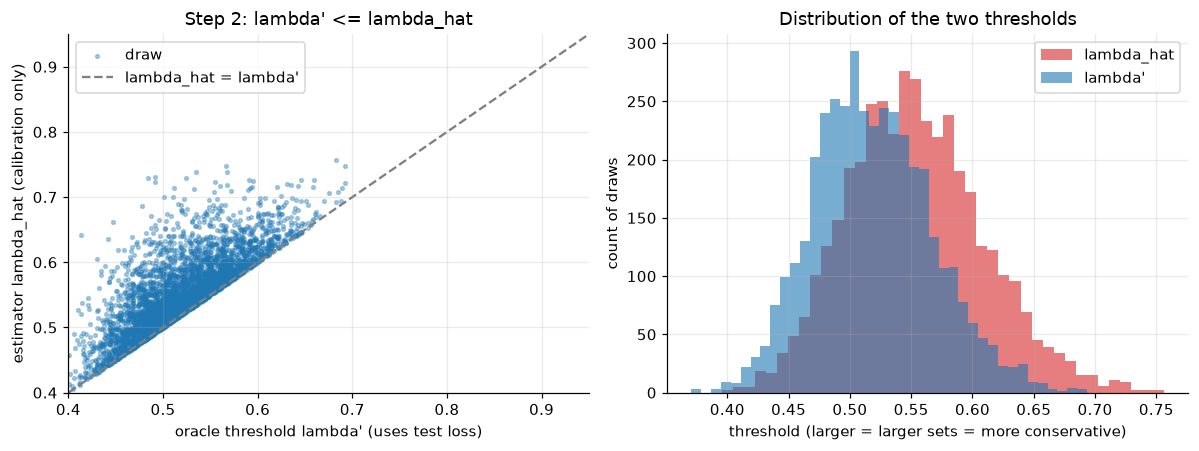

mean lambda_hat = 0.5533, mean lambda' = 0.5188; mean gap = 0.0345


In [40]:
# Figure 5.1: oracle threshold versus the calibration-only estimator (data from the S5.7 audit above)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
c_jit = np.random.default_rng(RNG_SEED + 52).normal(0, 0.002, c_R5)
ax[0].scatter(c_lp + c_jit, c_lh + c_jit, s=6, alpha=0.35, color=PALETTE["clean"], label="draw")
ax[0].plot([0, 1], [0, 1], color=PALETTE["reference"], ls="--", label="lambda_hat = lambda'")
ax[0].set_xlabel("oracle threshold lambda' (uses test loss)"); ax[0].set_ylabel("estimator lambda_hat (calibration only)")
ax[0].set_xlim(0.4, 0.95); ax[0].set_ylim(0.4, 0.95); ax[0].legend(); ax[0].set_title("Step 2: lambda' <= lambda_hat")
ax[1].hist(c_lh, bins=40, alpha=0.6, color=PALETTE["shifted"], label="lambda_hat")
ax[1].hist(c_lp, bins=40, alpha=0.6, color=PALETTE["clean"], label="lambda'")
ax[1].set_xlabel("threshold (larger = larger sets = more conservative)"); ax[1].set_ylabel("count of draws"); ax[1].legend()
ax[1].set_title("Distribution of the two thresholds")
plt.tight_layout(); plt.show()
print(f"mean lambda_hat = {c_lh.mean():.4f}, mean lambda' = {c_lp.mean():.4f}; mean gap = {np.mean(c_lh - c_lp):.4f}")

### How to read this chart

The left panel plots each Monte Carlo draw as one point. The horizontal axis is the oracle threshold $\lambda'$, which uses the test loss and is unavailable in practice. The vertical axis is the estimator $\hat\lambda$ computed from calibration data alone. The dashed grey diagonal is $\hat\lambda=\lambda'$. Because larger $\lambda$ means larger prediction sets, a point above the diagonal is a draw where the estimator is more conservative than the oracle, which is the direction the proof needs (Step 2). A point below the diagonal would break the proof; none should appear. Points sitting exactly on the diagonal are draws where the test point did not change the threshold.

The right panel shows the two marginal distributions of thresholds. The distribution of $\hat\lambda$ is shifted toward larger values relative to $\lambda'$, and that shift is the price of not seeing the test point. It is also the source of the gap between the achieved expected loss and $\alpha$ that Section 6 measures. Horizontal stripes and vertical stripes in the scatter come from the discrete set of order statistics that the threshold can equal.

Takeaway: the estimator is a conservative stand-in for a symmetric oracle, and the printed mean gap above quantifies how much conservativeness the stand-in costs at this sample size. What would make this conclusion wrong: any point below the diagonal.

## 6. Monte Carlo verification of the bound and its O(1/n) gap (derived here; tests claims from q2, q3)

Section 5 argued that CRC is valid and, by the closed form (2), almost exactly tight for indicator losses. This section tests those claims on a data-generating process where the bound is active: risk close to the target $\alpha$, non-trivial prediction sets, real signal in the scores. An earlier version used labels independent of the features and an unbounded temperature; the sets were always full and the measured risk was zero everywhere, which verifies nothing.

**Toy speech-like DGP.** There are $K=8$ classes. Each sample has a random set of $m\in\{1,2,3\}$ true labels (a multi-label stand-in for keyword sets). For each class, a logit equals a signal strength times the indicator that the class is true, plus standard normal noise; probabilities come from a sigmoid with a fixed temperature in $[0.5,2]$, so scores cannot blow up. The prediction set is $C_\lambda(x)=\{k:\ 1-p_k\le\lambda\}$. At $\lambda=0$ almost nothing is included; at $\lambda_{\max}=1$ every class is included and both losses are zero. Larger $\lambda$ therefore means larger sets and a more conservative predictor.

**Two monotone losses, both with $B=1$.**
1. *Set miscoverage* $L^{\rm mis}(\lambda)=\mathbf 1\{\text{some true label}\notin C_\lambda\}=\mathbf 1\{\lambda<\max_{k\in Y}(1-p_k)\}$. One jump per sample, so equation (2) gives its exact expected loss.
2. *False-negative rate* $L^{\rm fnr}(\lambda)=1-|C_\lambda\cap Y|/|Y|=\frac1{|Y|}\sum_{k\in Y}\mathbf 1\{\lambda<1-p_k\}$. Up to three jumps of size $1/|Y|$ per sample. This is a genuinely different loss: $L^{\rm fnr}\le L^{\rm mis}$ pathwise, so its threshold is never larger, and it has no closed form.

Both are non-increasing and right-continuous in $\lambda$, bounded by $B=1$, and zero at $\lambda_{\max}$, so Theorem 1 applies to both (q2).

**Claims under test.**

> Then E[L_{n+1}(λ̂)] ≤ α. (q2, Theorem 1)

> Theorem 2 & Prop. 1: ... for continuous loss jumps, proven tight up to O(1/n) (q3, claims matrix; the lower bound is $\alpha-2B/(n+1)$)

What would make these wrong: measured mean loss above $\alpha$ by more than three standard errors (upper side), or below $\alpha-2B/(n+1)$ by more than three standard errors (lower side). For miscoverage we test the stronger, exact equation (2).

In [41]:
# S6.1-S6.6: DGP sanity (signal present, sets grow with lambda, losses monotone, jump form == set form). seed RNG_SEED+60, N=4000
c_rng = np.random.default_rng(RNG_SEED + 60)
c_Yd, c_Sd = c_draw(c_rng, 1, 4000)
c_Yd, c_Sd = c_Yd[0], c_Sd[0]
c_pd = 1 - c_Sd
c_gap_p = c_pd[c_Yd].mean() - c_pd[~c_Yd].mean()
print(f"mean p (true labels) = {c_pd[c_Yd].mean():.3f}, mean p (other classes) = {c_pd[~c_Yd].mean():.3f}, temperature T={c_TEMP}, p range [{c_pd.min():.3f}, {c_pd.max():.3f}]")
check("S6.1", c_gap_p > 0.10, f"signal: true-label probability exceeds other classes by {c_gap_p:.3f} (labels independent of features would give ~0)")
check("S6.2", c_pd.min() > 0.0 and c_pd.max() < 1.0 and 0.5 <= c_TEMP <= 2.0, f"bounded scores: p in [{c_pd.min():.4f}, {c_pd.max():.4f}], T={c_TEMP} within [0.5, 2]")
c_lams = np.linspace(0, 1, 201)
c_mis = np.array([(c_Yd & (c_Sd > l)).any(-1).mean() for l in c_lams])                       # loss from sets, not from jumps
c_fnr = np.array([((c_Yd & (c_Sd > l)).sum(-1) / c_Yd.sum(-1)).mean() for l in c_lams])
c_size = np.array([(c_Sd <= l).sum(-1).mean() for l in c_lams])
check("S6.3", np.all(np.diff(c_mis) <= 1e-12) and np.all(np.diff(c_fnr) <= 1e-12), f"both population risk curves are non-increasing in lambda on 201 grid points (mis {c_mis[0]:.3f}->{c_mis[-1]:.3f}, fnr {c_fnr[0]:.3f}->{c_fnr[-1]:.3f})")
check("S6.4", np.all(np.diff(c_size) >= -1e-12) and abs(c_size[-1] - c_K) < 1e-12, f"mean set size non-decreasing in lambda, from {c_size[0]:.2f} to K={c_size[-1]:.0f}: larger lambda = larger sets")
check("S6.5", np.all(c_fnr <= c_mis + 1e-12) and 0.05 < c_mis[100] < 0.95, f"FNR <= miscoverage at every lambda; at lambda=0.5 miscoverage risk={c_mis[100]:.3f} (non-trivial, not 0 or 1)")
c_a_d = np.where(c_Yd, c_Sd, -1).max(-1)
check("S6.6", all(abs(np.mean(c_a_d > l) - c_mis[i]) < 1e-12 for i, l in enumerate(c_lams)), "jump representation used by the estimator agrees with the set-based miscoverage at all 201 lambdas")

mean p (true labels) = 0.715, mean p (other classes) = 0.501, temperature T=1.5, p range [0.050, 0.973]
[S6.1] signal: true-label probability exceeds other classes by 0.214 (labels independent of features would give ~0) -> PASS
[S6.2] bounded scores: p in [0.0497, 0.9726], T=1.5 within [0.5, 2] -> PASS
[S6.3] both population risk curves are non-increasing in lambda on 201 grid points (mis 1.000->0.000, fnr 1.000->0.000) -> PASS
[S6.4] mean set size non-decreasing in lambda, from 0.00 to K=8: larger lambda = larger sets -> PASS
[S6.5] FNR <= miscoverage at every lambda; at lambda=0.5 miscoverage risk=0.121 (non-trivial, not 0 or 1) -> PASS
[S6.6] jump representation used by the estimator agrees with the set-based miscoverage at all 201 lambdas -> PASS


True

In [42]:
# S6.7-S6.18: Monte Carlo over n in {24, 54, 104, 204} x alpha in {0.05, 0.10, 0.20}; reps=4000 per cell; seeds RNG_SEED+61+cell
def c_se(x):
    return x.std(ddof=1) / np.sqrt(len(x))


def c_mc_cell(n, alpha, reps, seed, sig_cal=c_SIG, sig_test=None):
    # calibrate both losses on n exchangeable samples, evaluate on one fresh test sample; returns per-rep arrays
    rng = np.random.default_rng(seed)
    Yc, Sc = c_draw(rng, reps, n, sig_cal)
    Yt, St = c_draw(rng, reps, 1, sig_cal if sig_test is None else sig_test)
    aC = np.where(Yc, Sc, -1.0).max(-1)
    wC = Yc / Yc.sum(-1, keepdims=True)
    out = {k: np.empty(reps) for k in ("lamA", "lamB", "LA", "LB", "szA", "szB")}
    one = np.ones(n)
    for r in range(reps):
        lamA = c_lambda_hat(c_curve(aC[r], one, n), n, 1.0, alpha)
        lamB = c_lambda_hat(c_curve(Sc[r][Yc[r]], wC[r][Yc[r]], n), n, 1.0, alpha)
        yt, st = Yt[r, 0], St[r, 0]
        out["lamA"][r], out["lamB"][r] = lamA, lamB
        out["LA"][r] = float(np.any(yt & (st > lamA)))
        out["LB"][r] = (yt & (st > lamB)).sum() / yt.sum()
        out["szA"][r], out["szB"][r] = (st <= lamA).sum(), (st <= lamB).sum()
    return out


c_NS, c_AS, c_REPS = [24, 54, 104, 204], [0.05, 0.10, 0.20], 4000
c_res = {}
for ci, (c_n, c_a) in enumerate([(n, a) for n in c_NS for a in c_AS]):
    c_res[(c_n, c_a)] = c_mc_cell(c_n, c_a, c_REPS, RNG_SEED + 61 + ci)
c_lab = 7
print("n     alpha  closed(2)  E[mis]  SE      E[fnr]  SE      mean lam_A  mean lam_B  size_A  size_B")
for (c_n, c_a), o in c_res.items():
    c_cf = np.floor(c_a * (c_n + 1) + 1e-9) / (c_n + 1)
    print(f"{c_n:<5d} {c_a:<6.2f} {c_cf:.4f}     {o['LA'].mean():.4f}  {c_se(o['LA']):.4f}  {o['LB'].mean():.4f}  {c_se(o['LB']):.4f}  "
          f"{o['lamA'].mean():.4f}      {o['lamB'].mean():.4f}      {o['szA'].mean():.2f}    {o['szB'].mean():.2f}")
for (c_n, c_a), o in c_res.items():
    c_cf = np.floor(c_a * (c_n + 1) + 1e-9) / (c_n + 1)
    c_e, c_s = o["LA"].mean(), max(c_se(o["LA"]), 1e-9)
    check(f"S6.{c_lab}", abs(c_e - c_cf) <= 3 * c_s and c_e <= c_a + 3 * c_s,
          f"miscoverage n={c_n} alpha={c_a}: E={c_e:.4f} vs exact (2)={c_cf:.4f} (3SE={3 * c_s:.4f}); upper bound alpha={c_a}")
    c_lab += 1

n     alpha  closed(2)  E[mis]  SE      E[fnr]  SE      mean lam_A  mean lam_B  size_A  size_B
24    0.05   0.0400     0.0400  0.0031  0.0195  0.0017  0.6174      0.6174      6.42    6.42
24    0.10   0.0800     0.0757  0.0042  0.0758  0.0033  0.5544      0.4987      5.65    4.86
24    0.20   0.2000     0.2005  0.0063  0.1737  0.0047  0.4624      0.4097      4.26    3.45
54    0.05   0.0364     0.0345  0.0029  0.0343  0.0022  0.6105      0.5560      6.41    5.69
54    0.10   0.0909     0.0853  0.0044  0.0879  0.0035  0.5346      0.4779      5.40    4.52
54    0.20   0.2000     0.1983  0.0063  0.1880  0.0049  0.4600      0.4002      4.22    3.28
104   0.05   0.0476     0.0503  0.0035  0.0460  0.0026  0.5848      0.5398      6.12    5.48
104   0.10   0.0952     0.1082  0.0049  0.1005  0.0038  0.5284      0.4710      5.29    4.39
104   0.20   0.2000     0.1895  0.0062  0.1932  0.0049  0.4581      0.3962      4.19    3.20
204   0.05   0.0488     0.0483  0.0034  0.0457  0.0025  0.5794      

In [43]:
# S6.19-S6.34: false-negative-rate loss (S6.19-S6.30 per cell; S6.31-S6.34 across cells). Same runs as above. Upper bound alpha; lower bound alpha - 2B/(n+1) (q3, Theorem 2)
c_lab = 19
c_ratio = []
for (c_n, c_a), o in c_res.items():
    c_e, c_s = o["LB"].mean(), c_se(o["LB"])
    c_ratio.append(c_e / c_a)
    check(f"S6.{c_lab}", (c_e <= c_a + 3 * c_s) and (c_e >= c_a - 2.0 / (c_n + 1) - 3 * c_s),
          f"FNR n={c_n} alpha={c_a}: E={c_e:.4f} in [{c_a - 2.0 / (c_n + 1) - 3 * c_s:.4f}, {c_a + 3 * c_s:.4f}]")
    c_lab += 1
c_pw = all(np.all(o["lamB"] <= o["lamA"] + 1e-12) for o in c_res.values())
check("S6.31", c_pw, "FNR threshold <= miscoverage threshold in every replicate of every cell (pathwise, because L_fnr <= L_mis)")
c_tie = [(n, a) for (n, a) in c_res if a * (n + 1) - 1.0 < 1.0 / 3.0]     # allowed total loss below the smallest FNR jump (1/3): both rules coincide
c_obs_tie = [k for k, o in c_res.items() if np.all(np.abs(o["lamB"] - o["lamA"]) < 1e-12)]
c_szle = all(o["szB"].mean() <= o["szA"].mean() + 1e-12 for o in c_res.values())
check("S6.32", c_szle and sorted(c_obs_tie) == sorted(c_tie) and all(o["szB"].mean() < o["szA"].mean() for k, o in c_res.items() if k not in c_tie),
      f"FNR set size <= miscoverage set size in all 12 cells, strictly smaller except where alpha(n+1)-B < 1/3 (predicted ties {c_tie}, observed ties {c_obs_tie})")
c_zs = min(min(o["LA"].mean() / c_se(o["LA"]), o["LB"].mean() / c_se(o["LB"])) for o in c_res.values())
check("S6.33", c_zs >= 3.0, f"non-vacuity: every cell's measured risk is at least 3 SE above zero for both losses (min mean/SE = {c_zs:.1f}); an all-zero risk would print 0")
c_vac = [k for k in c_res if k[1] - 2.0 / (k[0] + 1) <= 0]
note("S6.33b", f"the q3 lower bound alpha - 2B/(n+1) is vacuous (<= 0) in cells {c_vac}; the exact closed form (2) is the informative test for the miscoverage loss there")
c_m = [np.mean([c_res[(n, 0.10)]["lamA"].mean()]) for n in c_NS]
c_sem = [c_se(c_res[(n, 0.10)]["lamA"]) for n in c_NS]
check("S6.34", all(c_m[i + 1] <= c_m[i] + 3 * np.hypot(c_sem[i], c_sem[i + 1]) for i in range(3)),
      "mean lambda_hat (alpha=0.10) non-increasing in n up to 3SE: " + ", ".join(f"{n}:{v:.4f}" for n, v in zip(c_NS, c_m)))

[S6.19] FNR n=24 alpha=0.05: E=0.0195 in [-0.0350, 0.0550] -> PASS
[S6.20] FNR n=24 alpha=0.1: E=0.0758 in [0.0100, 0.1100] -> PASS
[S6.21] FNR n=24 alpha=0.2: E=0.1737 in [0.1060, 0.2140] -> PASS
[S6.22] FNR n=54 alpha=0.05: E=0.0343 in [0.0069, 0.0567] -> PASS
[S6.23] FNR n=54 alpha=0.1: E=0.0879 in [0.0532, 0.1105] -> PASS
[S6.24] FNR n=54 alpha=0.2: E=0.1880 in [0.1490, 0.2146] -> PASS
[S6.25] FNR n=104 alpha=0.05: E=0.0460 in [0.0232, 0.0577] -> PASS
[S6.26] FNR n=104 alpha=0.1: E=0.1005 in [0.0696, 0.1113] -> PASS
[S6.27] FNR n=104 alpha=0.2: E=0.1932 in [0.1662, 0.2147] -> PASS
[S6.28] FNR n=204 alpha=0.05: E=0.0457 in [0.0326, 0.0576] -> PASS
[S6.29] FNR n=204 alpha=0.1: E=0.0926 in [0.0795, 0.1108] -> PASS
[S6.30] FNR n=204 alpha=0.2: E=0.1940 in [0.1756, 0.2147] -> PASS
[S6.31] FNR threshold <= miscoverage threshold in every replicate of every cell (pathwise, because L_fnr <= L_mis) -> PASS
[S6.32] FNR set size <= miscoverage set size in all 12 cells, strictly smaller except 

True

In [44]:
# S6.35-S6.44: the O(1/n) gap made visible. Rank-based simulation: the miscoverage estimator depends on scores only through ranks,
# so U(0,1) scores are exact for any continuous score law. For a U(0,1) test score, E[L | calibration] = 1 - lambda_hat exactly, so we average
# that conditional expectation (removes the Bernoulli test noise). alpha=0.10, reps=400000 per n (chunks of 20000), seed RNG_SEED+70+n
def c_rank_sim(n, alpha, reps, seed, chunk=20000):
    # Bernoulli version: draws the test score too (used where the loss is not an indicator of one score)
    rng = np.random.default_rng(seed)
    k = int(np.floor(alpha * (n + 1) + 1e-9))
    miss = 0
    for _ in range(reps // chunk):
        S = rng.random((chunk, n + 1))
        lam = np.ones(chunk) if k == 0 else -np.partition(-S[:, :n], k - 1, axis=1)[:, k - 1]
        miss += int(np.sum(S[:, n] > lam))
    return miss / reps


def c_rank_rb(n, alpha, reps, seed, chunk=20000):
    # Rao-Blackwellised: mean and SE of 1 - lambda_hat, lambda_hat = k-th largest of n uniforms (lambda_max = 1 if k = 0)
    rng = np.random.default_rng(seed)
    k = int(np.floor(alpha * (n + 1) + 1e-9))
    vals = []
    for _ in range(reps // chunk):
        S = rng.random((chunk, n))
        lam = np.ones(chunk) if k == 0 else -np.partition(-S, k - 1, axis=1)[:, k - 1]
        vals.append(1.0 - lam)
    v = np.concatenate(vals)
    return v.mean(), v.std(ddof=1) / np.sqrt(len(v))


c_NG, c_AG, c_RG = [24, 54, 104, 204], 0.10, 400000
c_gap = {}
c_lab = 35
for c_n in c_NG:
    c_e, c_s = c_rank_rb(c_n, c_AG, c_RG, RNG_SEED + 70 + c_n)
    c_cf = np.floor(c_AG * (c_n + 1) + 1e-9) / (c_n + 1)
    c_gap[c_n] = (c_AG - c_e, c_s, c_AG - c_cf)
    print(f"n={c_n}: E={c_e:.5f} closed form={c_cf:.5f}  gap alpha-E={c_AG - c_e:+.5f} (3SE={3 * c_s:.5f})  gap*(n+1)={(c_AG - c_e) * (c_n + 1):.3f} +/- {c_s * (c_n + 1):.3f}")
    check(f"S6.{c_lab}", abs(c_e - c_cf) <= 3 * c_s, f"rank sim n={c_n}: E={c_e:.5f} vs equation (2) {c_cf:.5f} (3SE={3 * c_s:.5f})")
    check(f"S6.{c_lab + 1}", (c_AG - c_e) >= -3 * c_s and (c_AG - c_e) <= 2.0 / (c_n + 1) + 3 * c_s,
          f"n={c_n}: 0 <= gap={c_AG - c_e:+.5f} <= 2B/(n+1)={2.0 / (c_n + 1):.5f} (within 3SE)")
    c_lab += 2
c_x = np.log(np.array(c_NG) + 1.0)
c_y = np.log([c_gap[n][0] for n in c_NG])
c_w = np.array([(c_gap[n][0] / c_gap[n][1]) ** 2 for n in c_NG])          # inverse variance of log gap (delta method)
c_xb = np.sum(c_w * c_x) / np.sum(c_w)
c_slope = np.sum(c_w * (c_x - c_xb) * c_y) / np.sum(c_w * (c_x - c_xb) ** 2)
c_slope_se = 1.0 / np.sqrt(np.sum(c_w * (c_x - c_xb) ** 2))
print(f"log-log slope of the gap against n+1: {c_slope:.3f} +/- {c_slope_se:.3f} (SE); O(1/n) predicts -1")
check("S6.43", abs(c_slope + 1.0) <= 3 * c_slope_se, f"log-log slope {c_slope:.3f} within 3 SE ({3 * c_slope_se:.3f}) of -1")
check("S6.44", abs(c_slope + 0.5) > 3 * c_slope_se, f"falsifier: a 1/sqrt(n) gap would have slope -0.5; measured {c_slope:.3f} is more than 3 SE away")

n=24: E=0.08002 closed form=0.08000  gap alpha-E=+0.01998 (3SE=0.00025)  gap*(n+1)=0.499 +/- 0.002
[S6.35] rank sim n=24: E=0.08002 vs equation (2) 0.08000 (3SE=0.00025) -> PASS
[S6.36] n=24: 0 <= gap=+0.01998 <= 2B/(n+1)=0.08000 (within 3SE) -> PASS


n=54: E=0.09086 closed form=0.09091  gap alpha-E=+0.00914 (3SE=0.00018)  gap*(n+1)=0.503 +/- 0.003
[S6.37] rank sim n=54: E=0.09086 vs equation (2) 0.09091 (3SE=0.00018) -> PASS
[S6.38] n=54: 0 <= gap=+0.00914 <= 2B/(n+1)=0.03636 (within 3SE) -> PASS


n=104: E=0.09528 closed form=0.09524  gap alpha-E=+0.00472 (3SE=0.00014)  gap*(n+1)=0.496 +/- 0.005
[S6.39] rank sim n=104: E=0.09528 vs equation (2) 0.09524 (3SE=0.00014) -> PASS
[S6.40] n=104: 0 <= gap=+0.00472 <= 2B/(n+1)=0.01905 (within 3SE) -> PASS


n=204: E=0.09757 closed form=0.09756  gap alpha-E=+0.00243 (3SE=0.00010)  gap*(n+1)=0.499 +/- 0.007
[S6.41] rank sim n=204: E=0.09757 vs equation (2) 0.09756 (3SE=0.00010) -> PASS
[S6.42] n=204: 0 <= gap=+0.00243 <= 2B/(n+1)=0.00976 (within 3SE) -> PASS
log-log slope of the gap against n+1: -1.001 +/- 0.005 (SE); O(1/n) predicts -1
[S6.43] log-log slope -1.001 within 3 SE (0.015) of -1 -> PASS
[S6.44] falsifier: a 1/sqrt(n) gap would have slope -0.5; measured -1.001 is more than 3 SE away -> PASS


True

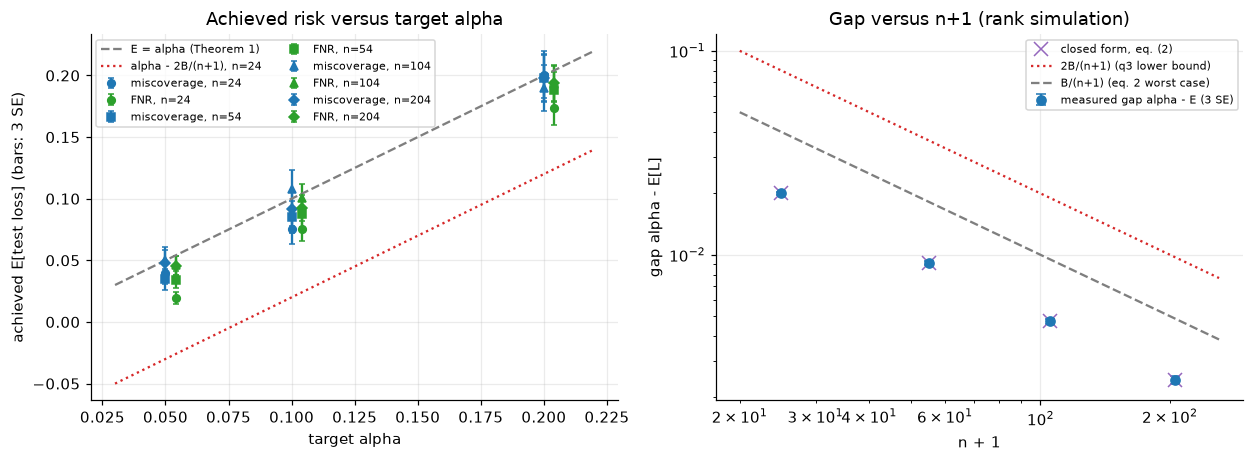

gap*(n+1) by n: {24: np.float64(0.5), 54: np.float64(0.5), 104: np.float64(0.5), 204: np.float64(0.5)} (closed form)


In [45]:
# Figure 6.1: achieved risk versus alpha (both losses) and the O(1/n) gap
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.3))
c_mk = {24: "o", 54: "s", 104: "^", 204: "D"}
for (c_n, c_a), o in c_res.items():
    ax[0].errorbar(c_a, o["LA"].mean(), yerr=3 * c_se(o["LA"]), fmt=c_mk[c_n], color=PALETTE["clean"], ms=5, capsize=2,
                   label=f"miscoverage, n={c_n}" if c_a == 0.05 else None)
    ax[0].errorbar(c_a + 0.004, o["LB"].mean(), yerr=3 * c_se(o["LB"]), fmt=c_mk[c_n], color=PALETTE["acoustic"], ms=5, capsize=2,
                   label=f"FNR, n={c_n}" if c_a == 0.05 else None)
c_x = np.linspace(0.03, 0.22, 10)
ax[0].plot(c_x, c_x, color=PALETTE["reference"], ls="--", label="E = alpha (Theorem 1)")
ax[0].plot(c_x, c_x - 2.0 / 25, color=PALETTE["shifted"], ls=":", label="alpha - 2B/(n+1), n=24")
ax[0].set_xlabel("target alpha"); ax[0].set_ylabel("achieved E[test loss] (bars: 3 SE)"); ax[0].legend(fontsize=7, ncol=2)
ax[0].set_title("Achieved risk versus target alpha")
c_nn = np.array(c_NG)
ax[1].errorbar(c_nn + 1, [max(c_gap[n][0], 1e-5) for n in c_NG], yerr=[3 * c_gap[n][1] for n in c_NG], fmt="o", color=PALETTE["clean"], capsize=3, label="measured gap alpha - E (3 SE)")
ax[1].plot(c_nn + 1, [c_gap[n][2] for n in c_NG], "x", color=PALETTE["frozen"], ms=9, label="closed form, eq. (2)")
c_xx = np.linspace(20, 260, 50)
ax[1].plot(c_xx, 2.0 / c_xx, color=PALETTE["shifted"], ls=":", label="2B/(n+1) (q3 lower bound)")
ax[1].plot(c_xx, 1.0 / c_xx, color=PALETTE["reference"], ls="--", label="B/(n+1) (eq. 2 worst case)")
ax[1].set_xscale("log"); ax[1].set_yscale("log"); ax[1].set_xlabel("n + 1"); ax[1].set_ylabel("gap alpha - E[L]"); ax[1].legend(fontsize=7)
ax[1].set_title("Gap versus n+1 (rank simulation)")
plt.tight_layout(); plt.show()
print("gap*(n+1) by n:", {n: round(c_gap[n][2] * (n + 1), 3) for n in c_NG}, "(closed form)")

### How to read this chart

Left panel: the horizontal axis is the target $\alpha$; the vertical axis is the mean loss on a fresh test point after calibrating with the CRC rule, with bars showing three Monte Carlo standard errors. Blue markers are set miscoverage and green markers are the false-negative rate (nudged right); marker shape encodes $n$. The dashed diagonal is Theorem 1, $\mathbb{E}\le\alpha$. The red dotted line is the lower bound $\alpha-2B/(n+1)$ drawn for the smallest $n$. A marker on or just below the diagonal means the guarantee holds and is nearly tight; above it beyond its bar would be a violation; far below would mean wasteful conservativeness.

Right panel: log-log axes, horizontal $n+1$, vertical the gap $\alpha-\mathbb{E}[L]$ from the rank simulation, where the test loss is replaced by its exact conditional mean so that the standard errors are small. Blue points are measurements (three-standard-error bars), purple crosses the closed form (2), the red dotted line $2B/(n+1)$, the grey dashed line $B/(n+1)$. Points below both lines and falling parallel to them show the $O(1/n)$ decay; the printed log-log slope quantifies "parallel". For other choices of $n$ the gap would zigzag between zero and $B/(n+1)$, being a fractional part divided by $n+1$.

Takeaway: the achieved risk is close to the target and the shortfall is of order $1/n$. Wrong if any point in the left panel lies above the diagonal beyond its bar, or if the printed slope in the right panel is far from $-1$.

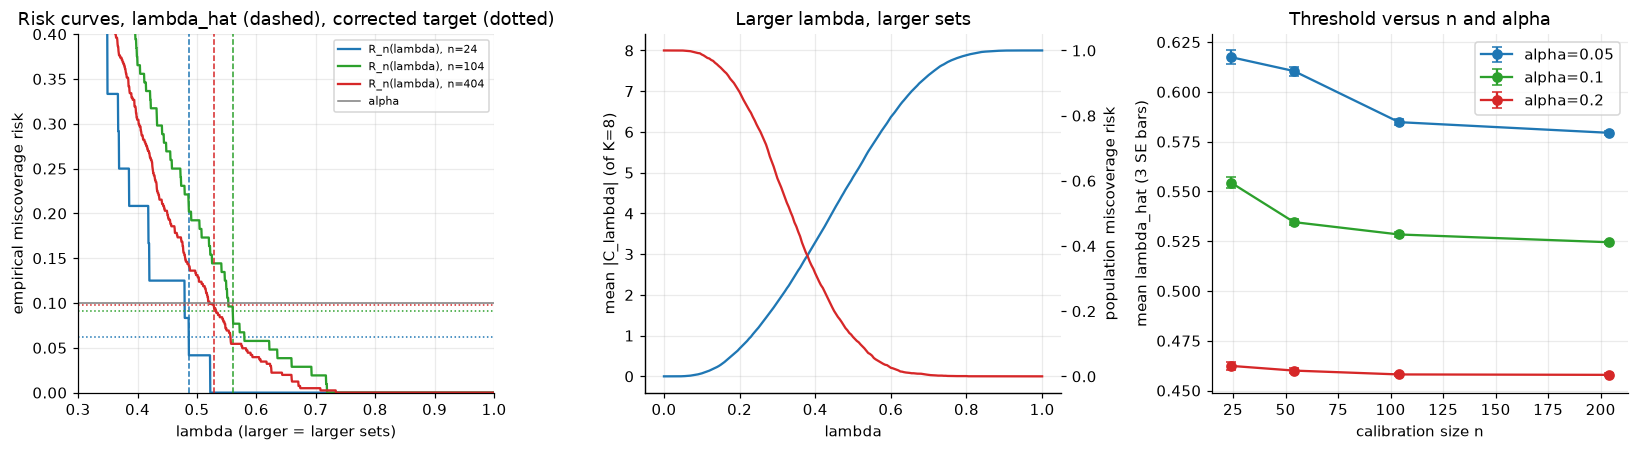

mean lambda_hat by n (alpha=0.05, 0.10, 0.20): {24: (np.float64(0.617), np.float64(0.554), np.float64(0.462)), 54: (np.float64(0.61), np.float64(0.535), np.float64(0.46)), 104: (np.float64(0.585), np.float64(0.528), np.float64(0.458)), 204: (np.float64(0.579), np.float64(0.524), np.float64(0.458))}
mean test set size by n (alpha=0.10, miscoverage loss): {24: np.float64(5.65), 54: np.float64(5.4), 104: np.float64(5.29), 204: np.float64(5.27)}


In [46]:
# Figure 6.2: what the estimator does on one calibration draw, and how conservativeness varies with n and alpha
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
c_rng = np.random.default_rng(RNG_SEED + 80)
c_cols = [PALETTE["clean"], PALETTE["acoustic"], PALETTE["shifted"]]
for c_n, c_col in zip([24, 104, 404], c_cols):
    Yc, Sc = c_draw(c_rng, 1, c_n)
    a = np.where(Yc[0], Sc[0], -1.0).max(-1)
    Rg = c_curve(a, np.ones(c_n), c_n)
    lam = c_lambda_hat(Rg, c_n, 1.0, 0.10)
    ax[0].plot(c_GRID, Rg, color=c_col, label=f"R_n(lambda), n={c_n}")
    ax[0].axhline((0.10 * (c_n + 1) - 1) / c_n, color=c_col, ls=":", lw=1)
    ax[0].axvline(lam, color=c_col, ls="--", lw=1)
ax[0].axhline(0.10, color=PALETTE["reference"], lw=1, label="alpha")
ax[0].set_xlim(0.3, 1.0); ax[0].set_ylim(0, 0.4); ax[0].set_xlabel("lambda (larger = larger sets)"); ax[0].set_ylabel("empirical miscoverage risk")
ax[0].legend(fontsize=7); ax[0].set_title("Risk curves, lambda_hat (dashed), corrected target (dotted)")
ax[1].plot(c_lams, c_size, color=PALETTE["clean"], label="mean set size")
ax[1].set_xlabel("lambda"); ax[1].set_ylabel("mean |C_lambda| (of K=8)"); ax[1].set_title("Larger lambda, larger sets")
ax2 = ax[1].twinx(); ax2.plot(c_lams, c_mis, color=PALETTE["shifted"], label="population miscoverage"); ax2.set_ylabel("population miscoverage risk"); ax2.grid(False)
for c_a, c_col in zip(c_AS, c_cols):
    ax[2].errorbar(c_NS, [c_res[(n, c_a)]["lamA"].mean() for n in c_NS], yerr=[3 * c_se(c_res[(n, c_a)]["lamA"]) for n in c_NS],
                   marker="o", color=c_col, capsize=3, label=f"alpha={c_a}")
ax[2].set_xlabel("calibration size n"); ax[2].set_ylabel("mean lambda_hat (3 SE bars)"); ax[2].legend(); ax[2].set_title("Threshold versus n and alpha")
plt.tight_layout(); plt.show()
print("mean lambda_hat by n (alpha=0.05, 0.10, 0.20):", {n: tuple(round(c_res[(n, a)]["lamA"].mean(), 3) for a in c_AS) for n in c_NS})
print("mean test set size by n (alpha=0.10, miscoverage loss):", {n: round(c_res[(n, 0.10)]["szA"].mean(), 2) for n in c_NS})

### How to read this chart

Left panel: the horizontal axis is $\lambda$ and the vertical axis is the empirical miscoverage risk $\hat R_n(\lambda)$ of one calibration draw per sample size (three colours). Each curve is a non-increasing staircase. The grey line is $\alpha$. The dotted line of matching colour is the corrected target $(\alpha(n+1)-B)/n$ that $\hat R_n$ must fall under, and the dashed vertical line is the resulting $\hat\lambda$, the first $\lambda$ where the staircase crosses the dotted line. Note the dotted lines lie below $\alpha$, and by less as $n$ grows: that is the safety margin.

Middle panel: mean prediction-set size (blue, left axis) and population miscoverage risk (red, right axis) against $\lambda$. Sets grow with $\lambda$ while miscoverage falls, so moving right always trades size for coverage. This is what is meant by a larger $\lambda$ being more conservative.

Right panel: mean $\hat\lambda$ against $n$ for three targets. Stricter targets (smaller $\alpha$) give larger thresholds. Within a target the thresholds do not increase with $n$: the safety margin shrinks as $n$ grows, so they approach the population quantile from the conservative side. Bars are three standard errors.

Takeaway: the correction costs extra set size at small $n$ and the cost fades with $n$. Wrong if a dashed line sat left of the crossing point.

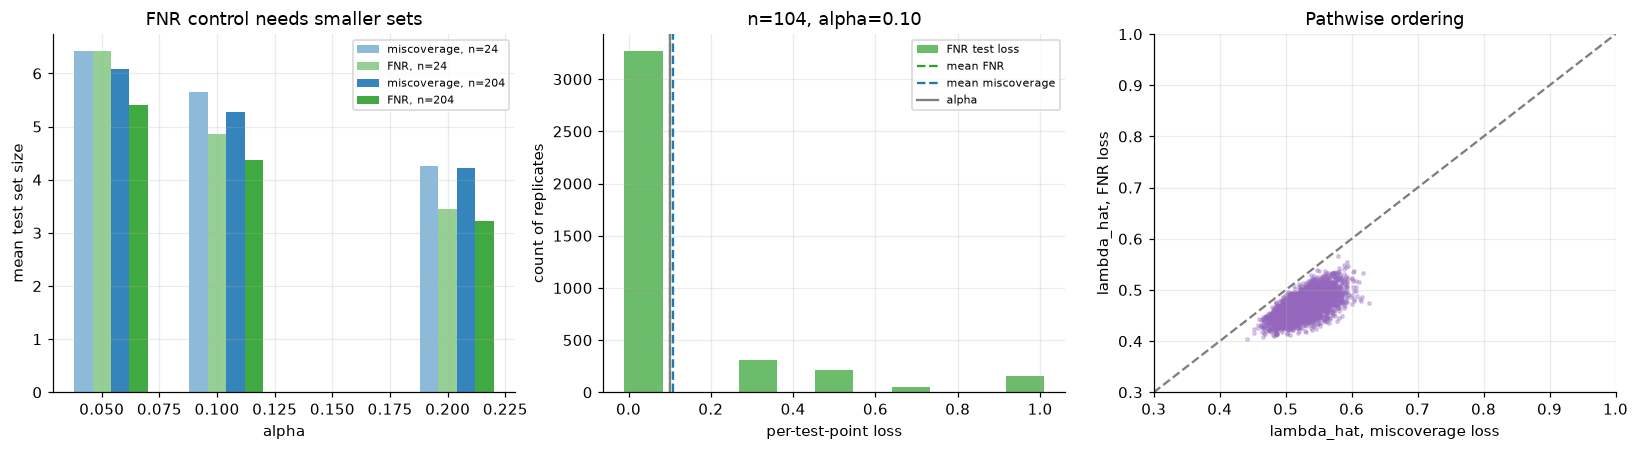

n=104 alpha=0.10: mean FNR=0.1005, mean miscoverage=0.1082, mean size FNR=4.39 vs miscoverage=5.29
fraction of test points with FNR loss exactly 0: 0.817


In [47]:
# Figure 6.3: the false-negative-rate loss compared with set miscoverage (same runs as Figure 6.1/6.2)
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
c_w = 0.008
for c_j, c_n in enumerate([24, 204]):
    ax[0].bar(np.array(c_AS) + (c_j - 0.5) * 2 * c_w, [c_res[(c_n, a)]["szA"].mean() for a in c_AS], width=c_w, color=PALETTE["clean"], alpha=0.5 + 0.4 * c_j,
              label=f"miscoverage, n={c_n}")
    ax[0].bar(np.array(c_AS) + (c_j - 0.5) * 2 * c_w + c_w, [c_res[(c_n, a)]["szB"].mean() for a in c_AS], width=c_w, color=PALETTE["acoustic"], alpha=0.5 + 0.4 * c_j,
              label=f"FNR, n={c_n}")
ax[0].set_xlabel("alpha"); ax[0].set_ylabel("mean test set size"); ax[0].legend(fontsize=7); ax[0].set_title("FNR control needs smaller sets")
c_o = c_res[(104, 0.10)]
ax[1].hist(c_o["LB"], bins=np.linspace(-0.01, 1.01, 12), color=PALETTE["acoustic"], alpha=0.7, label="FNR test loss")
ax[1].axvline(c_o["LB"].mean(), color=PALETTE["acoustic"], ls="--", label="mean FNR")
ax[1].axvline(c_o["LA"].mean(), color=PALETTE["clean"], ls="--", label="mean miscoverage")
ax[1].axvline(0.10, color=PALETTE["reference"], label="alpha")
ax[1].set_xlabel("per-test-point loss"); ax[1].set_ylabel("count of replicates"); ax[1].legend(fontsize=7); ax[1].set_title("n=104, alpha=0.10")
ax[2].scatter(c_o["lamA"] + np.random.default_rng(RNG_SEED + 81).normal(0, 0.002, c_REPS), c_o["lamB"], s=5, alpha=0.3, color=PALETTE["frozen"])
ax[2].plot([0, 1], [0, 1], color=PALETTE["reference"], ls="--")
ax[2].set_xlabel("lambda_hat, miscoverage loss"); ax[2].set_ylabel("lambda_hat, FNR loss"); ax[2].set_title("Pathwise ordering")
ax[2].set_xlim(0.3, 1); ax[2].set_ylim(0.3, 1)
plt.tight_layout(); plt.show()
print(f"n=104 alpha=0.10: mean FNR={c_o['LB'].mean():.4f}, mean miscoverage={c_o['LA'].mean():.4f}, mean size FNR={c_o['szB'].mean():.2f} vs miscoverage={c_o['szA'].mean():.2f}")
print(f"fraction of test points with FNR loss exactly 0: {np.mean(c_o['LB'] == 0):.3f}")

### How to read this chart

Left panel: the horizontal axis is $\alpha$, the vertical axis is the mean size of the prediction set on the test point. Blue bars are miscoverage control and green bars are false-negative-rate control, each drawn for a small and a large $n$ (lighter and darker shading). Compare neighbouring blue and green bars: a green bar below its blue neighbour means the FNR target is met with a smaller set, because missing one of several true labels costs only a fraction of a unit under FNR but a whole unit under miscoverage. Bars coincide when $\alpha(n+1)-B$ is below the smallest FNR jump, since neither rule can then afford a miss.

Middle panel: histogram of the per-test-point FNR loss over replicates at one setting. Losses are multiples of reciprocal label counts, so the histogram has spikes. The dashed green line is the mean FNR, the dashed blue line the mean miscoverage, and the grey line is $\alpha$. Both means should sit near $\alpha$ because both losses were calibrated to the same target; a mean slightly above it is Monte Carlo error.

Right panel: each point is one replicate; the horizontal coordinate is the miscoverage threshold and the vertical coordinate the FNR threshold. The dashed diagonal is equality. Every point on or below it confirms $\hat\lambda^{\rm fnr}\le\hat\lambda^{\rm mis}$, as $L^{\rm fnr}\le L^{\rm mis}$ demands.

Takeaway: the second loss has its own risk, its own thresholds and smaller sets. Wrong if any point lay above the diagonal.

## 7. Controls where the guarantee visibly breaks (derived here; tests claims from q2, q3)

A verification that cannot fail is not a verification. Section 6 showed the bound holding where its assumptions hold. This section removes assumptions one at a time and shows the measured risk leaving the bound. Three controls are used: covariate shift (exchangeability), a non-monotone loss, and a calibration set too small for the correction term.

**Claims under test (q3, Section 5 limitations, as summarised in the trace).**

> Monotonicity Constraint: The procedure strictly requires loss functions L_i(λ) to be non-increasing in λ (q3)

> If losses are non-monotone, risk control can fail arbitrarily (q3, with the failure level E[L_{n+1}(λ̂)] ≥ B − ε)

> Uncompensated distribution shifts invalidate the exchangeability assumption, causing standard CRC to lose validity (q3)

**Control A, covariate shift.** Calibrate at signal strength $1.5$ and test at a weaker signal, a crude stand-in for noise that makes scores less informative. The mean loss at the calibrated threshold should rise above $\alpha$ as the shift grows, while the unshifted control stays at or below it. The paper's own synthetic regression experiment reports the same phenomenon with a different model (q3); our numbers are a toy and are not comparable to it.

**Control B, non-monotone loss.** The trace states the conclusion of Proposition 2 (risk control fails, expected loss at least $B-\epsilon$) but not the construction (q3). We therefore build our own instance of the phenomenon, a selection effect, and do not claim it is the source's counterexample. Each calibration point has, at every non-maximal $\lambda$ on a fine grid, an independent loss in $\{0,1\}$ with mean $\mu$, and loss zero at $\lambda_{\max}$, so the achievability assumption holds. Only monotonicity fails. With many grid points the calibration risk dips below the target somewhere by chance, the inf rule picks that spot, and the fresh test point still has loss mean $\mu$ there. The identity $\mathbb{E}[L_{n+1}(\hat\lambda)]=\mu\cdot\Pr(\hat\lambda<\lambda_{\max})$ is exact and is tested. The remedy in q3, Theorem C.1, replaces $\hat R_n$ by $\hat R_n^\uparrow(\lambda)=\sup_{t\ge\lambda}\hat R_n(t)$; the trace says it gives asymptotic control, so we test only that it removes the failure here.

**Control C, too little calibration data.** The estimator needs $\alpha(n+1)\ge B$ for the set to be non-empty. Below $n_{\min}=\lceil B/\alpha\rceil-1$ the rule returns $\lambda_{\max}$ (full sets) every time. The bound then holds trivially but the predictor is useless.

In [48]:
# S7.1-S7.8: Control A, covariate shift. n=104, alpha=0.10, reps=4000; test signal in {1.5 (control), 1.4, 1.2, 0.9, 0.5}; common seed RNG_SEED+90
c_SHIFTS = [1.5, 1.4, 1.2, 0.9, 0.5]
c_sh = {sg: c_mc_cell(104, 0.10, 4000, RNG_SEED + 90, sig_cal=1.5, sig_test=sg) for sg in c_SHIFTS}   # same seed: identical calibration sets, only the test law changes
print("test signal   E[mis]   SE      E[fnr]   SE      mean size (mis)")
for sg, o in c_sh.items():
    print(f"{sg:<12.1f} {o['LA'].mean():.4f}  {c_se(o['LA']):.4f}  {o['LB'].mean():.4f}   {c_se(o['LB']):.4f}  {o['szA'].mean():.2f}")
c_c, c_st = c_sh[1.5], c_sh[0.5]
check("S7.1", c_c["LA"].mean() <= 0.10 + 3 * c_se(c_c["LA"]), f"exchangeable control: E[mis]={c_c['LA'].mean():.4f} <= alpha=0.10 + 3SE={3 * c_se(c_c['LA']):.4f}")
check("S7.2", c_c["LB"].mean() <= 0.10 + 3 * c_se(c_c["LB"]), f"exchangeable control: E[fnr]={c_c['LB'].mean():.4f} <= alpha=0.10 + 3SE")
check("S7.3", c_st["LA"].mean() > 0.10 + 3 * c_se(c_st["LA"]), f"strong shift breaks miscoverage control: E={c_st['LA'].mean():.4f} > alpha + 3SE = {0.10 + 3 * c_se(c_st['LA']):.4f}")
check("S7.4", c_st["LB"].mean() > 0.10 + 3 * c_se(c_st["LB"]), f"strong shift breaks FNR control: E={c_st['LB'].mean():.4f} > alpha + 3SE = {0.10 + 3 * c_se(c_st['LB']):.4f}")
c_chain = [c_sh[s]["LA"].mean() for s in c_SHIFTS]
c_chse = [c_se(c_sh[s]["LA"]) for s in c_SHIFTS]
check("S7.5", all(c_chain[i + 1] >= c_chain[i] - 3 * np.hypot(c_chse[i], c_chse[i + 1]) for i in range(4)),
      "miscoverage risk is non-decreasing along the shift sweep (within 3SE of each step): " + ", ".join(f"{v:.3f}" for v in c_chain))
check("S7.6", c_st["LA"].mean() > 2 * c_c["LA"].mean(), f"strongest shift more than doubles the risk: {c_st['LA'].mean():.3f} vs control {c_c['LA'].mean():.3f}")
c_mild = c_sh[1.4]["LA"].mean() > 0.10 + 3 * c_se(c_sh[1.4]["LA"])
note("S7.7", f"mildest shift (test signal 1.4): E[mis]={c_sh[1.4]['LA'].mean():.4f} vs alpha+3SE={0.10 + 3 * c_se(c_sh[1.4]['LA']):.4f}; "
             f"violation {'detected' if c_mild else 'NOT detected'} at this n and reps; margin over the bar = {c_sh[1.4]['LA'].mean() - 0.10 - 3 * c_se(c_sh[1.4]['LA']):+.4f}")
check("S7.8", all(np.array_equal(c_sh[s_]["lamA"], c_c["lamA"]) and np.array_equal(c_sh[s_]["lamB"], c_c["lamB"]) for s_ in c_SHIFTS),
      "the calibrated thresholds are identical arrays under every test-time shift (the rule cannot see the shift)")
check("S7.9", c_st["szA"].mean() <= c_c["szA"].mean() + 3 * np.hypot(c_se(c_st["szA"]), c_se(c_c["szA"])),
      f"sets do not grow to compensate: mean size {c_c['szA'].mean():.2f} (control) -> {c_st['szA'].mean():.2f} (strongest shift)")

test signal   E[mis]   SE      E[fnr]   SE      mean size (mis)
1.5          0.0983  0.0047  0.0966   0.0037  5.29
1.4          0.1172  0.0051  0.1146   0.0039  5.27
1.2          0.1660  0.0059  0.1568   0.0045  5.21
0.9          0.2655  0.0070  0.2323   0.0052  5.10
0.5          0.4228  0.0078  0.3723   0.0060  4.88
[S7.1] exchangeable control: E[mis]=0.0983 <= alpha=0.10 + 3SE=0.0141 -> PASS
[S7.2] exchangeable control: E[fnr]=0.0966 <= alpha=0.10 + 3SE -> PASS
[S7.3] strong shift breaks miscoverage control: E=0.4228 > alpha + 3SE = 0.1234 -> PASS
[S7.4] strong shift breaks FNR control: E=0.3723 > alpha + 3SE = 0.1179 -> PASS
[S7.5] miscoverage risk is non-decreasing along the shift sweep (within 3SE of each step): 0.098, 0.117, 0.166, 0.266, 0.423 -> PASS
[S7.6] strongest shift more than doubles the risk: 0.423 vs control 0.098 -> PASS
[S7.7] mildest shift (test signal 1.4): E[mis]=0.1172 vs alpha+3SE=0.1153; violation detected at this n and reps; margin over the bar = +0.0020 -> NO

True

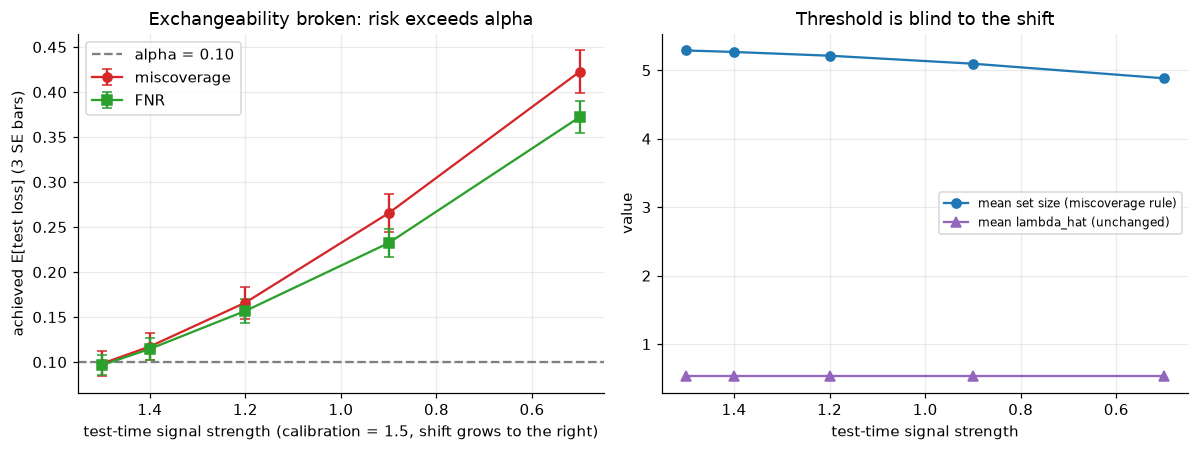

E[mis] from control to strongest shift: 0.0983 -> 0.4228; alpha = 0.10


In [49]:
# Figure 7.1: covariate shift sweep
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
c_xs = np.array(c_SHIFTS)
ax[0].errorbar(c_xs, [c_sh[s]["LA"].mean() for s in c_SHIFTS], yerr=[3 * c_se(c_sh[s]["LA"]) for s in c_SHIFTS], marker="o", color=PALETTE["shifted"], capsize=3, label="miscoverage")
ax[0].errorbar(c_xs, [c_sh[s]["LB"].mean() for s in c_SHIFTS], yerr=[3 * c_se(c_sh[s]["LB"]) for s in c_SHIFTS], marker="s", color=PALETTE["acoustic"], capsize=3, label="FNR")
ax[0].axhline(0.10, color=PALETTE["reference"], ls="--", label="alpha = 0.10")
ax[0].invert_xaxis(); ax[0].set_xlabel("test-time signal strength (calibration = 1.5, shift grows to the right)")
ax[0].set_ylabel("achieved E[test loss] (3 SE bars)"); ax[0].legend(); ax[0].set_title("Exchangeability broken: risk exceeds alpha")
ax[1].plot(c_xs, [c_sh[s]["szA"].mean() for s in c_SHIFTS], marker="o", color=PALETTE["clean"], label="mean set size (miscoverage rule)")
ax[1].plot(c_xs, [c_sh[s]["lamA"].mean() for s in c_SHIFTS], marker="^", color=PALETTE["frozen"], label="mean lambda_hat (unchanged)")
ax[1].invert_xaxis(); ax[1].set_xlabel("test-time signal strength"); ax[1].set_ylabel("value"); ax[1].legend(fontsize=8)
ax[1].set_title("Threshold is blind to the shift")
plt.tight_layout(); plt.show()
print(f"E[mis] from control to strongest shift: {c_c['LA'].mean():.4f} -> {c_st['LA'].mean():.4f}; alpha = 0.10")

### How to read this chart

Left panel: the horizontal axis is the test-time signal strength, drawn reversed so that the shift grows to the right; the leftmost point equals the calibration signal, so it is the exchangeable control. The vertical axis is the achieved mean test loss with three standard error bars. Red is miscoverage, green is the false-negative rate, and the grey dashed line is the target $\alpha$. A point on or below the dashed line means the guarantee holds; above it, beyond its bar, it failed. The control should sit at or under the line and the shifted points climb above it.

Right panel: the mean threshold $\hat\lambda$ (purple) and the mean test-set size (blue) against the same axis. The threshold was computed before the shift, so its line is exactly flat. The set size on shifted test points does not grow to compensate. A flat threshold and non-growing sets while the risk climbs mean nothing available at calibration time announces the failure.

Takeaway: the finite-sample guarantee is specific to exchangeable data, and the size of the violation grows with the severity of the shift. The mildest shift sits close to the noise floor of the test, and whether it clears the three-standard-error bar depends on the seed and on the number of replicates; the printed note for this run says which side it fell on. Wrong if the shifted points remained under the dashed line.

In [50]:
# S7.10-S7.18: Control B, non-monotone loss (selection effect). n=10, alpha=0.30, B=1, mu=0.7, grid G=2000, reps=20000, seed RNG_SEED+100
from math import comb
c_nB, c_aB, c_muB, c_GB, c_RB, c_CH = 10, 0.30, 0.7, 2000, 20000, 500
c_rng = np.random.default_rng(RNG_SEED + 100)
c_hit, c_Ltest, c_hit_up, c_Ltest_up, c_wiggle, c_top = [], [], [], [], [], []
for _ in range(c_RB // c_CH):
    L = (c_rng.random((c_CH, c_nB + 1, c_GB)) < c_muB).astype(np.int8)
    L[:, :, -1] = 0                                        # achievability: loss 0 at lambda_max
    Rn = L[:, :c_nB].mean(1)
    ok = (c_nB / (c_nB + 1)) * Rn + 1.0 / (c_nB + 1) <= c_aB + 1e-12
    idx = np.where(ok.any(1), ok.argmax(1), c_GB - 1)
    Rup = np.maximum.accumulate(Rn[:, ::-1], axis=1)[:, ::-1]           # sup_{t >= lambda} R_n(t), q3 Theorem C.1 construction
    ok_up = (c_nB / (c_nB + 1)) * Rup + 1.0 / (c_nB + 1) <= c_aB + 1e-12
    idx_up = np.where(ok_up.any(1), ok_up.argmax(1), c_GB - 1)
    rows = np.arange(c_CH)
    c_hit.append(idx < c_GB - 1); c_Ltest.append(L[rows, c_nB, idx])
    c_hit_up.append(idx_up < c_GB - 1); c_Ltest_up.append(L[rows, c_nB, idx_up])
    c_wiggle.append((np.diff(L[:, 0, :].astype(int), axis=1) > 0).any(1)); c_top.append(L[:, :, -1].max())
c_hit, c_Ltest, c_hit_up, c_Ltest_up, c_wiggle = map(np.concatenate, (c_hit, c_Ltest, c_hit_up, c_Ltest_up, c_wiggle))
c_eB, c_seB = c_Ltest.mean(), c_se(c_Ltest.astype(float))
c_eU, c_seU = c_Ltest_up.mean(), c_se(c_Ltest_up.astype(float))
c_eC = c_rank_sim(c_nB, c_aB, 100000, RNG_SEED + 101, chunk=10000)
c_seC = np.sqrt(c_eC * (1 - c_eC) / 100000)
c_kB = int(np.floor(c_aB * (c_nB + 1) - 1 + 1e-9))                         # largest number of nonzero losses that passes the corrected test
c_pB = sum(comb(c_nB, j) * c_muB ** j * (1 - c_muB) ** (c_nB - j) for j in range(0, c_kB + 1))   # P(one grid point passes): at most c_kB ones among n
c_hit_exact = 1.0 - (1.0 - c_pB) ** (c_GB - 1)
c_cfC = np.floor(c_aB * (c_nB + 1)) / (c_nB + 1)
print(f"non-monotone: P(lambda_hat < lambda_max) = {c_hit.mean():.3f} (exact {c_hit_exact:.3f}), E[L(lambda_hat)] = {c_eB:.4f} +/- {c_seB:.4f} vs alpha = {c_aB}")
print(f"monotonized (sup_(t>=lambda) R_n): P(lambda_hat < lambda_max) = {c_hit_up.mean():.4f}, E = {c_eU:.4f} +/- {c_seU:.4f}")
print(f"monotone control (indicator loss, same n and alpha): E = {c_eC:.4f} +/- {c_seC:.4f} vs closed form {c_cfC:.4f}")
check("S7.10", c_eB > c_aB + 3 * c_seB, f"non-monotone loss breaks control: E={c_eB:.4f} > alpha + 3SE = {c_aB + 3 * c_seB:.4f}")
check("S7.11", abs(c_hit.mean() - c_hit_exact) <= 3 * c_se(c_hit.astype(float)), f"P(hit) = {c_hit.mean():.4f} vs exact 1-(1-p)^(G-1) = {c_hit_exact:.4f} (p = {c_pB:.4f} is a binomial tail)")
check("S7.12", abs(c_eB - c_muB * c_hit_exact) <= 3 * c_seB, f"exact value E[L(lambda_hat)] = mu * P(hit): {c_eB:.4f} vs {c_muB * c_hit_exact:.4f}")
check("S7.13", c_eB > 0.5 * c_muB, f"failure is large, not marginal: E={c_eB:.3f} vs half of mu = {0.5 * c_muB:.3f} (q3: fails up to B - eps)")
check("S7.14", c_eU <= c_aB + 3 * c_seU, f"monotonized empirical risk restores control here: E={c_eU:.4f} <= alpha + 3SE = {c_aB + 3 * c_seU:.4f}")
check("S7.15", c_eC <= c_aB + 3 * c_seC and abs(c_eC - c_cfC) <= 3 * c_seC, f"monotone control at same n, alpha: E={c_eC:.4f} <= alpha and equals eq. (2) {c_cfC:.4f} within 3SE")
check("S7.16", max(c_top) == 0, f"achievability holds (max loss at lambda_max = {max(c_top)} <= alpha), so monotonicity alone is responsible")
check("S7.17", c_wiggle.mean() > 0.99, f"loss paths are non-monotone: an upward step in {c_wiggle.mean():.1%} of sampled paths")
note("S7.18", f"the monotonized rule is very conservative here (P(hit) = {c_hit_up.mean():.4f}, E = {c_eU:.4f} against alpha = {c_aB}): validity is bought with a nearly useless predictor. q3 claims only asymptotic control for Theorem C.1.")

non-monotone: P(lambda_hat < lambda_max) = 0.960 (exact 0.958), E[L(lambda_hat)] = 0.6744 +/- 0.0033 vs alpha = 0.3
monotonized (sup_(t>=lambda) R_n): P(lambda_hat < lambda_max) = 0.0014, E = 0.0009 +/- 0.0002
monotone control (indicator loss, same n and alpha): E = 0.2747 +/- 0.0014 vs closed form 0.2727
[S7.10] non-monotone loss breaks control: E=0.6744 > alpha + 3SE = 0.3099 -> PASS
[S7.11] P(hit) = 0.9596 vs exact 1-(1-p)^(G-1) = 0.9585 (p = 0.0016 is a binomial tail) -> PASS
[S7.12] exact value E[L(lambda_hat)] = mu * P(hit): 0.6744 vs 0.6709 -> PASS
[S7.13] failure is large, not marginal: E=0.674 vs half of mu = 0.350 (q3: fails up to B - eps) -> PASS
[S7.14] monotonized empirical risk restores control here: E=0.0009 <= alpha + 3SE = 0.3006 -> PASS
[S7.15] monotone control at same n, alpha: E=0.2747 <= alpha and equals eq. (2) 0.2727 within 3SE -> PASS
[S7.16] achievability holds (max loss at lambda_max = 0 <= alpha), so monotonicity alone is responsible -> PASS
[S7.17] loss path

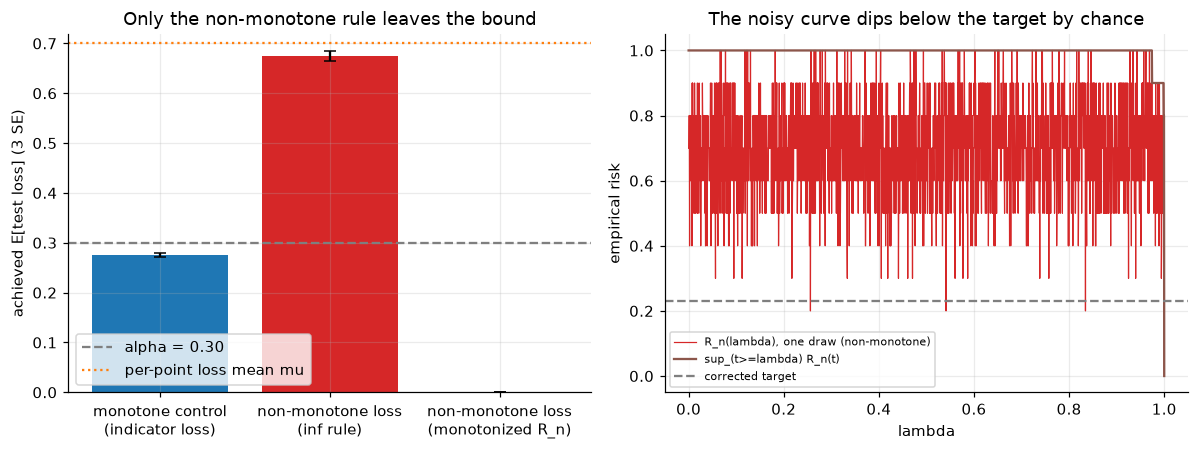

bars: control 0.2747, non-monotone 0.6744, monotonized 0.0009; alpha = 0.3


In [51]:
# Figure 7.2: non-monotone loss versus monotone control versus monotonized remedy
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
c_names = ["monotone control\n(indicator loss)", "non-monotone loss\n(inf rule)", "non-monotone loss\n(monotonized R_n)"]
c_vals = [c_eC, c_eB, c_eU]; c_errs = [3 * c_seC, 3 * c_seB, 3 * c_seU]
ax[0].bar(c_names, c_vals, yerr=c_errs, color=[PALETTE["clean"], PALETTE["shifted"], PALETTE["adapted"]], capsize=4)
ax[0].axhline(c_aB, color=PALETTE["reference"], ls="--", label="alpha = 0.30"); ax[0].axhline(c_muB, color=PALETTE["mask"], ls=":", label="per-point loss mean mu")
ax[0].set_ylabel("achieved E[test loss] (3 SE)"); ax[0].legend(); ax[0].set_title("Only the non-monotone rule leaves the bound")
c_rr = np.random.default_rng(RNG_SEED + 102)
c_Lx = (c_rr.random((c_nB, c_GB)) < c_muB).astype(float); c_Lx[:, -1] = 0
c_Rx = c_Lx.mean(0); c_Rux = np.maximum.accumulate(c_Rx[::-1])[::-1]
ax[1].plot(np.linspace(0, 1, c_GB), c_Rx, color=PALETTE["shifted"], lw=0.8, label="R_n(lambda), one draw (non-monotone)")
ax[1].plot(np.linspace(0, 1, c_GB), c_Rux, color=PALETTE["adapted"], lw=1.5, label="sup_(t>=lambda) R_n(t)")
ax[1].axhline((c_aB * (c_nB + 1) - 1) / c_nB, color=PALETTE["reference"], ls="--", label="corrected target")
ax[1].set_xlabel("lambda"); ax[1].set_ylabel("empirical risk"); ax[1].legend(fontsize=7); ax[1].set_title("The noisy curve dips below the target by chance")
plt.tight_layout(); plt.show()
print(f"bars: control {c_eC:.4f}, non-monotone {c_eB:.4f}, monotonized {c_eU:.4f}; alpha = {c_aB}")

### How to read this chart

Left panel: three bars, each an achieved mean test loss with a three-standard-error whisker. The grey dashed line is the target $\alpha$ and the orange dotted line is the mean loss $\mu$ of a single point at a non-maximal setting. A bar at or under the dashed line means the guarantee held. The first bar is the exchangeable, monotone control with the same $n$ and $\alpha$, at the level predicted by equation (2). The second bar is the plain inf rule applied to non-monotone losses; it sits well above $\alpha$, at the level of $\mu$ times the fraction of draws where the rule found a spot to stop, an identity that the printed checks verify against a binomial closed form. The third bar applies the monotonized empirical risk from q3's Theorem C.1 and returns to the safe side.

Right panel: a single calibration draw of the non-monotone empirical risk (red) with its running supremum from the right (brown), and the corrected target (grey dashed). The red curve is jagged: with many candidate settings, chance alone drags it under the target somewhere, and the inf rule stops at the first such spot. That spot is a selection artefact, so the fresh test point sees the full $\mu$. The brown curve, a supremum of everything to its right, stays above the target until the far end.

Takeaway: monotonicity is what protects the rule from selecting a lucky setting. Wrong if the second bar were at or under the dashed line.

In [52]:
# S7.19-S7.26: Control C, calibration set too small. alpha=0.05, B=1 -> n_min = ceil(B/alpha) - 1; reps=4000 per n; seeds RNG_SEED+110+i
c_aC = 0.05
c_nmin = int(np.ceil(1.0 / c_aC)) - 1
c_NC = [5, 10, 15, c_nmin - 1, c_nmin, c_nmin + 1, 30, 60]
c_sm = {n: c_mc_cell(n, c_aC, 4000, RNG_SEED + 110 + i) for i, n in enumerate(c_NC)}
print(f"n_min = ceil(B/alpha) - 1 = {c_nmin}")
print("n     P(lambda_hat=lambda_max)  mean size  E[mis]   SE      closed form (2)   E[fnr]")
def c_cf2(n, a=c_aC):
    return np.floor(a * (n + 1) + 1e-9) / (n + 1)
for n, o in c_sm.items():
    print(f"{n:<5d} {float(np.mean(o['lamA'] == 1.0)):<25.3f} {o['szA'].mean():<10.2f} {o['LA'].mean():.4f}   {c_se(o['LA']):.4f}  {c_cf2(n):.4f}            {o['LB'].mean():.4f}")
c_below = [n for n in c_NC if n < c_nmin]
c_above = [n for n in c_NC if n >= c_nmin]
check("S7.19", all(np.all(c_sm[n]["lamA"] == 1.0) and np.all(c_sm[n]["lamB"] == 1.0) for n in c_below), f"n < {c_nmin} (n in {c_below}): lambda_hat = lambda_max for both losses in every replicate")
check("S7.20", all(np.all(c_sm[n]["szA"] == c_K) for n in c_below), f"n < {c_nmin}: test set is the full label set (size K={c_K}) in every replicate")
check("S7.21", all(c_sm[n]["LA"].mean() == 0.0 and c_sm[n]["LB"].mean() == 0.0 for n in c_below), f"n < {c_nmin}: measured risk is exactly 0, versus target alpha={c_aC}: valid but wasteful")
c_at = c_sm[c_nmin]
check("S7.22", np.mean(c_at["lamA"] == 1.0) < 1.0 and c_at["szA"].mean() < c_K, f"n = n_min = {c_nmin}: rule becomes satisfiable, P(full) = {np.mean(c_at['lamA'] == 1.0):.3f}, mean size {c_at['szA'].mean():.2f} < K")
check("S7.23", all(abs(c_sm[n]["LA"].mean() - c_cf2(n)) <= 3 * c_se(c_sm[n]["LA"]) for n in c_above),
      "for every n >= n_min the measured miscoverage matches eq. (2) within 3SE: " + ", ".join(f"{n}: {c_sm[n]['LA'].mean():.4f} vs {c_cf2(n):.4f}" for n in c_above))
check("S7.24", all(c_sm[n]["LA"].mean() <= c_aC + 3 * c_se(c_sm[n]["LA"]) for n in c_NC), "the upper bound alpha holds for every n, including the unsatisfiable ones")
c_l0, c_l1 = c_sm[c_nmin]["lamA"], c_sm[30]["lamA"]                                 # both n have k = floor(alpha(n+1)) = 1: lambda_hat is the largest score
check("S7.25", c_l1.mean() > c_l0.mean() + 3 * np.hypot(c_se(c_l1), c_se(c_l0)) and int(np.floor(c_aC * 31)) == int(np.floor(c_aC * (c_nmin + 1))) == 1,
      f"within the k=1 regime lambda_hat is the sample maximum, which grows with n: mean lambda_hat {c_l0.mean():.4f} (n={c_nmin}) -> {c_l1.mean():.4f} (n=30); a decreasing-with-n claim would fail")
c_gaps = {n: c_aC - c_sm[n]["LA"].mean() for n in c_NC}
check("S7.26", all(abs(c_gaps[n] - c_aC) < 1e-12 for n in c_below) and all(abs(c_gaps[n]) < 0.5 * c_aC for n in c_above),
      f"gap alpha - E equals alpha exactly below n_min and is smaller than alpha/2 in absolute value at or above it: " + ", ".join(f"{n}: {g:+.4f}" for n, g in c_gaps.items()))

n_min = ceil(B/alpha) - 1 = 19
n     P(lambda_hat=lambda_max)  mean size  E[mis]   SE      closed form (2)   E[fnr]
5     1.000                     8.00       0.0000   0.0000  0.0000            0.0000
10    1.000                     8.00       0.0000   0.0000  0.0000            0.0000
15    1.000                     8.00       0.0000   0.0000  0.0000            0.0000
18    1.000                     8.00       0.0000   0.0000  0.0000            0.0000
19    0.000                     6.21       0.0483   0.0034  0.0500            0.0234
20    0.000                     6.31       0.0465   0.0033  0.0476            0.0245
30    0.000                     6.61       0.0315   0.0028  0.0323            0.0294
60    0.000                     6.10       0.0493   0.0034  0.0492            0.0380
[S7.19] n < 19 (n in [5, 10, 15, 18]): lambda_hat = lambda_max for both losses in every replicate -> PASS
[S7.20] n < 19: test set is the full label set (size K=8) in every replicate -> PASS
[S7.21] n < 1

True

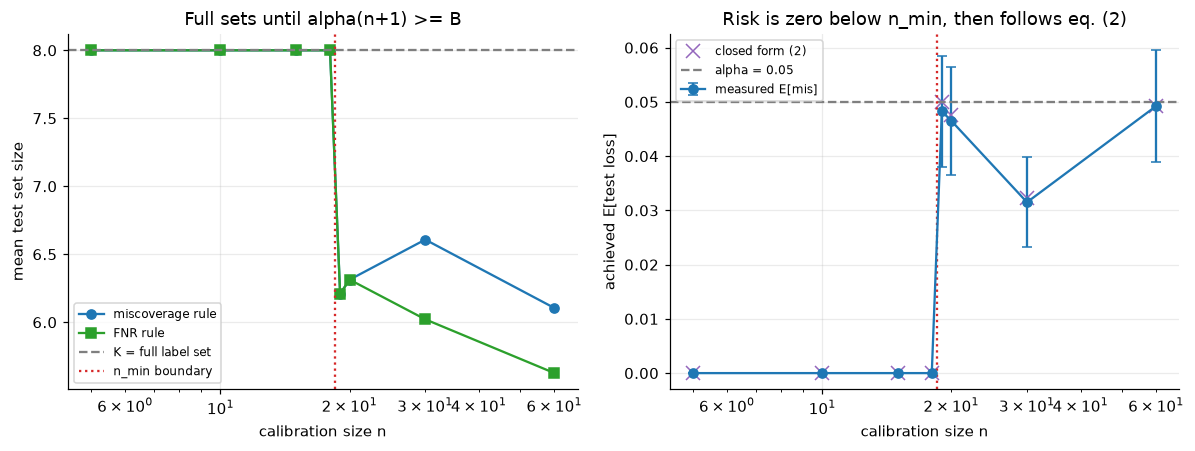

n_min = 19; risk at n=5: 0.0000; at n=19: 0.0483


In [53]:
# Figure 7.3: what happens when n is below the satisfiability threshold
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
c_xn = np.array(c_NC)
ax[0].plot(c_xn, [c_sm[n]["szA"].mean() for n in c_NC], marker="o", color=PALETTE["clean"], label="miscoverage rule")
ax[0].plot(c_xn, [c_sm[n]["szB"].mean() for n in c_NC], marker="s", color=PALETTE["acoustic"], label="FNR rule")
ax[0].axhline(c_K, color=PALETTE["reference"], ls="--", label="K = full label set"); ax[0].axvline(c_nmin - 0.5, color=PALETTE["shifted"], ls=":", label="n_min boundary")
ax[0].set_xscale("log"); ax[0].set_xlabel("calibration size n"); ax[0].set_ylabel("mean test set size"); ax[0].legend(fontsize=8); ax[0].set_title("Full sets until alpha(n+1) >= B")
ax[1].errorbar(c_xn, [c_sm[n]["LA"].mean() for n in c_NC], yerr=[3 * c_se(c_sm[n]["LA"]) for n in c_NC], marker="o", color=PALETTE["clean"], capsize=3, label="measured E[mis]")
ax[1].plot(c_xn, [np.floor(c_aC * (n + 1) + 1e-9) / (n + 1) for n in c_NC], "x", color=PALETTE["frozen"], ms=9, label="closed form (2)")
ax[1].axhline(c_aC, color=PALETTE["reference"], ls="--", label="alpha = 0.05"); ax[1].axvline(c_nmin - 0.5, color=PALETTE["shifted"], ls=":")
ax[1].set_xscale("log"); ax[1].set_xlabel("calibration size n"); ax[1].set_ylabel("achieved E[test loss]"); ax[1].legend(fontsize=8); ax[1].set_title("Risk is zero below n_min, then follows eq. (2)")
plt.tight_layout(); plt.show()
print(f"n_min = {c_nmin}; risk at n={c_NC[0]}: {c_sm[c_NC[0]]['LA'].mean():.4f}; at n={c_nmin}: {c_sm[c_nmin]['LA'].mean():.4f}")

### How to read this chart

Left panel: the horizontal axis (logarithmic) is the calibration size $n$; the vertical axis is the mean test-set size. Blue is the miscoverage rule and green the false-negative-rate rule; the grey dashed line marks the full label set of $K$ classes, and the red dotted vertical line marks the boundary below which $\alpha(n+1)<B$. Points on the grey line mean the estimator returned $\lambda_{\max}$, so any class is possible; points below it mean a smaller certified set.

Right panel: the achieved mean loss against $n$, with three-standard-error bars, the exact value from equation (2) as purple crosses, and the target $\alpha$ as a grey dashed line. Left of the red dotted line the measured risk is exactly zero, far under $\alpha$: the guarantee holds but only because the predictor is trivial. From the boundary on, the measured risk is nonzero and follows the crosses within its bars; it can sit well under $\alpha$ where $\alpha(n+1)$ has a large fractional part, because the floor operation discards it. In the left panel, while $\lfloor\alpha(n+1)\rfloor$ stays at one the threshold is the sample maximum and the set size rises with $n$; it falls when the floor steps up.

Takeaway: the correction term $B/(n+1)$ is a real cost. A non-trivial predictor needs at least about $B/\alpha-1$ calibration points, and for such small $n$ the risk is decided by a floor operation, so it moves in steps. Wrong if the risk below the boundary were nonzero, or if points above it left the dashed line.

## What conformal risk control does not establish (derived here; boundaries from q2, q3)

**What the runs above did establish (toy DGP only).** On exchangeable, monotone, bounded toy data, the inf-rule estimator hits the exact closed-form expected miscoverage, the false-negative-rate loss stays inside the upper bound and the lower bound, and the gap to $\alpha$ is of order $1/n$. Each of the three controls broke the guarantee in the way the assumption suggests, and a monotonized rule repaired the non-monotone case at the cost of conservativeness.

**What they did not establish.**
- That standard, unweighted CRC is valid under real acoustic shift for speech commands. Our shift is a change of signal strength in a synthetic multi-label model. The trace states the claim only qualitatively (q2): exchangeability between calibration and test audio is violated under noise, reverberation or microphone changes. Whether a given real shift is mild enough to hide inside Monte Carlo noise is an empirical question; our own mildest shift lies close to the detection limit of the test at this number of replicates, so small violations are hard to separate from noise.
- How much calibration data is needed under shift. The toy shift is far simpler than real acoustic conditions. This is a hypothesis-free statement of a limit: nothing here calibrates the size of a real violation.
- Anything about a single test set. Theorem 1 bounds the expectation over the joint draw of calibration and test points (q2). A single held-out set gives one realisation, and staying under $\alpha$ on it is compatible with failure of the expectation and vice versa.

**Shift remedies need knowledge we may not have (q3).** Weighted CRC (Proposition 3) restores exact control under covariate shift given the density ratio $w(x)=dP_{\rm test}/dP_{\rm train}$. The point-dependent threshold weights each calibration loss by $w(X_i)$ and adds a test-point weight $w(x)B$ in place of $B$. The trace reports that in a synthetic regression the ratios estimated by logistic regression matched the true ratios in effect (q3, Appendix D). Proposition 4 gives $\mathbb{E}[L_{n+1}(\hat\lambda)]\le\alpha+B\sum_i\mathrm{TV}(Z_i,Z_{n+1})$ for arbitrary shift, and a matching lower bound. The trace says both routes require knowing or accurately estimating the form of the shift (q3, Section 5). We did not implement weighted CRC, and we did not test how estimation error in $w$ propagates. That is not established here.

**Monotonicity for real speech losses.** Our two losses are monotone by construction. A speech loss that mixes error rate with latency or a learned rejection rule may not be, and if it is not, Control B shows the failure can be large. Whether any specific speech loss is monotone is checkable on held-out data (q2 lists monotonicity and boundedness as testable), but that check has to be run for each loss. We label as hypothesis, not finding, the idea that adaptive thresholds or fine-tuning on shifted data are the usual sources of non-monotonicity.

**Reading a positive empirical test.** A run where mean held-out loss stays under $\alpha$ implies that on that split the observed loss was under $\alpha$. It does not imply the same on a fresh split, on other acoustic conditions, or after drift. The exchangeability assumption cannot be validated from the data it is meant to describe (q2).

**Sources.** Exchangeability violation: q2, testable versus untestable parts. Weighted CRC, total-variation bound, monotonization (Theorem C.1), Proposition 2 failure: q3.

In [54]:
# Final summary generated from the labelled checks actually run in this part (no hand-typed counts)
c_by_sec = {}
for c_lbl, c_ok, c_kind in CHECKS:
    if c_lbl.startswith("S5.") or c_lbl.startswith("S6.") or c_lbl.startswith("S7."):
        c_by_sec.setdefault(c_lbl.split(".")[0], []).append((c_lbl, c_ok, c_kind))
print("Part 3 (sections 5-7): labelled results by section")
for c_sec, c_items in c_by_sec.items():
    print(f"  {c_sec}: {len(c_items)} labelled lines, {sum(k == 'PASS' for _, _, k in c_items)} PASS, {sum(k == 'NOTE' for _, _, k in c_items)} NOTE, {sum(k == 'FAIL' for _, _, k in c_items)} FAIL")
c_labels = [l for l, _, _ in CHECKS if l[:2] in ("S5", "S6", "S7")]
check("S7.27", len(c_labels) == len(set(c_labels)), f"all {len(c_labels)} part-3 labels are unique (no duplicated check ids)")
check_summary()

Part 3 (sections 5-7): labelled results by section
  S5: 14 labelled lines, 13 PASS, 1 NOTE, 0 FAIL
  S6: 45 labelled lines, 44 PASS, 1 NOTE, 0 FAIL
  S7: 26 labelled lines, 24 PASS, 2 NOTE, 0 FAIL
[S7.27] all 85 part-3 labels are unique (no duplicated check ids) -> PASS
149 labelled lines; 138 PASS, 11 NOTE, 0 FAIL []


## 8. Acoustic shift operators with measured severity (derived here)

This section operationalises three canonical acoustic perturbations for a fixed-vocabulary speech-command setting: gain change, additive white noise, and reverberation. Each operator is driven by one requested severity (gain in dB, signal-to-noise ratio in dB, reverberation time $T_{60}$ together with a direct-to-reverberant ratio). The point of the section is not to *use* the operators but to **measure whether the severity actually delivered matches the severity requested**, because every later claim of the form "accuracy at 10 dB SNR" or "calibration at $T_{60}=0.6$ s" silently assumes it does.

**Why this matters for the sources.** The paragraphs below are paper-level statements, each restricted to what the raw traces contain.

- Conformal risk control (Angelopoulos et al., 2208.02814) guarantees expected risk only for exchangeable data. Section 5 of the paper, as quoted in q12, says extensions to non-exchangeable data require knowledge about the form of the shift. A clean-calibrated model deployed on noisy or reverberant audio is exactly that situation (q8, "Failure of Standard Risk Control under Shift").
- q8 lists two transferable hypotheses for acoustic shift: a weighted risk-control threshold if the shift can be modelled as covariate shift with an estimable density ratio, and a total-variation bound for shifts that cannot. Both are labelled hypotheses in q8; neither is tested on audio in this notebook.
- NoisyMix (Erichson et al., AISTATS 2024) states in its conclusion: *"A limitation of NoisyMix is that it is tailored towards computer vision tasks and not directly applicable to natural language processing tasks, or time series tasks."* (q6, q7, q8, q12). Any audio analogue therefore needs audio-native perturbations, which is why we build and validate the operators here.

**What is derived here, not taken from a paper.** The synthetic waveform, the SNR algebra, the clipping emulation, and the verification of the room-impulse-response (RIR) reverb are all our own constructions. Nothing in this section is a claim about real speech.

**Conventions.** Signal power is $P_s=\frac1N\sum_t s_t^2$ (a *power*, not an RMS amplitude). All ratios in dB are $10\log_{10}$ of a power ratio, or equivalently $20\log_{10}$ of an amplitude ratio. Every number that comes from a run is printed by a code cell; the prose only states what to look for.

In [55]:
# S8.0 setup: synthetic 1 s speech-like waveform (4 harmonics + fricative burst), fs=16 kHz, n=16000 samples, seed RNG_SEED+8, reps=1
import sys; sys.path.insert(0, str(ROOT))
from src import audio

n_sr = 16000
n_duration = 1.0
n_samples = int(n_sr * n_duration)
n_rng = np.random.default_rng(RNG_SEED + 8)
n_time = np.arange(n_samples, dtype=np.float32) / n_sr

# amplitude envelope: 50 ms ramp-in, 700 ms plateau, exponential release
n_attack, n_sustain = int(0.05 * n_sr), int(0.7 * n_sr)
n_release = n_samples - n_attack - n_sustain
n_env = np.ones(n_samples, dtype=np.float32)
n_env[:n_attack] = np.linspace(0, 1, n_attack)
n_env[n_attack + n_sustain:] = np.exp(-np.linspace(0, 4, n_release))

# harmonic part: 110 Hz fundamental, partials 2,3,5,8 (all below 1 kHz)
n_overtones = np.array([2, 3, 5, 8])
n_harmonic = np.zeros(n_samples, dtype=np.float32)
for n_ratio in n_overtones:
    n_harmonic += np.sin(2 * np.pi * 110.0 * n_ratio * n_time).astype(np.float32) / len(n_overtones)
n_harmonic *= n_env

# broadband burst 0.30-0.40 s (stand-in for a fricative); zero outside that window
n_burst_start, n_burst_len = int(0.3 * n_sr), int(0.1 * n_sr)
n_fric = np.zeros(n_samples, dtype=np.float32)
n_fric[n_burst_start:n_burst_start + n_burst_len] = 0.3 * n_rng.standard_normal(n_burst_len).astype(np.float32)
n_fric *= n_env

n_waveform = (n_harmonic + n_fric).astype(np.float32)
n_waveform = n_waveform / (np.abs(n_waveform).max() + 1e-8)          # peak-normalise to full scale
n_sig_pow = float(np.mean(n_waveform.astype(np.float64) ** 2))       # power, used by every SNR formula below
n_burst_end = n_burst_start + n_burst_len

print(f"[S8.0] waveform {n_waveform.shape}, power P_s={n_sig_pow:.4f}, RMS={np.sqrt(n_sig_pow):.4f}, peak={np.abs(n_waveform).max():.6f}")
check("S8.0", n_waveform.shape == (n_samples,) and np.isfinite(n_waveform).all() and abs(np.abs(n_waveform).max() - 1.0) < 1e-6
      and not n_fric[:n_burst_start].any() and not n_fric[n_burst_end:].any() and n_fric[n_burst_start:n_burst_end].any(),
      f"shape/finite/peak=1, and the broadband burst is confined to samples [{n_burst_start},{n_burst_end})")

[S8.0] waveform (16000,), power P_s=0.0462, RMS=0.2150, peak=1.000000
[S8.0] shape/finite/peak=1, and the broadband burst is confined to samples [4800,6400) -> PASS


True

### Gain operator and an emulated full-scale limiter

A gain of $g$ dB multiplies the waveform by $a=10^{g/20}$, so power scales by $a^2=10^{g/10}$. The operator `src.audio.apply_gain` performs exactly this multiplication in 32-bit float and **does not clip**: the output can exceed $\pm1$. A real microphone chain or a fixed-point file does clip at full scale, so to study that failure we emulate a hard limiter $x_c=\mathrm{clip}(a\,x,-1,1)$ as a separate, explicit step in the notebook.

Because our synthetic waveform is peak-normalised to full scale, *any* positive gain pushes the peak beyond $\pm1$; whether that matters depends on how many samples exceed full scale and how much distortion power $D=\frac1N\sum_t (x_{c,t}-a x_t)^2$ the limiter injects. The signal-to-distortion ratio $\mathrm{SDR}=10\log_{10}(P_{ax}/D)$ measures how badly the clipped waveform departs from the ideal scaled waveform.

We check two things: that the operator delivers the requested scale to float32 precision, and that the number of samples above full scale follows from the waveform's own amplitude distribution ($|x_t|>10^{-g/20}$) and is monotone in $g$.

In [56]:
# S8.1 gain + emulated clipping: g in {-6, 0, +3, +12} dB on the peak-normalised waveform; deterministic (no random draws), n=16000
n_gains_db = [-6.0, 0.0, 3.0, 12.0]
n_gain = {}
n_x64 = n_waveform.astype(np.float64)
for n_g in n_gains_db:
    n_out, _ = audio.apply_gain(n_waveform, gain_db=n_g)               # float32, unclipped
    n_clipped = np.clip(n_out, -1.0, 1.0)                              # emulated hard limiter at full scale
    n_over = int(np.sum(np.abs(n_out) > 1.0))
    n_over_expected = int(np.sum(np.abs(n_x64) > 10.0 ** (-n_g / 20.0)))  # from the original amplitudes only
    n_dist = float(np.mean((n_clipped.astype(np.float64) - n_out.astype(np.float64)) ** 2))
    n_pow = float(np.mean(n_out.astype(np.float64) ** 2))
    n_scale_err = abs(np.sqrt(n_pow / n_sig_pow) / 10.0 ** (n_g / 20.0) - 1.0)
    n_gain[n_g] = dict(out=n_out, clip=n_clipped, over=n_over, over_expected=n_over_expected, dist=n_dist, power=n_pow, scale_err=n_scale_err)
    n_sdr = 10 * np.log10(n_pow / n_dist) if n_dist > 0 else float("inf")
    print(f"gain {n_g:+5.1f} dB: RMS ratio error {n_scale_err:.2e}, samples over full scale {n_over} (expected {n_over_expected}), "
          f"clip distortion power D={n_dist:.2e}, SDR={n_sdr:.2f} dB")

check("S8.1", max(v["scale_err"] for v in n_gain.values()) < 1e-5,
      f"apply_gain RMS ratio matches 10^(g/20): worst relative error {max(v['scale_err'] for v in n_gain.values()):.2e} < 1e-5 (float32 rounding)")
n_counts = [n_gain[g]["over"] for g in n_gains_db]
check("S8.2", n_counts[0] == 0 and n_counts[1] == 0 and n_counts[2] > 0 and n_counts == sorted(n_counts)
      and all(n_gain[g]["over"] == n_gain[g]["over_expected"] for g in n_gains_db),
      f"over-full-scale counts {n_counts} are monotone in gain, zero for g<=0, and equal the count implied by |x|>10^(-g/20)")

gain  -6.0 dB: RMS ratio error 5.57e-08, samples over full scale 0 (expected 0), clip distortion power D=0.00e+00, SDR=inf dB
gain  +0.0 dB: RMS ratio error 0.00e+00, samples over full scale 0 (expected 0), clip distortion power D=0.00e+00, SDR=inf dB
gain  +3.0 dB: RMS ratio error 2.18e-08, samples over full scale 33 (expected 33), clip distortion power D=5.28e-05, SDR=32.42 dB
gain +12.0 dB: RMS ratio error 1.44e-09, samples over full scale 3395 (expected 3395), clip distortion power D=1.03e-01, SDR=8.50 dB
[S8.1] apply_gain RMS ratio matches 10^(g/20): worst relative error 5.57e-08 < 1e-5 (float32 rounding) -> PASS
[S8.2] over-full-scale counts [0, 0, 33, 3395] are monotone in gain, zero for g<=0, and equal the count implied by |x|>10^(-g/20) -> PASS


True

### Noise operator: additive white noise at a requested SNR, and how far the realised SNR may stray

For a signal $s$ with power $P_s=\frac1N\sum_t s_t^2$, white Gaussian noise at a requested SNR of $\rho$ dB is drawn with **variance**

$$\sigma_n^2=\frac{P_s}{10^{\rho/10}},\qquad\text{equivalently noise RMS }\sigma_n=\sqrt{P_s}\;10^{-\rho/20},$$

and the degraded signal is $x=s+n$ with $n_t\sim\mathcal N(0,\sigma_n^2)$. The two forms are the same statement: the exponent is $\rho/10$ when we talk about power and $\rho/20$ when we talk about RMS amplitude. The **realised** SNR uses the noise actually drawn, $\hat P_n=\frac1N\sum_t n_t^2$:

$$\widehat{\mathrm{SNR}}=10\log_{10}\frac{P_s}{\hat P_n}.$$

**The realised SNR is random, so the tolerance must come from its sampling distribution.** Since $N\hat P_n/\sigma_n^2\sim\chi^2_N$, we have $\mathrm{Var}(\hat P_n/\sigma_n^2)=2/N$. The delta method for $g(u)=-10\log_{10}u$ at $u=1$ gives

$$\mathrm{SD}(\widehat{\mathrm{SNR}})\approx\frac{10}{\ln 10}\sqrt{\frac{2}{N}}.$$

Worked example: $N=16000$ gives $4.343\times\sqrt{1.25\times10^{-4}}=4.343\times0.01118\approx0.049$ dB. So a single realisation typically lands within about $0.05$ dB of the request, and $3$ standard errors is about $0.15$ dB; a fixed tolerance such as $0.5$ dB would be more than ten standard errors and could hide a genuine bias. The mean over $R$ independent noise draws has standard error $\mathrm{SD}/\sqrt R$, and we test the mean error against $3$ of *those*. We also test that the empirical spread matches the $\chi^2$ prediction, which would catch a noise generator with the wrong variance structure even if its mean were right. Because $\hat P_n/\sigma_n^2$ does not depend on the signal, the same tolerance applies to any waveform with the same number of samples $N$.

In [57]:
# S8.3 realised vs requested SNR: targets 30/20/10/0 dB, R=200 noise seeds each, n=16000, reference = the unclipped clean waveform
n_R_snr = 200
n_snr_targets = [30.0, 20.0, 10.0, 0.0]
n_se_db = (10.0 / np.log(10.0)) * np.sqrt(2.0 / n_samples)          # single-realisation SD of realised SNR (delta method)
n_snr_real = {}
for n_t in n_snr_targets:
    n_vals = []
    for n_r in range(n_R_snr):
        n_noisy, _ = audio.add_white_noise(n_waveform, sample_rate=n_sr, snr_db=n_t, seed=RNG_SEED + 8000 + 1000 * int(n_t) + n_r)
        n_noise = n_noisy.astype(np.float64) - n_x64
        n_vals.append(10.0 * np.log10(n_sig_pow / np.mean(n_noise ** 2)))
    n_snr_real[n_t] = np.array(n_vals)

n_inline_vs_lib = abs(n_vals[-1] - audio.measure_snr_db(n_waveform, n_noisy))
n_mean_ok, n_sd_ok, n_lines = [], [], []
for n_t in n_snr_targets:
    n_v = n_snr_real[n_t]
    n_tol_mean = 3 * n_se_db / np.sqrt(n_R_snr)
    n_sd_ratio = n_v.std(ddof=1) / n_se_db
    n_tol_sd = 3 / np.sqrt(2 * (n_R_snr - 1))
    n_mean_ok.append(abs(n_v.mean() - n_t) <= n_tol_mean)
    n_sd_ok.append(abs(n_sd_ratio - 1) <= n_tol_sd)
    n_lines.append(f"target {n_t:5.1f}: mean err {n_v.mean() - n_t:+.4f} dB (tol {n_tol_mean:.4f}), SD/theory {n_sd_ratio:.3f} (tol +-{n_tol_sd:.3f})")
print("\n".join(n_lines))
print(f"theory: single-draw SD = {n_se_db:.4f} dB; 3 SD = {3 * n_se_db:.3f} dB")
check("S8.3", all(n_mean_ok), f"mean realised-SNR error within 3 SE of the mean for all 4 targets ({sum(n_mean_ok)}/4)")
check("S8.4", all(n_sd_ok), f"empirical SD of realised SNR matches the chi-square prediction within 3 SE ({sum(n_sd_ok)}/4)")
check("S8.5", n_inline_vs_lib < 1e-9, f"inline power formula equals audio.measure_snr_db: |diff|={n_inline_vs_lib:.2e} dB")

target  30.0: mean err +0.0020 dB (tol 0.0103), SD/theory 0.997 (tol +-0.150)
target  20.0: mean err +0.0030 dB (tol 0.0103), SD/theory 1.039 (tol +-0.150)
target  10.0: mean err +0.0011 dB (tol 0.0103), SD/theory 1.105 (tol +-0.150)
target   0.0: mean err +0.0037 dB (tol 0.0103), SD/theory 0.968 (tol +-0.150)
theory: single-draw SD = 0.0486 dB; 3 SD = 0.146 dB
[S8.3] mean realised-SNR error within 3 SE of the mean for all 4 targets (4/4) -> PASS
[S8.4] empirical SD of realised SNR matches the chi-square prediction within 3 SE (4/4) -> PASS
[S8.5] inline power formula equals audio.measure_snr_db: |diff|=0.00e+00 dB -> PASS


True

### Clipping breaks the SNR bookkeeping: compare against the right reference

`add_white_noise` sets the noise power from *whatever waveform it is given*. If that waveform was first clipped, the requested SNR is honoured **relative to the clipped signal**. But the clipping itself is an error relative to the ideal, unclipped signal $a\,x$, so an evaluation that scores "SNR versus the intended signal" sees the noise **plus** the clipping distortion.

Let $x_c$ be the clipped signal and $D$ the clip distortion power from the previous cell. With noise variance $\sigma_n^2=P_c/10^{\rho/10}$ independent of $x_c$, the residual against the unclipped reference is $n+(x_c-a x)$, whose expected power is $\sigma_n^2+D$ (the cross term has zero mean because $n$ is zero-mean and independent). Therefore

$$\mathbb E\big[\widehat{\mathrm{SNR}}_{\text{vs unclipped}}\big]\approx10\log_{10}\frac{P_{ax}}{\sigma_n^2+D},\qquad\mathbb E\big[\widehat{\mathrm{SNR}}_{\text{vs clipped}}\big]\approx\rho.$$

This has a sharp consequence: as $\rho\to\infty$ the first expression saturates at $10\log_{10}(P_{ax}/D)$, the SDR, no matter how quiet the added noise is. We test three things. (i) Against the *clipped* reference the error is just Monte Carlo noise (the operator does what it says). (ii) Against the *unclipped* reference the measured SNR matches the formula above within $3$ standard errors of the mean over noise draws. (iii) The control gain $0$ dB, where the limiter does nothing, gives identical values for the two references, and at $+12$ dB the shortfall is larger than $3$ standard errors of the paired difference.

In [58]:
# S8.4 clipping vs the SNR reference: gain 0 dB (control, limiter inactive) and +12 dB; noise targets 30/20/10/0 dB; R=50 seeds; n=16000
n_R_clip = 50
n_clip_res = {}
for n_g in (0.0, 12.0):
    n_xu = n_gain[n_g]["out"].astype(np.float64)            # ideal (unclipped) reference a*x
    n_xc32 = n_gain[n_g]["clip"]                             # what the operator is actually given
    n_xc = n_xc32.astype(np.float64)
    n_pu, n_pc, n_d = float(np.mean(n_xu ** 2)), float(np.mean(n_xc ** 2)), n_gain[n_g]["dist"]
    for n_t in n_snr_targets:
        n_vs_c, n_vs_u = [], []
        for n_r in range(n_R_clip):
            n_noisy, _ = audio.add_white_noise(n_xc32, sample_rate=n_sr, snr_db=n_t, seed=RNG_SEED + 8500 + 100 * int(n_t) + n_r)
            n_nz = n_noisy.astype(np.float64)
            n_vs_c.append(10 * np.log10(n_pc / np.mean((n_nz - n_xc) ** 2)))
            n_vs_u.append(10 * np.log10(n_pu / np.mean((n_nz - n_xu) ** 2)))
        n_pred = 10 * np.log10(n_pu / (n_pc / 10 ** (n_t / 10) + n_d))
        n_clip_res[(n_g, n_t)] = dict(vs_c=np.array(n_vs_c), vs_u=np.array(n_vs_u), pred=n_pred)
        print(f"gain {n_g:+5.1f} dB target {n_t:5.1f}: vs clipped {np.mean(n_vs_c):7.3f} | vs unclipped {np.mean(n_vs_u):7.3f} | predicted {n_pred:7.3f} dB")

n_tol_c = 3 * n_se_db / np.sqrt(n_R_clip)
n_ok_c = all(abs(n_clip_res[(12.0, t)]["vs_c"].mean() - t) <= n_tol_c for t in n_snr_targets)
n_ok_u = all(abs(n_clip_res[(12.0, t)]["vs_u"].mean() - n_clip_res[(12.0, t)]["pred"]) <= 3 * n_clip_res[(12.0, t)]["vs_u"].std(ddof=1) / np.sqrt(n_R_clip) for t in n_snr_targets)
n_ctrl = all(np.allclose(n_clip_res[(0.0, t)]["vs_c"], n_clip_res[(0.0, t)]["vs_u"], atol=1e-9) for t in n_snr_targets)
n_dif = n_clip_res[(12.0, 30.0)]["vs_c"] - n_clip_res[(12.0, 30.0)]["vs_u"]
n_short_lo = n_dif.mean() - 3 * n_dif.std(ddof=1) / np.sqrt(n_R_clip)
check("S8.6", n_ok_c, f"+12 dB: SNR vs clipped reference equals the request within 3 SE (tol {n_tol_c:.4f} dB) for all 4 targets")
check("S8.7", n_ok_u, "+12 dB: SNR vs unclipped reference matches 10log10(P_ax/(sigma^2+D)) within 3 SE of the mean for all 4 targets")
check("S8.8", n_ctrl and n_short_lo > 0, f"control (0 dB) gives identical references; at +12 dB / 30 dB the shortfall {n_dif.mean():.2f} dB has lower 3-SE bound {n_short_lo:.2f} dB > 0")
n_sdr12 = 10 * np.log10(n_gain[12.0]["power"] / n_gain[12.0]["dist"])
print(f"SNR ceiling when scored against the unclipped signal at +12 dB gain: SDR = {n_sdr12:.2f} dB")

gain  +0.0 dB target  30.0: vs clipped  29.998 | vs unclipped  29.998 | predicted  30.000 dB
gain  +0.0 dB target  20.0: vs clipped  20.006 | vs unclipped  20.006 | predicted  20.000 dB
gain  +0.0 dB target  10.0: vs clipped  10.003 | vs unclipped  10.003 | predicted  10.000 dB
gain  +0.0 dB target   0.0: vs clipped   0.004 | vs unclipped   0.004 | predicted   0.000 dB
gain +12.0 dB target  30.0: vs clipped  29.998 | vs unclipped   8.483 | predicted   8.482 dB


gain +12.0 dB target  20.0: vs clipped  20.006 | vs unclipped   8.340 | predicted   8.341 dB
gain +12.0 dB target  10.0: vs clipped  10.003 | vs unclipped   7.136 | predicted   7.136 dB


gain +12.0 dB target   0.0: vs clipped   0.004 | vs unclipped   1.794 | predicted   1.793 dB
[S8.6] +12 dB: SNR vs clipped reference equals the request within 3 SE (tol 0.0206 dB) for all 4 targets -> PASS
[S8.7] +12 dB: SNR vs unclipped reference matches 10log10(P_ax/(sigma^2+D)) within 3 SE of the mean for all 4 targets -> PASS
[S8.8] control (0 dB) gives identical references; at +12 dB / 30 dB the shortfall 21.52 dB has lower 3-SE bound 21.50 dB > 0 -> PASS
SNR ceiling when scored against the unclipped signal at +12 dB gain: SDR = 8.50 dB


### Reverberation: why the earlier low-pass-like kernel was not a room, and the RIR operator that replaces it

The first version of the reverb operator, `src.audio.apply_reverb(decay_seconds)`, built a kernel from a decaying exponential **normalised to sum one** and then added $0.5$ to the first tap. That kernel has two properties that make it a poor stand-in for a room. Its sum-to-one tail is a smooth, non-negative, one-sided decay, hence a low-pass filter; and the added first tap carries almost all of the kernel's energy, so it behaves mostly as a fixed attenuation that is nearly the same for every `decay_seconds`. Nothing in it controls the *direct-to-reverberant ratio*, and the decay time is not measured, only requested. We demonstrate this below rather than assert it.

The replacement, `src.audio.apply_rir_reverb(waveform, *, sample_rate, rt60_seconds, drr_db=0.0, seed=0)`, uses a synthetic room impulse response with the standard exponential-decay model of diffuse reverberation:

$$h[0]=1,\qquad h[k]=c\,\varepsilon_k\,10^{-3k/(f_s\,T_{60})}\quad(k\ge1),\quad\varepsilon_k\sim\mathcal N(0,1).$$

The amplitude envelope $10^{-3t/T_{60}}$ has power $10^{-6t/T_{60}}$, i.e. exactly $-60$ dB at $t=T_{60}$, which is the definition of the reverberation time. The scalar $c$ is chosen so that $\mathrm{DRR}=10\log_{10}\big(h[0]^2/\sum_{k\ge1}h[k]^2\big)$ equals the request. The output is the convolution of the input with $h$, rescaled to keep the input RMS ("level matched") so that reverberation is not confounded with a gain change. The record returned by the operator carries `measured_drr_db` and `measured_rt60_seconds`.

**We do not trust those two record fields by themselves.** We recover the applied impulse response independently by passing a unit impulse through the operator (a convolution with $\delta$ returns $h$ up to the known level scale) and re-measure both quantities with our own code. DRR is scale-invariant. For $T_{60}$ we use Schroeder backward integration: the energy decay curve is $\mathrm{EDC}(t)=10\log_{10}\big(\sum_{\tau\ge t}h[\tau]^2/\sum_\tau h[\tau]^2\big)$; a line fitted over the $-5$ to $-35$ dB range is extrapolated to $-60$ dB, giving $\hat T_{60}=-60/\text{slope}$. Because the tail is random noise, $\hat T_{60}$ varies with the seed, so we test the *mean over seeds* against the request within $3$ standard errors.

In [59]:
# S8.5 verify apply_rir_reverb: recover h by impulse response; RT60 in {0.1,0.3,0.6} s, DRR in {-5,0,+5} dB; R=100 seeds at DRR=0, R=20 otherwise
def n_recover_h(rt60, drr, seed):
    n_len = int(np.ceil(rt60 * n_sr)) + 1                       # RIR length used by the operator
    n_delta = np.zeros(n_len, dtype=np.float32); n_delta[0] = 1.0
    n_o, n_rec = audio.apply_rir_reverb(n_delta, sample_rate=n_sr, rt60_seconds=rt60, drr_db=drr, seed=seed)
    return n_o.astype(np.float64), n_rec

def n_drr_of(h):
    return 10 * np.log10(h[0] ** 2 / np.sum(h[1:] ** 2))

def n_edc_db(h):
    n_e = np.cumsum((h ** 2)[::-1])[::-1]
    return 10 * np.log10(np.maximum(n_e / n_e[0], 1e-30))

def n_rt60_of(h):
    n_edc = n_edc_db(h)
    n_i = np.where((n_edc <= -5.0) & (n_edc >= -35.0))[0]
    return -60.0 / np.polyfit(n_i / n_sr, n_edc[n_i], 1)[0]

n_rir = {}
for n_rt in (0.1, 0.3, 0.6):
    for n_drr in (-5.0, 0.0, 5.0):
        n_reps = 100 if n_drr == 0.0 else 20
        n_hs = [n_recover_h(n_rt, n_drr, RNG_SEED + 8700 + n_s) for n_s in range(n_reps)]
        n_rir[(n_rt, n_drr)] = dict(
            drr=np.array([n_drr_of(h) for h, _ in n_hs]), rt60=np.array([n_rt60_of(h) for h, _ in n_hs]),
            rec_drr=np.array([r["measured_drr_db"] for _, r in n_hs]), rec_rt60=np.array([r["measured_rt60_seconds"] for _, r in n_hs]),
            first_h=n_hs[0][0])

n_drr_err = max(np.abs(v["drr"] - d).max() for (r, d), v in n_rir.items())
n_rec_drr_err = max(np.abs(v["rec_drr"] - v["drr"]).max() for v in n_rir.values())
n_rec_rt_err = max(np.abs(v["rec_rt60"] - v["rt60"]).max() for v in n_rir.values())
n_z = {k: (v["rt60"].mean() - k[0]) / (v["rt60"].std(ddof=1) / np.sqrt(len(v["rt60"]))) for k, v in n_rir.items()}
for n_k, n_v in n_rir.items():
    print(f"RT60 req {n_k[0]:.1f} s, DRR req {n_k[1]:+.0f} dB: recovered DRR {n_v['drr'].mean():+.5f} dB; RT60 mean {n_v['rt60'].mean():.4f} s, SD {n_v['rt60'].std(ddof=1):.4f} s (z={n_z[n_k]:+.2f}, R={len(n_v['rt60'])})")
check("S8.9", n_drr_err < 1e-5, f"recovered DRR equals requested DRR: worst |error| {n_drr_err:.2e} dB < 1e-5 dB (float32 storage)")
check("S8.10", max(abs(z) for z in n_z.values()) <= 3.0, f"mean recovered RT60 within 3 SE of request in all 9 conditions: worst |z|={max(abs(z) for z in n_z.values()):.2f}")
check("S8.11", n_rec_drr_err < 1e-5 and n_rec_rt_err < 1e-6, f"record fields agree with independent recovery: DRR diff {n_rec_drr_err:.1e} dB, RT60 diff {n_rec_rt_err:.1e} s")

RT60 req 0.1 s, DRR req -5 dB: recovered DRR -5.00000 dB; RT60 mean 0.0995 s, SD 0.0016 s (z=-1.40, R=20)
RT60 req 0.1 s, DRR req +0 dB: recovered DRR -0.00000 dB; RT60 mean 0.1004 s, SD 0.0020 s (z=+1.76, R=100)
RT60 req 0.1 s, DRR req +5 dB: recovered DRR +5.00000 dB; RT60 mean 0.1000 s, SD 0.0023 s (z=-0.00, R=20)
RT60 req 0.3 s, DRR req -5 dB: recovered DRR -5.00000 dB; RT60 mean 0.2997 s, SD 0.0047 s (z=-0.25, R=20)
RT60 req 0.3 s, DRR req +0 dB: recovered DRR -0.00000 dB; RT60 mean 0.2999 s, SD 0.0033 s (z=-0.45, R=100)
RT60 req 0.3 s, DRR req +5 dB: recovered DRR +5.00000 dB; RT60 mean 0.2997 s, SD 0.0051 s (z=-0.30, R=20)
RT60 req 0.6 s, DRR req -5 dB: recovered DRR -5.00000 dB; RT60 mean 0.6010 s, SD 0.0061 s (z=+0.71, R=20)
RT60 req 0.6 s, DRR req +0 dB: recovered DRR -0.00000 dB; RT60 mean 0.6002 s, SD 0.0050 s (z=+0.39, R=100)
RT60 req 0.6 s, DRR req +5 dB: recovered DRR +5.00000 dB; RT60 mean 0.6007 s, SD 0.0059 s (z=+0.55, R=20)
[S8.9] recovered DRR equals requested DRR: 

True

In [60]:
# S8.6 level matching, determinism and legacy-kernel demonstration; waveform n_waveform, seeds fixed, no Monte Carlo
n_lvl = []
for n_rt in (0.1, 0.3, 0.6):
    for n_drr in (-5.0, 0.0, 5.0):
        n_y, n_rec = audio.apply_rir_reverb(n_waveform, sample_rate=n_sr, rt60_seconds=n_rt, drr_db=n_drr, seed=RNG_SEED + 8)
        n_lvl.append(abs(np.sqrt(np.mean(n_y.astype(np.float64) ** 2) / n_sig_pow) - 1.0))
n_y1, _ = audio.apply_rir_reverb(n_waveform, sample_rate=n_sr, rt60_seconds=0.3, seed=5)
n_y2, _ = audio.apply_rir_reverb(n_waveform, sample_rate=n_sr, rt60_seconds=0.3, seed=5)
n_y3, _ = audio.apply_rir_reverb(n_waveform, sample_rate=n_sr, rt60_seconds=0.3, seed=6)
check("S8.12", max(n_lvl) < 1e-5, f"output RMS equals input RMS in all 9 conditions: worst relative error {max(n_lvl):.2e}")
check("S8.13", np.array_equal(n_y1, n_y2) and np.abs(n_y1 - n_y3).max() > 1e-3, f"same seed reproduces output bit-for-bit; different seed differs by up to {np.abs(n_y1 - n_y3).max():.3f}")

# legacy kernel recovered from an impulse: audio.apply_reverb(decay_seconds)
n_legacy = {}
for n_dec in (0.1, 0.3, 0.6):
    n_len = int(round(n_sr * n_dec))
    n_d0 = np.zeros(2 * n_len, dtype=np.float32); n_d0[0] = 1.0
    n_h_old = audio.apply_reverb(n_d0, sample_rate=n_sr, decay_seconds=n_dec)[0].astype(np.float64)[:n_len]
    n_w_old = audio.apply_reverb(n_waveform, sample_rate=n_sr, decay_seconds=n_dec)[0].astype(np.float64)
    n_spec = np.abs(np.fft.rfft(n_h_old, 4 * n_sr)); n_f = np.fft.rfftfreq(4 * n_sr, 1 / n_sr)
    n_legacy[n_dec] = dict(h=n_h_old, drr=n_drr_of(n_h_old), first_frac=n_h_old[0] ** 2 / np.sum(n_h_old ** 2),
                           rms_ratio=np.sqrt(np.mean(n_w_old ** 2) / n_sig_pow), mag_1k=float(n_spec[np.argmin(np.abs(n_f - 1000.0))]))
    print(f"legacy decay {n_dec:.1f} s: DRR {n_legacy[n_dec]['drr']:.2f} dB, energy share of tap 0 {n_legacy[n_dec]['first_frac']:.4f}, "
          f"output/input RMS {n_legacy[n_dec]['rms_ratio']:.3f}, |H(1 kHz)| {n_legacy[n_dec]['mag_1k']:.3f}")
note("S8.14", f"legacy kernel is not a room: DRR is fixed by construction (about {np.mean([v['drr'] for v in n_legacy.values()]):.1f} dB averaged over decays, "
     f"no control), output/input RMS spans only {min(v['rms_ratio'] for v in n_legacy.values()):.3f}-{max(v['rms_ratio'] for v in n_legacy.values()):.3f} across a 6x range of decay, "
     f"so it acts mostly as an attenuation; the RIR operator at DRR 0 dB is level matched and controls both quantities")

[S8.12] output RMS equals input RMS in all 9 conditions: worst relative error 7.68e-10 -> PASS
[S8.13] same seed reproduces output bit-for-bit; different seed differs by up to 1.138 -> PASS
legacy decay 0.1 s: DRR 20.74 dB, energy share of tap 0 0.9916, output/input RMS 0.504, |H(1 kHz)| 0.502
legacy decay 0.3 s: DRR 25.44 dB, energy share of tap 0 0.9971, output/input RMS 0.501, |H(1 kHz)| 0.501
legacy decay 0.6 s: DRR 28.43 dB, energy share of tap 0 0.9986, output/input RMS 0.500, |H(1 kHz)| 0.500
[S8.14] legacy kernel is not a room: DRR is fixed by construction (about 24.9 dB averaged over decays, no control), output/input RMS spans only 0.500-0.504 across a 6x range of decay, so it acts mostly as an attenuation; the RIR operator at DRR 0 dB is level matched and controls both quantities -> NOTE


### Figure: what the four conditions look like

The next cell draws the waveform and a Hann-windowed spectrogram (512-sample window, 50 % overlap) for the clean signal, the $+12$ dB signal after the emulated limiter, the noise condition at a $10$ dB requested SNR, and the RIR reverb at $T_{60}=0.3$ s with $\mathrm{DRR}=0$ dB. Colour is power spectral density in dB relative to the loudest cell of the clean spectrogram, over an $80$ dB range, so panels are directly comparable.

Before looking at the picture, note what we can quantify. The clean signal has a broadband burst in $[0.30,0.40]$ s and harmonics below $1$ kHz. Any energy above $2$ kHz *after* $0.40$ s must therefore come from the operator, not from the source. The cell after the figure measures that energy in a window $[0.42,0.52]$ s for $T_{60}\in\{0.1,0.3,0.6\}$ s. Since a fixed DRR fixes the total tail energy while a longer $T_{60}$ spreads it over more time, the fraction of tail energy landing in a window $[t_1,t_2]$ after the burst is approximately $e^{-2\alpha t_1}-e^{-2\alpha t_2}$ with $\alpha=3\ln10/T_{60}$ (ignoring truncation and the burst's own duration). With $t_1=0.02$ s and $t_2=0.12$ s after the burst ends, this expression is an increasing function of $T_{60}$ over the three values used here. That is the prediction we check.

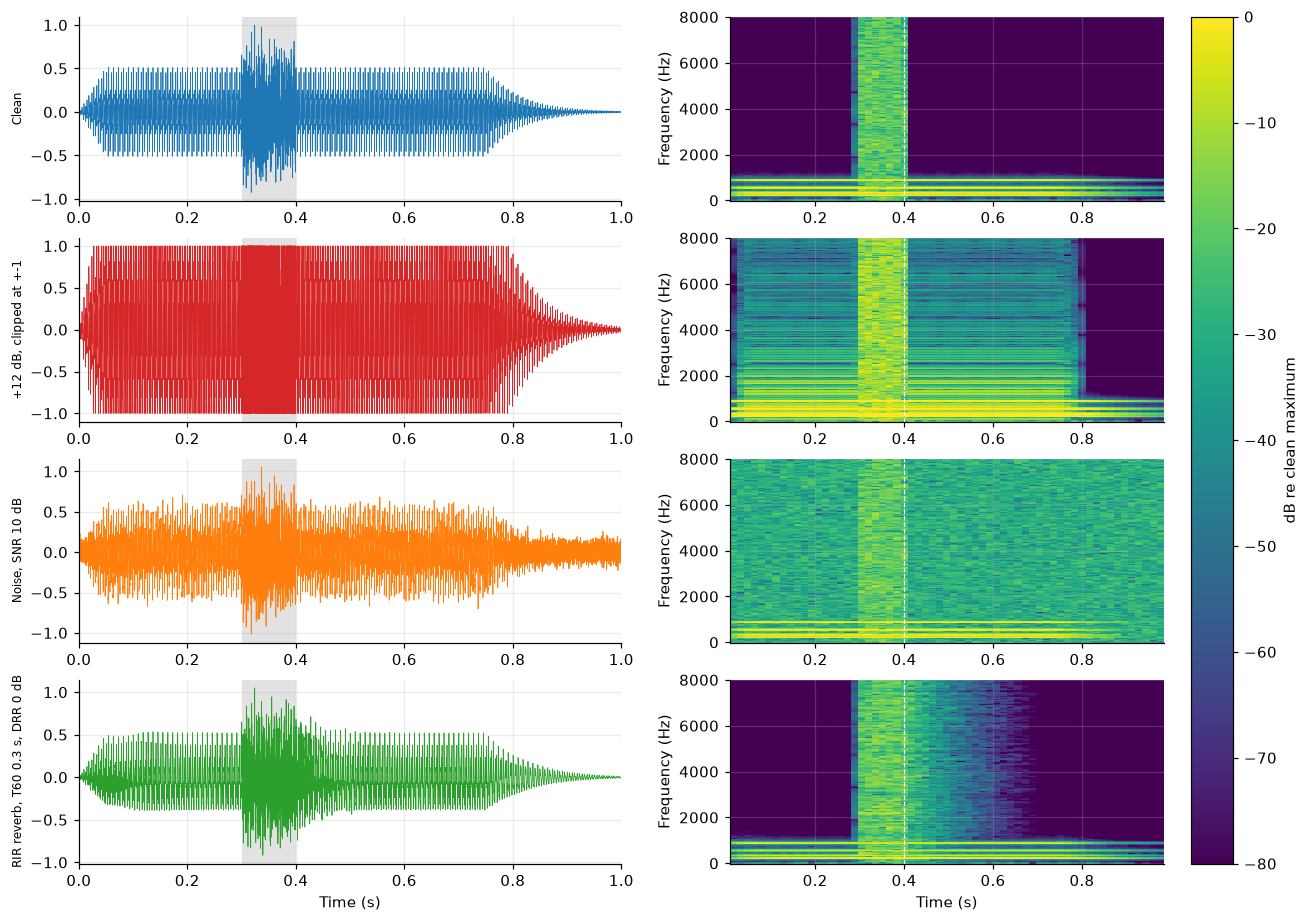

In [61]:
# S8.7 figure 1: waveforms + spectrograms for clean / +12 dB clipped / SNR 10 dB / RIR reverb (T60=0.3 s, DRR 0 dB); single seeds
from scipy.signal import spectrogram as sp_spec

n_noisy10, _ = audio.add_white_noise(n_waveform, sample_rate=n_sr, snr_db=10.0, seed=RNG_SEED + 8100)
n_rev03, n_rev_rec = audio.apply_rir_reverb(n_waveform, sample_rate=n_sr, rt60_seconds=0.3, drr_db=0.0, seed=RNG_SEED + 8200)
n_panels = [("Clean", n_waveform, PALETTE["clean"]), ("+12 dB, clipped at +-1", n_gain[12.0]["clip"], PALETTE["shifted"]),
            ("Noise, SNR 10 dB", n_noisy10, PALETTE["mask"]), ("RIR reverb, T60 0.3 s, DRR 0 dB", n_rev03, PALETTE["acoustic"])]
n_ref_db = 10 * np.log10(sp_spec(n_waveform, fs=n_sr, window="hann", nperseg=512, noverlap=256)[2].max() + 1e-12)

n_fig, n_ax = plt.subplots(len(n_panels), 2, figsize=(14, 10))
for n_i, (n_lab, n_w, n_col) in enumerate(n_panels):
    n_ax[n_i, 0].plot(n_time, n_w, color=n_col, linewidth=0.5)
    n_ax[n_i, 0].axvspan(n_burst_start / n_sr, n_burst_end / n_sr, color=PALETTE["band"], alpha=0.5, lw=0)
    n_ax[n_i, 0].set_ylabel(n_lab, fontsize=8); n_ax[n_i, 0].set_xlim(0, n_duration)
    n_f_, n_t_, n_sxx = sp_spec(n_w, fs=n_sr, window="hann", nperseg=512, noverlap=256)
    n_im = n_ax[n_i, 1].pcolormesh(n_t_, n_f_, 10 * np.log10(n_sxx + 1e-12) - n_ref_db, cmap="viridis", shading="auto", vmin=-80, vmax=0)
    n_ax[n_i, 1].set_ylabel("Frequency (Hz)"); n_ax[n_i, 1].axvline(n_burst_end / n_sr, color="white", ls="--", lw=0.8)
n_ax[-1, 0].set_xlabel("Time (s)"); n_ax[-1, 1].set_xlabel("Time (s)")
n_fig.colorbar(n_im, ax=n_ax[:, 1], label="dB re clean maximum")
plt.show()

### How to read this chart

Left column: waveform amplitude against time. The grey band marks the source burst, $0.30$ to $0.40$ s. Right column: spectrogram, frequency against time, with colour equal to power in dB relative to the loudest cell of the clean panel; the dashed white line marks the end of the burst. Rows are the four conditions in the order clean, $+12$ dB with the emulated limiter, additive noise at a requested $10$ dB SNR, and RIR reverb.

What to look for. In the limiter row the waveform's extremes are cut at $\pm1$ instead of continuing to the larger scaled values, and the spectrogram shows energy at frequencies above the source's harmonics outside the burst (the cut waveform is no longer a sum of those few sinusoids). In the noise row the spectrogram floor is raised across all frequencies and times, including the silent tail of the utterance. In the reverb row, compare the time extent of the broadband content around the burst with the clean row: a room adds energy to the right of the dashed line, where the clean panel has none above the harmonics. The reverb row is level matched, so its amplitudes are not a gain change.

The next cell replaces that visual impression with a number: energy above $2$ kHz after the burst has ended. The takeaway is that each operator leaves a distinct, measurable signature, and that none of these panels is evidence about real speech.

In [62]:
# S8.8 reverb tail signature: energy above 2 kHz in the window 0.42-0.52 s (after the burst ends at 0.40 s); 5 seeds per T60, DRR 0 dB
def n_hf_tail(x):
    n_seg = x[int(0.42 * n_sr):int(0.52 * n_sr)].astype(np.float64) * np.hanning(int(0.52 * n_sr) - int(0.42 * n_sr))
    n_p = np.abs(np.fft.rfft(n_seg)) ** 2
    return float(n_p[np.fft.rfftfreq(len(n_seg), 1 / n_sr) > 2000.0].sum())

n_hf_burst = float(np.sum(np.abs(np.fft.rfft(n_waveform[n_burst_start:n_burst_end].astype(np.float64) * np.hanning(n_burst_len))) ** 2
                          * (np.fft.rfftfreq(n_burst_len, 1 / n_sr) > 2000.0)))
n_hf_clean = n_hf_tail(n_waveform)
n_hf = {}
for n_rt in (0.1, 0.3, 0.6):
    n_hf[n_rt] = float(np.mean([n_hf_tail(audio.apply_rir_reverb(n_waveform, sample_rate=n_sr, rt60_seconds=n_rt, drr_db=0.0, seed=RNG_SEED + 8300 + n_s)[0]) for n_s in range(5)]))
print(f"HF energy (>2 kHz) in burst window {n_hf_burst:.3e}; clean tail window {n_hf_clean:.3e}")
print("reverb tail window: " + ", ".join(f"T60 {r:.1f} s -> {v:.3e}" for r, v in n_hf.items()))
check("S8.15", n_hf_clean < 1e-6 * n_hf_burst, f"the clean tail window has no HF content: {n_hf_clean:.2e} < 1e-6 x burst-window energy {n_hf_burst:.2e}")
check("S8.16", n_hf_clean < n_hf[0.1] < n_hf[0.3] < n_hf[0.6], "HF energy after the burst is zero for clean and increases with T60 (0.1 < 0.3 < 0.6 s), as predicted from the exponential tail")

HF energy (>2 kHz) in burst window 1.490e+04; clean tail window 1.791e-05
reverb tail window: T60 0.1 s -> 2.648e+00, T60 0.3 s -> 3.428e+02, T60 0.6 s -> 1.571e+03
[S8.15] the clean tail window has no HF content: 1.79e-05 < 1e-6 x burst-window energy 1.49e+04 -> PASS
[S8.16] HF energy after the burst is zero for clean and increases with T60 (0.1 < 0.3 < 0.6 s), as predicted from the exponential tail -> PASS


True

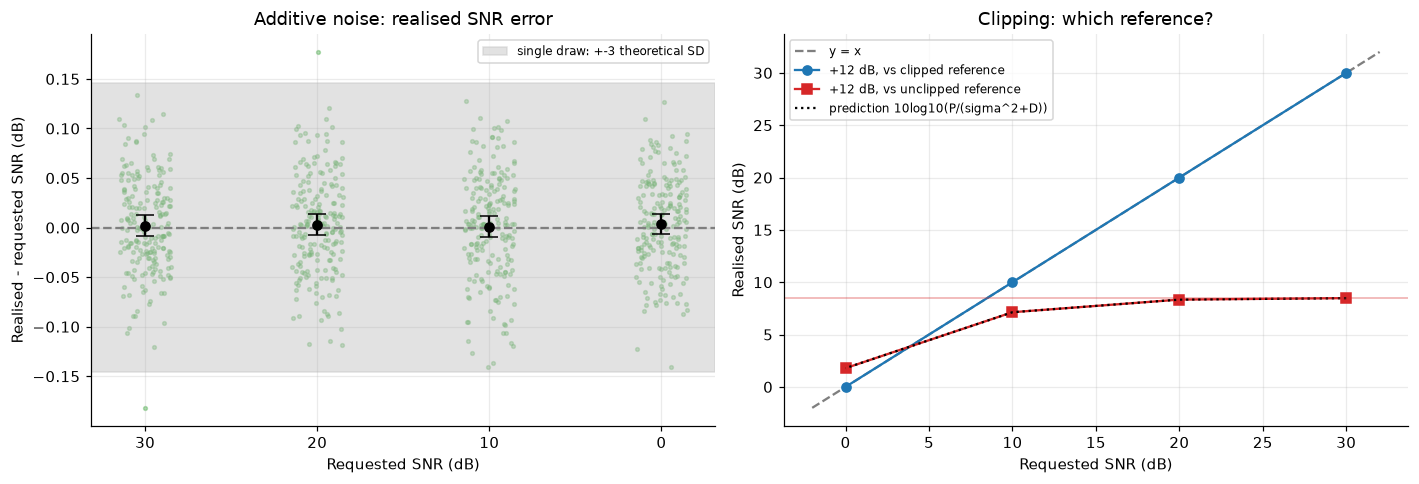

In [63]:
# Figure 2 (S8.9): SNR accuracy (left: residual realised-requested, R=200 draws per target) and clipping (right: SNR scored against clipped vs unclipped reference)
n_fig2, (n_a, n_b) = plt.subplots(1, 2, figsize=(13, 4.5))
for n_i, n_t in enumerate(n_snr_targets):
    n_v = n_snr_real[n_t] - n_t
    n_a.scatter(np.full(len(n_v), n_i) + np.random.default_rng(RNG_SEED + 8).uniform(-0.15, 0.15, len(n_v)), n_v, s=6, color=PALETTE["acoustic"], alpha=0.35)
    n_a.errorbar(n_i, n_v.mean(), yerr=3 * n_se_db / np.sqrt(n_R_snr), color="black", capsize=6, marker="o")
n_a.axhspan(-3 * n_se_db, 3 * n_se_db, color=PALETTE["band"], alpha=0.5, label="single draw: +-3 theoretical SD")
n_a.axhline(0, color=PALETTE["reference"], ls="--")
n_a.set_xticks(range(4)); n_a.set_xticklabels([f"{t:.0f}" for t in n_snr_targets])
n_a.set_xlabel("Requested SNR (dB)"); n_a.set_ylabel("Realised - requested SNR (dB)"); n_a.set_title("Additive noise: realised SNR error"); n_a.legend(fontsize=8)

n_tt = np.array(n_snr_targets)
n_b.plot([-2, 32], [-2, 32], color=PALETTE["reference"], ls="--", label="y = x")
n_b.plot(n_tt, [n_clip_res[(12.0, t)]["vs_c"].mean() for t in n_snr_targets], "o-", color=PALETTE["clean"], label="+12 dB, vs clipped reference")
n_b.plot(n_tt, [n_clip_res[(12.0, t)]["vs_u"].mean() for t in n_snr_targets], "s-", color=PALETTE["shifted"], label="+12 dB, vs unclipped reference")
n_b.plot(n_tt, [n_clip_res[(12.0, t)]["pred"] for t in n_snr_targets], "k:", label="prediction 10log10(P/(sigma^2+D))")
n_b.axhline(n_sdr12, color=PALETTE["shifted"], alpha=0.4, lw=1)
n_b.set_xlabel("Requested SNR (dB)"); n_b.set_ylabel("Realised SNR (dB)"); n_b.set_title("Clipping: which reference?"); n_b.legend(fontsize=8)
plt.tight_layout(); plt.show()

### How to read this chart

Left panel. Each small green point is one noise draw; the horizontal axis is the requested SNR, the vertical axis is realised minus requested SNR in dB, so $0$ is perfect agreement (dashed line). The grey band is $\pm3$ theoretical single-draw standard deviations from the delta-method formula, and the black marker with a bar is the mean over the $200$ draws with its $\pm3$ standard-error bar. Points scattered inside the band with the marker on the dashed line mean the operator delivers the requested SNR up to sampling noise; a marker off the line by more than its bar would be a bias.

Right panel. The dashed diagonal is the ideal. The blue curve scores SNR against the clipped signal that was handed to the operator: it should hug the diagonal. The red curve scores against the unclipped scaled signal: it should fall below the diagonal at high requested SNR and flatten toward the horizontal red line, the signal-to-distortion ratio of the limiter. The black dotted curve is the closed-form prediction; agreement between it and the red curve is the test.

Takeaway: additive-noise severity is reliable, but if clipping precedes it the *effective* SNR against the intended signal has a ceiling set by the clipping, so the reported severity must name its reference.

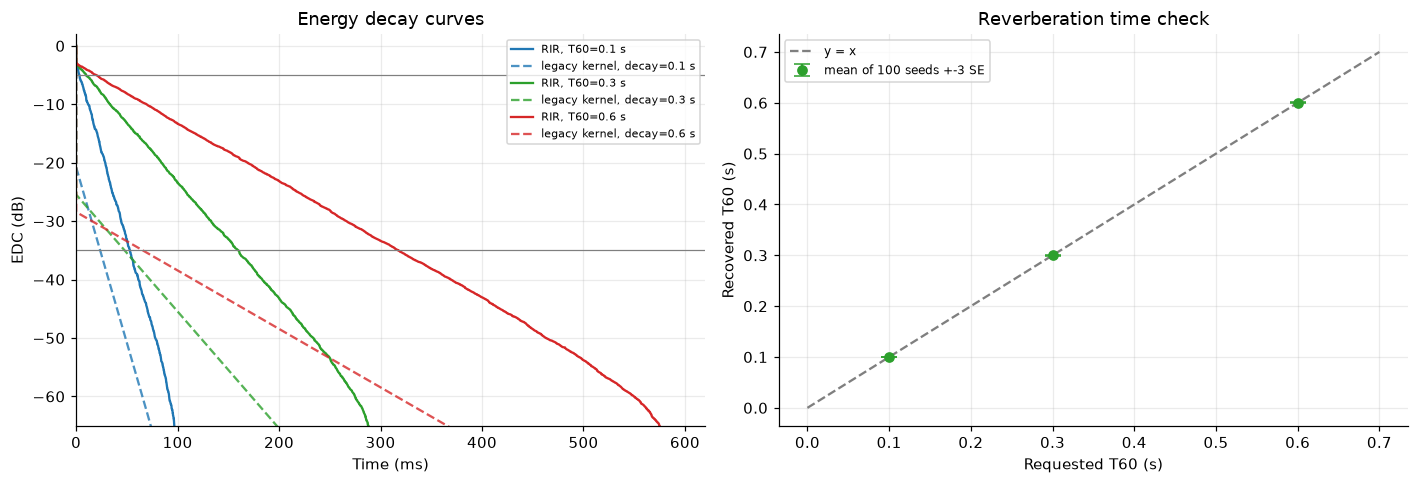

In [64]:
# Figure 3 (S8.10): energy decay curves of the applied RIR vs the legacy kernel (left), recovered RT60 vs requested with 3-SE bars (right); DRR 0 dB, R=100 seeds
n_fig3, (n_l, n_r) = plt.subplots(1, 2, figsize=(13, 4.5))
n_cols = [PALETTE["clean"], PALETTE["acoustic"], PALETTE["shifted"]]
for n_c, n_rt in zip(n_cols, (0.1, 0.3, 0.6)):
    n_h = n_rir[(n_rt, 0.0)]["first_h"]
    n_l.plot(np.arange(len(n_h)) / n_sr * 1000, n_edc_db(n_h), color=n_c, label=f"RIR, T60={n_rt:.1f} s")
    n_ho = n_legacy[n_rt]["h"]
    n_l.plot(np.arange(len(n_ho)) / n_sr * 1000, n_edc_db(n_ho), color=n_c, ls="--", alpha=0.8, label=f"legacy kernel, decay={n_rt:.1f} s")
n_l.axhline(-5, color=PALETTE["reference"], lw=0.8); n_l.axhline(-35, color=PALETTE["reference"], lw=0.8)
n_l.set_ylim(-65, 2); n_l.set_xlim(0, 620)
n_l.set_xlabel("Time (ms)"); n_l.set_ylabel("EDC (dB)"); n_l.set_title("Energy decay curves"); n_l.legend(fontsize=7)

n_req = np.array([0.1, 0.3, 0.6])
n_mean = np.array([n_rir[(r, 0.0)]["rt60"].mean() for r in n_req])
n_se3 = np.array([3 * n_rir[(r, 0.0)]["rt60"].std(ddof=1) / np.sqrt(100) for r in n_req])
n_r.plot([0, 0.7], [0, 0.7], color=PALETTE["reference"], ls="--", label="y = x")
n_r.errorbar(n_req, n_mean, yerr=n_se3, fmt="o", color=PALETTE["acoustic"], capsize=5, label="mean of 100 seeds +-3 SE")
n_r.set_xlabel("Requested T60 (s)"); n_r.set_ylabel("Recovered T60 (s)"); n_r.set_title("Reverberation time check"); n_r.legend(fontsize=8)
plt.tight_layout(); plt.show()

### How to read this chart

Left panel. The vertical axis is the Schroeder energy decay curve in dB (energy remaining after time $t$, relative to total), the horizontal axis is time in milliseconds. Solid curves are the applied RIR for three requested $T_{60}$ values; dashed curves of the same colour are the legacy kernel with the same requested decay. The two thin horizontal lines mark the $-5$ and $-35$ dB limits of the fitting range. A room-like response falls roughly along a straight line that reaches $-60$ dB at the requested $T_{60}$; the steeper the line, the shorter the reverberation.

Compare the two families. The solid curves start at the top and fall along a line whose slope depends on the requested $T_{60}$. The dashed curves behave differently: nearly all of their energy sits in the first tap (the cell above prints the share), so each curve makes a large step down at the very start, then decays from that lower level and therefore reaches $-60$ dB before the requested $T_{60}$ instead of at it.

Right panel. Requested $T_{60}$ on the horizontal axis, recovered $T_{60}$ on the vertical axis, with the diagonal as the ideal. The green markers are means over $100$ seeds with $\pm3$ standard-error bars. A marker whose bar overlaps the diagonal agrees with the request within sampling noise.

Takeaway: the RIR operator's stated $T_{60}$ and DRR are properties we can measure, which the legacy kernel could not offer.

In [65]:
# S8.11 sanity: every operator output is finite float32 with the input length; recap of measured worst cases from this section (no new random draws)
n_outs = {"gain+12 clipped": n_gain[12.0]["clip"], "noise 10 dB": n_noisy10, "rir 0.3 s": n_rev03,
          "legacy 0.3 s": audio.apply_reverb(n_waveform, sample_rate=n_sr, decay_seconds=0.3)[0]}
for n_nm, n_o in n_outs.items():
    print(f"{n_nm:16s}: dtype {n_o.dtype}, length {n_o.shape[0]}, finite {bool(np.isfinite(n_o).all())}, RMS {np.sqrt(np.mean(n_o.astype(np.float64) ** 2)):.4f}")
check("S8.17", all(o.dtype == np.float32 and o.shape == (n_samples,) and np.isfinite(o).all() for o in n_outs.values()),
      "all operator outputs are finite float32 arrays of the input length")
check("S8.18", n_rev_rec["kind"] == "rir_reverb" and abs(n_rev_rec["measured_drr_db"] - 0.0) < 1e-5 and abs(n_rev_rec["rt60_seconds"] - 0.3) < 1e-12,
      f"record of the figure's reverb condition: kind={n_rev_rec['kind']}, measured DRR {n_rev_rec['measured_drr_db']:.2e} dB, measured RT60 {n_rev_rec['measured_rt60_seconds']:.4f} s")

gain+12 clipped : dtype float32, length 16000, finite True, RMS 0.6174
noise 10 dB     : dtype float32, length 16000, finite True, RMS 0.2262
rir 0.3 s       : dtype float32, length 16000, finite True, RMS 0.2150
legacy 0.3 s    : dtype float32, length 16000, finite True, RMS 0.1077
[S8.17] all operator outputs are finite float32 arrays of the input length -> PASS
[S8.18] record of the figure's reverb condition: kind=rir_reverb, measured DRR 0.00e+00 dB, measured RT60 0.2958 s -> PASS


True

## 9. Noise-injected mixup, a NoisyMix-style analogue without the JSD stability term (source: Erichson et al., AISTATS 2024; q6, q7, q8)

### What NoisyMix is, according to the traces

The paper claims below are restricted to the raw traces q6, q7 and q8.

> q6: the NoisyMix objective combines three ingredients: stochastically augmented images (AugAndMix), noisy feature mixup (NFM), and Jensen-Shannon-divergence (JSD) stability training. The total loss is $\mathcal L_{\text{NoisyMix}}=\mathcal L_{\text{NFM}}+\gamma\,\mathcal L_{\text{stability}}$ (Section 3.1, Eq. 2).

> q6, NFM: $M_{\lambda,\xi}(x,x')=(1+\sigma_1\xi_{\text{mult}})\odot M_\lambda(x,x')+\sigma_2\xi_{\text{add}}$ with $M_\lambda(a,b)=\lambda a+(1-\lambda)b$, $\lambda\sim\mathrm{Beta}(\alpha,\beta)$, and $\xi=(\xi_{\text{add}},\xi_{\text{mult}})$ zero-mean noise with finite first two moments; the labels are mixed the same way, $M_\lambda(y,y')$.

> q6, stability term: the JSD between the predictions on the noisy-mixed clean pair and on the noisy-mixed augmented pair, $\mathcal L_{\text{stability}}=\mathbb E\big[\mathrm{JS}_\pi\big(p(M_{\lambda,\xi}(x,x')),\,p(M_{\lambda,\xi}(x_{\text{am}},x'_{\text{am}}))\big)\big]$.

q6 also reports Theorem 1 (App. B.1): in a small-noise regime, minimising the NFM loss is second-order equivalent to minimising the standard loss plus data-dependent regularisers that penalise the derivatives $\nabla p(x)$ and $\nabla^2p(x)$ scaled by the noise variances, which the paper reads as larger margins and smoother decision boundaries. Theorem 2 (App. B.2) gives the analogous statement for the JSD term. The evaluation in the trace is exclusively on 2D image benchmarks (ImageNet-family and CIFAR-family); q6 and q7 give as an explicit limitation that the method is not directly applicable to time-series tasks.

**Vision-only components (q7).** The AugAndMix operations $C_i$ (rotation, translation, shearing, posterisation, solarisation, autocontrast, equalisation) are pixel-based. q7 states that applying such 2D operations to a log-mel spectrogram destroys harmonic structure, pitch contours and temporal frame order, and that spectrogram axes are heterogeneous (logarithmic frequency against linear time), unlike the isotropic axes of an image. These are q7's statements about audio; we do not test them here.

**Status of the transfer to audio (q8).** q8 places the NFM loss and the JSD stability objective in its "Transferable Hypotheses" list, described as domain-agnostic loss formulations validated on other domains. That is a *hypothesis* in q8's own wording, not a finding.

### What this section actually does

We implement the NFM ingredient on a toy feature-space problem: $\lambda\sim\mathrm{Beta}(1,1)$, multiplicative and additive Gaussian noise, and mixed soft labels. There is **no JSD term and no AugAndMix**, so the regime is called *noise-injected mixup, a NoisyMix-style analogue without the JSD stability term*. It is not NoisyMix and its behaviour says nothing about NoisyMix's reported gains.

The toy is a two-class Gaussian problem with only six informative dimensions out of twenty and a training set of sixty points, chosen so that even the Bayes-optimal rule is well below perfect accuracy and a finite-sample learner is visibly worse than Bayes. At test time we apply an additive-noise shift of standard deviation $s$ to every feature. Because the classes are isotropic Gaussians with means $\pm\mu$ and unit covariance, additive noise inflates the variance to $1+s^2$ and the Bayes rule stays $\mathrm{sign}(\mu^\top x)$, with accuracy $\Phi\big(\lVert\mu\rVert/\sqrt{1+s^2}\big)$. That closed form gives us a ceiling to test against.

**Regimes compared (all use logistic regression with a matched effective penalty per unit of average loss):** clean ERM; clean ERM with a stronger $\ell_2$ penalty (a control, single value $C=0.1$, not tuned); noise-only augmentation (multiplicative and additive noise on resampled training points, no mixing); mixup only ($\sigma=0$); and noise-injected mixup ($\sigma_1=\sigma_2=0.5$, a single pilot value, not tuned). The control matters because q6's Theorem 1 describes NFM as an implicit regulariser, so any gain must be compared with what plain explicit regularisation buys.

**Hypotheses.** A single pilot run informed the choice of $\sigma$, $C$ and the toy dimensions, and the hypotheses below were written after that pilot, so treat them as exploratory rather than pre-registered. (H1) Noise-injected mixup gives better calibrated probabilities than clean ERM under the noise shift, measured by NLL and ECE. (H2) The noise component is what matters for that gain, so it should beat mixup-only. Whether it also beats plain $\ell_2$ regularisation, and whether accuracy improves, are reported as observations, with verdict strings computed from the confidence intervals.

In [66]:
# S9.1 toy DGP + regime builders: d=20 (6 informative dims, mean +-0.45), n_train=60, n_test=4000, R=100 reps, noise-shift sd s in {0,.5,1,1.5,2}, seed RNG_SEED+9
from sklearn.linear_model import LogisticRegression
from scipy.stats import norm
from src.metrics import nll, expected_calibration_error, bootstrap_interval

n_d, n_k, n_mu_dim = 20, 6, 0.45
n_mu = np.zeros(n_d); n_mu[:n_k] = n_mu_dim
n_ntrain, n_ntest, n_R9 = 60, 4000, 100
n_svals = [0.0, 0.5, 1.0, 1.5, 2.0]
n_sig_aug = 0.5                                     # sigma_1 = sigma_2, one pilot value, not tuned
n_bayes_analytic = {s: float(norm.cdf(np.linalg.norm(n_mu) / np.sqrt(1 + s ** 2))) for s in n_svals}

def n_draw(rng, n):
    y = rng.integers(0, 2, n)
    return rng.standard_normal((n, n_d)) + np.where(y[:, None] == 1, n_mu, -n_mu), y

def n_fit(X, y, w=None, c=1.0):
    total = len(y) if w is None else float(w.sum())          # keeps the penalty per unit of average loss fixed across regimes
    return LogisticRegression(C=c * n_ntrain / total, max_iter=1000).fit(X, y, sample_weight=w)

def n_nfm(rng, X, y, mixing, noise, m=4):
    # M_{lambda,xi}(x,x') = (1+sigma1*xi_mult) * (lam*x+(1-lam)*x') + sigma2*xi_add ; labels mixed with the same lambda (soft labels -> weighted rows)
    n = len(y); M = m * n
    i, j = rng.integers(0, n, M), rng.integers(0, n, M)
    lam = rng.beta(1.0, 1.0, M)[:, None] if mixing else np.ones((M, 1))
    Xm = lam * X[i] + (1 - lam) * X[j]
    if noise:
        Xm = (1 + n_sig_aug * rng.standard_normal(Xm.shape)) * Xm + n_sig_aug * rng.standard_normal(Xm.shape)
    t = lam[:, 0] * y[i] + (1 - lam[:, 0]) * y[j]
    return np.vstack([Xm, Xm]), np.r_[np.ones(M), np.zeros(M)].astype(int), np.r_[t, 1 - t]

n_regimes = ["ERM (clean)", "ERM + stronger L2 (control)", "noise-only augmentation", "mixup only", "noise-injected mixup (NFM-style)"]
print(f"informative-subspace norm |mu|={np.linalg.norm(n_mu):.3f}; analytic Bayes accuracy by shift s: " + ", ".join(f"s={s}: {v:.4f}" for s, v in n_bayes_analytic.items()))

informative-subspace norm |mu|=1.102; analytic Bayes accuracy by shift s: s=0.0: 0.8648, s=0.5: 0.8379, s=1.0: 0.7821, s=1.5: 0.7295, s=2.0: 0.6890


In [67]:
# S9.2 Monte Carlo: R=100 paired reps (same train/test draw for all regimes), seeds RNG_SEED+9000+rep; metrics accuracy / NLL / top-label ECE (10 bins)
n_M = {k: np.zeros((len(n_regimes), len(n_svals), n_R9)) for k in ("acc", "nll", "ece")}
n_bayes_emp = np.zeros((len(n_svals), n_R9))
for n_rep in range(n_R9):
    n_rng9 = np.random.default_rng(RNG_SEED + 9000 + n_rep)
    n_Xtr, n_ytr = n_draw(n_rng9, n_ntrain)
    n_Xte, n_yte = n_draw(n_rng9, n_ntest)
    n_eps = n_rng9.standard_normal(n_Xte.shape)
    n_models = [n_fit(n_Xtr, n_ytr), n_fit(n_Xtr, n_ytr, c=0.1)]
    n_models.append(n_fit(*n_nfm(n_rng9, n_Xtr, n_ytr, mixing=False, noise=True)))
    n_models.append(n_fit(*n_nfm(n_rng9, n_Xtr, n_ytr, mixing=True, noise=False)))
    n_models.append(n_fit(*n_nfm(n_rng9, n_Xtr, n_ytr, mixing=True, noise=True)))
    for n_si, n_s in enumerate(n_svals):
        n_Xs = n_Xte + n_s * n_eps
        n_bayes_emp[n_si, n_rep] = np.mean((n_Xs @ n_mu > 0).astype(int) == n_yte)
        for n_ri, n_mod in enumerate(n_models):
            n_p = n_mod.predict_proba(n_Xs)
            n_M["acc"][n_ri, n_si, n_rep] = np.mean(n_p.argmax(1) == n_yte)
            n_M["nll"][n_ri, n_si, n_rep] = nll(n_p, n_yte)
            n_M["ece"][n_ri, n_si, n_rep] = expected_calibration_error(n_p, n_yte)
print(f"finished {n_R9} paired repetitions x {len(n_regimes)} regimes x {len(n_svals)} shift levels")

finished 100 paired repetitions x 5 regimes x 5 shift levels


In [68]:
# S9.3 results at shift s=1.0 (index 2): bootstrap 95% CIs over the 100 Monte Carlo repetitions; paired differences vs ERM; checks
n_si1 = n_svals.index(1.0)
def n_ci(a):
    b = bootstrap_interval(np.asarray(a), seed=RNG_SEED + 9)
    return b.point, b.lower, b.upper
def n_verdict(a, lower_is_better=True):
    p, lo, hi = n_ci(a)
    if hi < 0: return "lower" if lower_is_better else "worse"
    if lo > 0: return "higher" if lower_is_better else "better"
    return "not distinguishable from zero"

print(f"{'regime':36s} {'accuracy [95% CI]':26s} {'NLL [95% CI]':26s} {'ECE [95% CI]':26s}")
for n_ri, n_nm in enumerate(n_regimes):
    print(f"{n_nm:36s} " + " ".join(f"{n_ci(n_M[k][n_ri, n_si1])[0]:.3f} [{n_ci(n_M[k][n_ri, n_si1])[1]:.3f},{n_ci(n_M[k][n_ri, n_si1])[2]:.3f}]".ljust(26) for k in ("acc", "nll", "ece")))
print(f"Bayes accuracy at s=1: analytic {n_bayes_analytic[1.0]:.4f}, empirical mean {n_bayes_emp[n_si1].mean():.4f}")

n_erm, n_l2, n_noise, n_mix, n_nfm_i = 0, 1, 2, 3, 4
n_d_nll = n_M["nll"][n_nfm_i, n_si1] - n_M["nll"][n_erm, n_si1]
n_d_ece = n_M["ece"][n_nfm_i, n_si1] - n_M["ece"][n_erm, n_si1]
n_d_mix = n_M["nll"][n_nfm_i, n_si1] - n_M["nll"][n_mix, n_si1]
n_d_gap = n_M["acc"][n_erm, n_si1] - n_bayes_emp[n_si1]
n_bay_se = n_bayes_emp[:, :].std(axis=1, ddof=1) / np.sqrt(n_R9)
check("S9.1", all(abs(n_bayes_emp[i].mean() - n_bayes_analytic[s]) <= 3 * n_bay_se[i] for i, s in enumerate(n_svals)),
      "empirical Bayes accuracy matches Phi(|mu|/sqrt(1+s^2)) within 3 SE at every shift level (DGP and shift implemented as derived)")
check("S9.2", n_ci(n_d_gap)[2] < 0 and n_ci(n_M["acc"][n_erm, n_si1])[2] < 1.0,
      f"DGP is not saturated: ERM accuracy {n_M['acc'][n_erm, n_si1].mean():.3f} is below Bayes (paired gap CI upper {n_ci(n_d_gap)[2]:.4f} < 0)")
check("S9.3", n_ci(n_d_nll)[2] < 0, f"H1: noise-injected mixup NLL minus ERM NLL at s=1: {n_ci(n_d_nll)[0]:+.3f} CI [{n_ci(n_d_nll)[1]:+.3f},{n_ci(n_d_nll)[2]:+.3f}] (need upper < 0)")
check("S9.4", n_ci(n_d_ece)[2] < 0, f"H1: noise-injected mixup ECE minus ERM ECE at s=1: {n_ci(n_d_ece)[0]:+.3f} CI [{n_ci(n_d_ece)[1]:+.3f},{n_ci(n_d_ece)[2]:+.3f}] (need upper < 0)")
check("S9.5", n_ci(n_d_mix)[2] < 0, f"H2: noise-injected mixup NLL minus mixup-only NLL at s=1: {n_ci(n_d_mix)[0]:+.3f} CI [{n_ci(n_d_mix)[1]:+.3f},{n_ci(n_d_mix)[2]:+.3f}] (need upper < 0)")

regime                               accuracy [95% CI]          NLL [95% CI]               ECE [95% CI]              


ERM (clean)                          0.726 [0.723,0.730]        0.789 [0.776,0.803]        0.161 [0.158,0.164]       


ERM + stronger L2 (control)          0.744 [0.741,0.747]        0.519 [0.514,0.523]        0.027 [0.024,0.029]       


noise-only augmentation              0.729 [0.725,0.732]        0.649 [0.639,0.659]        0.123 [0.119,0.126]       


mixup only                           0.722 [0.718,0.726]        0.649 [0.638,0.659]        0.121 [0.117,0.124]       


noise-injected mixup (NFM-style)     0.728 [0.724,0.731]        0.563 [0.556,0.570]        0.066 [0.062,0.070]       
Bayes accuracy at s=1: analytic 0.7821, empirical mean 0.7823
[S9.1] empirical Bayes accuracy matches Phi(|mu|/sqrt(1+s^2)) within 3 SE at every shift level (DGP and shift implemented as derived) -> PASS
[S9.2] DGP is not saturated: ERM accuracy 0.726 is below Bayes (paired gap CI upper -0.0526 < 0) -> PASS


[S9.3] H1: noise-injected mixup NLL minus ERM NLL at s=1: -0.226 CI [-0.238,-0.216] (need upper < 0) -> PASS


[S9.4] H1: noise-injected mixup ECE minus ERM ECE at s=1: -0.095 CI [-0.099,-0.091] (need upper < 0) -> PASS
[S9.5] H2: noise-injected mixup NLL minus mixup-only NLL at s=1: -0.086 CI [-0.095,-0.076] (need upper < 0) -> PASS


True

In [69]:
# S9.4 observations that are reported, not asserted: accuracy, the plain-L2 control, and the clean-shift (s=0) cost; verdict strings come from the CIs
n_d_acc = n_M["acc"][n_nfm_i, n_si1] - n_M["acc"][n_erm, n_si1]
n_d_acc_noise = n_M["acc"][n_noise, n_si1] - n_M["acc"][n_erm, n_si1]
n_d_nll_l2 = n_M["nll"][n_nfm_i, n_si1] - n_M["nll"][n_l2, n_si1]
n_d_acc_l2 = n_M["acc"][n_nfm_i, n_si1] - n_M["acc"][n_l2, n_si1]
n_d_clean_nll = n_M["nll"][n_nfm_i, 0] - n_M["nll"][n_erm, 0]
n_d_clean_acc = n_M["acc"][n_nfm_i, 0] - n_M["acc"][n_erm, 0]
def n_fmt(a): return f"{n_ci(a)[0]:+.4f} CI [{n_ci(a)[1]:+.4f},{n_ci(a)[2]:+.4f}]"
note("S9.6", f"accuracy, noise-injected mixup minus ERM at s=1: {n_fmt(n_d_acc)} -> {n_verdict(n_d_acc, False)}")
note("S9.7", f"accuracy, noise-only augmentation minus ERM at s=1: {n_fmt(n_d_acc_noise)} -> {n_verdict(n_d_acc_noise, False)}")
note("S9.8", f"control: NLL of noise-injected mixup minus the stronger-L2 ERM at s=1: {n_fmt(n_d_nll_l2)} -> NFM-style NLL is {n_verdict(n_d_nll_l2)} than plain L2")
note("S9.9", f"control: accuracy of noise-injected mixup minus the stronger-L2 ERM at s=1: {n_fmt(n_d_acc_l2)} -> {n_verdict(n_d_acc_l2, False)}")
note("S9.10", f"no shift (s=0): NLL of noise-injected mixup minus ERM {n_fmt(n_d_clean_nll)}; accuracy {n_fmt(n_d_clean_acc)}")
n_best_acc = int(np.argmax([n_M["acc"][i, n_si1].mean() for i in range(len(n_regimes))]))
n_best_nll = int(np.argmin([n_M["nll"][i, n_si1].mean() for i in range(len(n_regimes))]))
print(f"best mean accuracy at s=1: {n_regimes[n_best_acc]}; best mean NLL at s=1: {n_regimes[n_best_nll]}")

[S9.6] accuracy, noise-injected mixup minus ERM at s=1: +0.0012 CI [-0.0018,+0.0043] -> not distinguishable from zero -> NOTE
[S9.7] accuracy, noise-only augmentation minus ERM at s=1: +0.0021 CI [-0.0009,+0.0050] -> not distinguishable from zero -> NOTE


[S9.8] control: NLL of noise-injected mixup minus the stronger-L2 ERM at s=1: +0.0445 CI [+0.0394,+0.0497] -> NFM-style NLL is higher than plain L2 -> NOTE
[S9.9] control: accuracy of noise-injected mixup minus the stronger-L2 ERM at s=1: -0.0163 CI [-0.0188,-0.0136] -> worse -> NOTE


[S9.10] no shift (s=0): NLL of noise-injected mixup minus ERM -0.0311 CI [-0.0391,-0.0235]; accuracy -0.0005 CI [-0.0042,+0.0033] -> NOTE
best mean accuracy at s=1: ERM + stronger L2 (control); best mean NLL at s=1: ERM + stronger L2 (control)


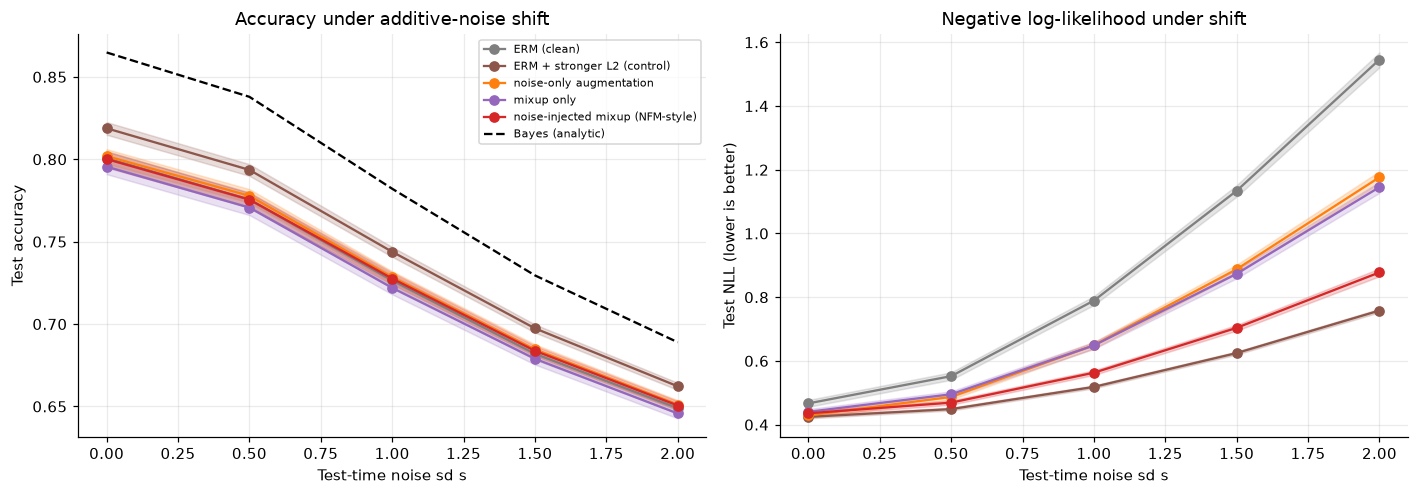

In [70]:
# Figure 4 (S9.5): accuracy and NLL versus test-noise sd s for all five regimes, bootstrap 95% CI bands over R=100 paired repetitions, plus analytic Bayes accuracy
n_fig4, (n_p, n_q) = plt.subplots(1, 2, figsize=(13, 4.6))
n_colors = [PALETTE["reference"], PALETTE["adapted"], PALETTE["mask"], PALETTE["frozen"], PALETTE["shifted"]]
for n_ri, (n_nm, n_c) in enumerate(zip(n_regimes, n_colors)):
    for n_ax_, n_key in ((n_p, "acc"), (n_q, "nll")):
        n_cis = np.array([n_ci(n_M[n_key][n_ri, n_si]) for n_si in range(len(n_svals))])
        n_ax_.plot(n_svals, n_cis[:, 0], marker="o", color=n_c, label=n_nm if n_key == "acc" else None)
        n_ax_.fill_between(n_svals, n_cis[:, 1], n_cis[:, 2], color=n_c, alpha=0.2)
n_p.plot(n_svals, [n_bayes_analytic[s] for s in n_svals], "k--", label="Bayes (analytic)")
n_p.set_xlabel("Test-time noise sd s"); n_p.set_ylabel("Test accuracy"); n_p.set_title("Accuracy under additive-noise shift")
n_q.set_xlabel("Test-time noise sd s"); n_q.set_ylabel("Test NLL (lower is better)"); n_q.set_title("Negative log-likelihood under shift")
n_p.legend(fontsize=7)
plt.tight_layout(); plt.show()

### How to read this chart

Left panel: test accuracy against the standard deviation $s$ of the additive test-time noise, one coloured line per training regime, shaded band a bootstrap $95\%$ confidence interval over $100$ paired Monte Carlo repetitions. The dashed black line is the analytic Bayes accuracy $\Phi(\lVert\mu\rVert/\sqrt{1+s^2})$; no learner can sit above it, and the vertical gap between a line and the dashed curve is the price of learning from sixty points. Right panel: negative log-likelihood against $s$ for the same regimes; lower is better and a steeper rise means confidence is degrading faster under the shift.

How to compare. Where two bands do not overlap, the ordering is supported at that shift level; where they overlap, this experiment cannot separate the regimes at that level. Because repetitions are paired, differences are more sharply resolved than the raw bands suggest, and the paired numbers are the ones printed in the cells above and used by the checks. Read the accuracy panel and the NLL panel separately: a regime can improve probability quality without improving the error rate.

What would make the conclusion wrong: a different informative-subspace size, a different training-set size, a tuned penalty for the control, or a different noise strength $\sigma$ could change the ordering. The experiment supports only the statements printed above; it does not show that the gains would carry over to speech features.

### Reading the toy honestly

The toy makes three separate kinds of statement, kept apart here.

**Paper claims (q6, q7, q8).** NFM is defined as in the q6 blockquote; Theorem 1 says it is second-order equivalent to standard loss plus derivative-penalising regularisers; the reported empirical results are on image benchmarks; the authors state the method is not directly applicable to time-series tasks.

**Toy observations (printed by the cells above).** They concern a linear model on Gaussian features. They include a **negative finding that we designed the toy to be able to show**: the plain stronger-$\ell_2$ control is a competitor that any claimed benefit of augmentation has to be measured against, and the printed notes state how it compares. Accuracy comparisons are reported with confidence intervals and verdict strings that are computed, not written.

**Hypotheses (not tested here).** (i) The transfer of NFM to speech features (q8 lists it as a transferable hypothesis). (ii) That audio-native perturbations such as reverberation or spectral masking matter more than generic feature noise for speech: this is an open question we do not answer, since neither the toy nor the operators above train a speech model. (iii) That the JSD stability term adds robustness in audio; we did not implement it, so the toy is silent on it.

## 10. Synthesis: measure, decide, monitor, and what the sources do not settle (derived here; q3, q8, q12)

### Recap table: steps, source, guarantee form, and status

Status column: **source** = stated in the cited raw trace; **derived** = derived and tested in this notebook; **hypothesis** = an inference of ours or a q8 "transferable hypothesis", not established.

| Step | Where | Guarantee or measurement | Status |
|---|---|---|---|
| Measure gain | `src.audio.apply_gain` (Section 8) | amplitude scale $a=10^{g/20}$, power scale $a^2$; float32 output is not clipped | derived |
| Measure noise | `src.audio.add_white_noise` (Section 8) | requested SNR $\rho$ gives $\sigma_n^2=P_s/10^{\rho/10}$; realised SNR has single-draw SD $\approx4.34\sqrt{2/N}$ dB | derived |
| Measure reverb | `src.audio.apply_rir_reverb` (Section 8) | synthetic exponential-decay RIR; DRR and $T_{60}$ requested and re-measured by impulse recovery | derived |
| Risk control, exchangeable data | Angelopoulos et al., 2208.02814, Theorem 1 (q3) | $\mathbb E[L_{n+1}(\hat\lambda)]\le\alpha$ for monotone bounded losses | source |
| Non-monotone loss | 2208.02814, Proposition 2 and Theorem C.1 (q3, q12) | Prop. 2: for any $\epsilon$ a non-monotone loss with $\mathbb E[L_{n+1}(\hat\lambda)]\ge B-\epsilon$; Theorem C.1: monotonised empirical loss gives asymptotic control | source |
| Covariate shift | 2208.02814, Proposition 3 (q3) | weighted threshold with $w(x)=dP_{\text{test}}/dP_{\text{train}}$ gives exact control | source; use for acoustic shift is a q8 hypothesis |
| General shift | 2208.02814, Proposition 4 (q3, q12) | $\mathbb E[L_{n+1}(\hat\lambda)]\le\alpha+B\sum_i\mathrm{TV}(Z_i,Z_{n+1})$ | source; whether it is informative for reverberation is a hypothesis |
| Noisy feature mixup | Erichson et al., Theorem 1 (q6) | second-order equivalence to standard loss plus derivative penalties | source (vision experiments) |
| Stability loss | Erichson et al., Theorem 2 (q6) | JSD term regularises first and second derivatives on clean and augmented data | source (vision experiments) |
| Noise-injected mixup toy | Section 9 | measured NLL/ECE/accuracy against ERM and a stronger-$\ell_2$ control on a Gaussian toy | derived; transfer to speech is a hypothesis |

### What the sources do not promise

This list keeps three categories separate: things the traces state, things they do not address, and our own inferences (marked as hypotheses).

**Conformal risk control (2208.02814), per q12 and q3.**
- Its Section 5 states two primary limitations: the requirement of a monotone loss is difficult to lift, and extensions to non-exchangeable data require knowledge about the form of the shift (q12, quoted below).
- Proposition 2 (q12, Section 2.3): for any $\epsilon$ there is a non-monotone loss for which $\mathbb E[L_{n+1}(\hat\lambda)]\ge B-\epsilon$. Per q3, Theorem C.1 gives asymptotic control for a monotonised empirical loss.
- Proposition 4 gives a total-variation bound for arbitrary shifts (q12, Section 4.1). *Hypothesis, not in q12:* that this bound is uninformative when acoustic shift is large. q12 lists trivial thresholds that force abstention on every command as a possible negative finding to look for, not as a result.

**NoisyMix (Erichson et al., 2024), per q6, q7, q12.**
- Its conclusion states a limitation: it is tailored towards computer vision tasks and not directly applicable to time-series tasks (q6, q7, q12).
- q12 quotes Appendix D.1 on architecture limits in learning high-frequency features in low-dimensional domains, which could imply the model tends toward features similar in frequency to the in-domain task. *Hypothesis of ours, not in q12:* that this bears on channel or bandwidth shift in speech.

**Not measured in this notebook:** real speech-command data (Speech Commands, 1804.03209), trained speech models, pretrained speech backbones, or any real reverberation recording. Everything above is a controlled synthetic experiment.

### Limitations and concrete experimental pursuits (q12)

q12 lists three limitations of the sources plus one capture problem. For the first three, the pursuit and the "negative finding" (a result that would count against the approach) are q12's own wording, summarised; the verbatim quotations are marked with quotation marks.

#### 1. Loss monotonicity constraint in risk control

- Quoted (q12, Section 5): *"two primary limitations of our technique remain: firstly, the requirement of a monotone loss is difficult to lift."*
- Pursuit (q12): evaluate a speech-command classifier with a joint abstention-and-error loss that penalises both misclassification and set size, over a range of thresholds.
- Falsifier (q12): applying the threshold estimator to the non-monotone loss gives empirical test risk above the target $\alpha$, or monotonising the empirical loss gives such conservative sets that the system abstains almost always.

#### 2. Knowledge of the shift form

- Quoted (q12, Section 5): *"secondly, extensions to non-exchangeable data require knowledge about the form of the shift. This issue affects most statistical methods, including standard conformal prediction, and ours is no different in this regard."*
- Pursuit (q12): calibrate on clean audio, deploy on reverberant audio, and estimate likelihood ratios with a domain classifier on unlabelled buffers for weighted risk control.
- Falsifier (q12): errors in the estimated density ratio cause the weighted procedure to under-cover, or the total-variation route yields trivial thresholds that abstain on every command.

#### 3. Vision-specific augmentation

- Quoted (q12, Section 5): *"A limitation of NoisyMix is that it is tailored towards computer vision tasks and not directly applicable to natural language processing tasks, or time series tasks."*
- Pursuit (q12): an "Acoustic-NoisyMix" that replaces the 2D visual transformations with acoustic operations (room impulse response, SpecAugment-style masking, additive noise), trained on speech commands and evaluated for calibration and abstention under acoustic shift.
- Falsifier (q12): no statistically significant improvement in out-of-domain accuracy or RMS calibration error over clean training, or degraded clean accuracy from feature noise.

#### 4. Capture gap and a further pursuit of ours

- q12 (item 4) notes that one of the notebook sources captured only a browser-verification page. The selective-classification statements in this notebook come from a separately obtained copy (the source tagged L in Sections 3 and 4), not from that capture.
- *Hypothesis and pursuit of ours, not in q12:* train a speech classifier on full-band audio and test on band-limited audio, to see whether the frequency-bias remark in Appendix D.1 shows up as a channel-mismatch failure. No expected effect size is claimed.

### What Notebook 2 will add

Notebook 2 moves from these controlled constructions to real data and trained models. The items below are plans, not results.

1. **Real Speech Commands data** (1804.03209). The dataset's exact size, vocabulary and split will be read from the downloaded files and reported by code, not asserted here.
2. **Convolutional models** on mel-spectrogram inputs. Whether NoisyMix-style regularisation helps them is a hypothesis to test, in the sense of q8's "transferable hypotheses".
3. **A pre-trained self-supervised speech backbone**, frozen or fine-tuned, to compare against hand-crafted features. The specific checkpoint will be fixed in Notebook 2.
4. **Latency and jitter** at batch size one under the acoustic shifts defined here, alongside calibration as the RIR reverberation time is varied.
5. **Held-out-word abstention**: some vocabulary words withheld from training and presented as unknown inputs, to measure the selective risk and coverage trade-off.
6. **Paired statistical comparisons**: exchangeable conformal risk control against a weighted variant using an estimated density ratio on real noise recordings, with bootstrap intervals from `src.metrics.bootstrap_interval`.

### References (inline, by arXiv id and q-tag)

- **2208.02814**, Angelopoulos, Bates, Fisch, Lei and Schuster, *Conformal Risk Control*, ICLR 2024 (authors and venue as in q1). Theorem 1, Propositions 2 to 4 and Theorem C.1 are named as in q3; the limitations quoted in Section 10 are from q12.
- **2405.05160**, Liang, Peng and Sun, *Selective Classification Under Distribution Shifts*, TMLR 2024. The statements attributed to it in this notebook rest on the separately re-verified copy tagged L in Sections 3 and 4. The toy in Section 9 does not test selective risk.
- **NoisyMix**, Erichson, Lim, Xu, Utrera, Cao and Mahoney, *NoisyMix: Boosting Model Robustness to Common Corruptions*, AISTATS 2024, PMLR v238 (title, authors and venue as in q1). Equations and Theorems 1 and 2 are as in q6; the limitations are as in q6, q7 and q12; the audio-transfer statements are q8's "transferable hypotheses" and "unsupported extrapolations".
- **1804.03209**, Warden, *Speech Commands: A Dataset for Limited-Vocabulary Speech Recognition*, 2018. Cited only as the planned dataset for Notebook 2; no dataset statistics are quoted here.

In [71]:
# S10 summary of what this part measured (all numbers printed from the variables computed above; no new random draws)
n_worst_snr_z = max(abs(n_snr_real[t].mean() - t) / (n_se_db / np.sqrt(n_R_snr)) for t in n_snr_targets)
n_worst_rt_z = max(abs(z) for z in n_z.values())
print("Section 8 (operators):")
print(f"  single-draw SNR SD (theory) {n_se_db:.4f} dB; worst |z| of mean SNR error {n_worst_snr_z:.2f}; worst |z| of mean RT60 {n_worst_rt_z:.2f}")
print(f"  worst recovered-DRR error {n_drr_err:.1e} dB; SDR ceiling at +12 dB clipping {n_sdr12:.2f} dB")
print("Section 9 (toy, s=1):")
for n_ri, n_nm in enumerate(n_regimes):
    print(f"  {n_nm:36s} acc {n_M['acc'][n_ri, n_si1].mean():.3f}  NLL {n_M['nll'][n_ri, n_si1].mean():.3f}  ECE {n_M['ece'][n_ri, n_si1].mean():.3f}")
print(f"  Bayes accuracy (analytic) {n_bayes_analytic[1.0]:.3f}")

Section 8 (operators):
  single-draw SNR SD (theory) 0.0486 dB; worst |z| of mean SNR error 1.06; worst |z| of mean RT60 1.76
  worst recovered-DRR error 3.2e-07 dB; SDR ceiling at +12 dB clipping 8.50 dB
Section 9 (toy, s=1):
  ERM (clean)                          acc 0.726  NLL 0.789  ECE 0.161
  ERM + stronger L2 (control)          acc 0.744  NLL 0.519  ECE 0.027
  noise-only augmentation              acc 0.729  NLL 0.649  ECE 0.123
  mixup only                           acc 0.722  NLL 0.649  ECE 0.121
  noise-injected mixup (NFM-style)     acc 0.728  NLL 0.563  ECE 0.066
  Bayes accuracy (analytic) 0.782


In [72]:
# Final check summary
check_summary()

178 labelled lines; 161 PASS, 17 NOTE, 0 FAIL []


In [73]:
check_summary()

178 labelled lines; 161 PASS, 17 NOTE, 0 FAIL []
